# ABP fixed-noise propulsion-speed sweep 

Main diagnostics:

1. case inventory and actual saved configuration;
2. MUCA convergence versus iteration;
3. final MUCA histograms and learned logweights across speeds;
4. production ESS and round trips;
5. biased vs reweighted endpoint distributions;
6. \(P[x(T)>0]\), \(P[x(T)>0.5]\), and finite-time endpoint-rate diagnostics;
7. conditioned whole-path \(y\) distributions and \(x\)-\(y\) occupation maps;
8. occupation-based slice LDF \(\Phi_v(y)\);
9. quartic Landau fit versus propulsion speed and an estimated \(v_c\);

## 1. Imports

In [1]:
from __future__ import annotations

import math
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 10,
})

## 2. User configuration

Normally you should not need to edit `RUN_ROOT`. If automatic discovery cannot
find the job directory, set it explicitly.

**Job 1669022 path note.** The Slurm wrapper printed a job-specific `task_*` output directory, but the inner Julia runner wrote the completed results under `data/fixed_D0p025_speed_landscape/v_<speed>/`. Auto-discovery therefore prioritizes roots containing actual exported CSV markers.

In [2]:

from pathlib import Path
import re
import math
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

OLD_JOB_ID = "1669022"

NEW_JOB_ID = "1700987"

JOB_IDS = [
    OLD_JOB_ID,
    NEW_JOB_ID,
]

FIXED_D = 0.025

PROJECT_ROOT = Path(
    "/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep"
)

DATA_DIR = (
    PROJECT_ROOT
    / "data"
)


# Expected combined velocity grid:
#
# new job: 0.290 ... 0.315
# old job: 0.320 ... 0.390
EXPECTED_SPEEDS = np.round(
    np.arange(
        0.290,
        0.390 + 1e-12,
        0.005,
    ),
    3,
)


# ------------------------------------------------------------
# ACTUAL STORAGE LOCATIONS
# ------------------------------------------------------------

# Job 1669022 accidentally used the fallback output hierarchy.
OLD_ROOT = (
    DATA_DIR
    / "fixed_D0p025_speed_landscape"
)

# New job uses ABP_OUTPUT_DIR correctly.
NEW_ROOT = (
    DATA_DIR
    / f"abp_speed_D0p025_array_{NEW_JOB_ID}"
)

RUN_ROOTS = [
    OLD_ROOT,
    NEW_ROOT,
]


# ============================================================
# HELPERS
# ============================================================

def read_case_summary(path):

    if not path.is_file():
        return {}

    try:
        df = pd.read_csv(
            path,
            dtype=str,
        )

        if df.shape[1] < 2:
            return {}

        return dict(
            zip(
                df.iloc[:, 0].astype(str),
                df.iloc[:, 1].astype(str),
            )
        )

    except Exception:
        return {}


def safe_float(mapping, key):

    try:
        return float(
            mapping[key]
        )

    except Exception:
        return np.nan


def tag_to_float(tag):

    return float(
        tag
        .replace("m", "-")
        .replace("p", ".")
    )


def infer_speed(path):

    # Examples:
    #
    # v_0p33
    # task_2_v0p330
    # v0p315

    for part in reversed(
        path.parts
    ):

        match = re.search(
            r"(?:^|_)v_?(m?\d+(?:p\d+)?)",
            part,
        )

        if match:

            return tag_to_float(
                match.group(1)
            )

    return np.nan


def infer_D(path):

    for part in reversed(
        path.parts
    ):

        match = re.search(
            r"(?:^|_)D(m?\d+(?:p\d+)?)",
            part,
        )

        if match:

            return tag_to_float(
                match.group(1)
            )

    return FIXED_D


# ============================================================
# DISCOVER ONE ROOT
# ============================================================

def discover_cases(root):

    if not root.is_dir():

        print(
            "WARNING: directory not found:",
            root,
        )

        return []


    # The exported analysis directory contains these files.
    markers = set()

    for filename in [
        "case_summary.csv",
        "hist_endpoint_x_T.csv",
        "muca_last_histogram_logweights.csv",
    ]:

        markers.update(
            p.parent
            for p in root.rglob(
                filename
            )
        )


    cases = []


    for case_dir in sorted(
        markers
    ):

        summary = read_case_summary(
            case_dir
            / "case_summary.csv"
        )


        v = safe_float(
            summary,
            "v",
        )

        D = safe_float(
            summary,
            "D",
        )


        if not np.isfinite(v):

            v = infer_speed(
                case_dir
            )


        if not np.isfinite(D):

            D = infer_D(
                case_dir
            )


        if not np.isfinite(v):
            continue


        if not np.isclose(
            D,
            FIXED_D,
            atol=1e-12,
            rtol=0,
        ):
            continue


        # Require at least one real exported result.
        if not (
            (case_dir / "hist_endpoint_x_T.csv").is_file()
            or
            (
                case_dir
                / "muca_last_histogram_logweights.csv"
            ).is_file()
        ):
            continue


        cases.append({

            "v": float(v),

            # IMPORTANT:
            # downstream notebook code expects case_dir
            # to be the directory containing the CSVs.
            "case_dir": case_dir,

            "summary": summary,
        })


    return cases


# ============================================================
# READ BOTH JOBS
# ============================================================

all_cases = []


for root in RUN_ROOTS:

    print()
    print(
        "Scanning:",
        root,
    )

    found = discover_cases(
        root
    )

    print(
        f"  completed cases found = {len(found)}"
    )

    all_cases.extend(
        found
    )


if len(all_cases) == 0:

    raise RuntimeError(
        "No completed speed cases were found."
    )


# ============================================================
# DEDUPLICATE BY VELOCITY
#
# If the same velocity exists in both places, prefer the
# job-specific NEW_JOB directory.
# ============================================================

def priority(case):

    path = str(
        case["case_dir"]
    )

    if NEW_JOB_ID in path:
        return 2

    if OLD_JOB_ID in path:
        return 1

    # legacy 1669022 output doesn't contain its job ID
    if (
        "fixed_D0p025_speed_landscape"
        in path
    ):
        return 1

    return 0


case_by_speed = {}


for case in all_cases:

    key = round(
        float(case["v"]),
        12,
    )


    if key not in case_by_speed:

        case_by_speed[key] = case

    else:

        old_case = (
            case_by_speed[key]
        )

        if (
            priority(case)
            >
            priority(old_case)
        ):

            case_by_speed[key] = case


# Final merged case list
CASES = [
    case_by_speed[v]
    for v in sorted(
        case_by_speed
    )
]


SPEEDS = np.array(
    [
        case["v"]
        for case in CASES
    ],
    dtype=float,
)


# ============================================================
# OUTPUT DIRECTORY FOR COMBINED ANALYSIS
# ============================================================

OUTPUT_DIR = (
    DATA_DIR
    / (
        f"plots_speed_jobs_"
        f"{OLD_JOB_ID}_"
        f"{NEW_JOB_ID}"
    )
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# REPORT
# ============================================================

print()
print(
    "============================================================"
)

print(
    "COMBINED SPEED SWEEP"
)

print(
    "============================================================"
)

print(
    "Job IDs:",
    JOB_IDS,
)

print(
    f"Number of completed speeds = {len(SPEEDS)}"
)

print()

print(
    "Available speeds:"
)

print(
    ", ".join(
        f"{v:.3f}"
        for v in SPEEDS
    )
)


missing = [

    v

    for v in EXPECTED_SPEEDS

    if not np.any(
        np.isclose(
            SPEEDS,
            v,
            atol=1e-12,
            rtol=0,
        )
    )
]


print()

if missing:

    print(
        "Missing / unfinished speeds:"
    )

    print(
        ", ".join(
            f"{v:.3f}"
            for v in missing
        )
    )

else:

    print(
        "All 21 expected velocities are present:"
    )

    print(
        "0.290 -> 0.390 in steps of 0.005"
    )


print()

print(
    "Combined plot output directory:"
)

print(
    OUTPUT_DIR
)


# Useful sanity table
case_table = pd.DataFrame({

    "v": [
        c["v"]
        for c in CASES
    ],

    "directory": [
        str(c["case_dir"])
        for c in CASES
    ],

})


display(
    case_table
)

# Production/path analysis.
ENDPOINT_KEY = "x_gt_0p5"
ENDPOINT_PATH_FILE = f"endpoint_{ENDPOINT_KEY}_filtered_path_x_y_long.csv"
ENDPOINT_PATH_Y_FILE = f"endpoint_{ENDPOINT_KEY}_filtered_path_y.csv"

# Occupation-based slice used for the speed-dependent LDF/Landau diagnostic.
# It integrates all path-occupation bins in this x interval.
LDF_X_MIN = -0.40
LDF_X_MAX = -0.20

SYMMETRIZE_LDF = True
RELATIVE_DENSITY_CUTOFF = 1e-12
LANDAU_Y_MAX = 1.0

# Representative speeds for individual x-y occupation maps.
REPRESENTATIVE_SPEEDS = (0.320, 0.340, 0.350, 0.370, 0.390)

# Endpoint thresholds.
ENDPOINT_THRESHOLDS = (0.0, 0.5)

SAVE_FIGURES = True
DPI = 220

# ============================================================
# FORCE-BALANCE CONTOURS |grad V| = v
# ============================================================

K_POTENTIAL = 0.3
LAMBDA_POTENTIAL = 2.5

# Resolution only for drawing the reference contours
FORCE_CONTOUR_NX = 700
FORCE_CONTOUR_NY = 700

SHOW_FORCE_BALANCE_CONTOURS = True


Scanning: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/fixed_D0p025_speed_landscape
  completed cases found = 14

Scanning: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_speed_D0p025_array_1700987
  completed cases found = 6

COMBINED SPEED SWEEP
Job IDs: ['1669022', '1700987']
Number of completed speeds = 20

Available speeds:
0.290, 0.295, 0.300, 0.305, 0.310, 0.315, 0.320, 0.325, 0.330, 0.335, 0.340, 0.345, 0.350, 0.355, 0.360, 0.365, 0.375, 0.380, 0.385, 0.390

Missing / unfinished speeds:
0.370

Combined plot output directory:
/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987


,v,directory
0,0.290,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
1,0.295,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
2,0.300,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
3,0.305,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
4,0.310,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
5,0.315,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
6,0.320,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
7,0.325,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
8,0.330,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...
9,0.335,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...


In [3]:
x_min = -1.5
x_max = 1.5
y_min = -1.5
y_max = 1.5

# ============================================================
# ABP POTENTIAL AND ANALYTIC GRADIENT
# ============================================================

def grad_abp_potential(
    x,
    y,
    k=K_POTENTIAL,
    lam=LAMBDA_POTENTIAL,
):
    """
    Potential:

        g(x) = (x^2 - 1)^2

        F(y) = 1 + k y^2 / 2
        H(y) = lam y^2 / 2

        f_mix = F H / (F + H)

        V(x,y) = g(x) [F(y) - f_mix(y)] + f_mix(y)

    Returns
    -------
    dVdx, dVdy
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # --------------------------------------------------------
    # g(x)
    # --------------------------------------------------------

    g = (x**2 - 1.0)**2

    dg_dx = (
        4.0
        * x
        * (x**2 - 1.0)
    )

    # --------------------------------------------------------
    # F(y), H(y)
    # --------------------------------------------------------

    F = (
        1.0
        +
        0.5 * k * y**2
    )

    H = (
        0.5
        * lam
        * y**2
    )

    dF_dy = k * y
    dH_dy = lam * y

    denom = F + H

    # --------------------------------------------------------
    # f_mix = F H / (F + H)
    # --------------------------------------------------------

    f_mix = (
        F * H / denom
    )

    # Exact derivative:
    #
    # df/dy =
    # [ F' H^2 + F^2 H' ] / (F + H)^2
    #

    dfmix_dy = (
        dF_dy * H**2
        +
        F**2 * dH_dy
    ) / denom**2

    # --------------------------------------------------------
    # dV/dx
    #
    # V = g(F-f) + f
    # --------------------------------------------------------

    dV_dx = (
        dg_dx
        *
        (F - f_mix)
    )

    # --------------------------------------------------------
    # dV/dy
    #
    # = g F' + (1-g) f'
    # --------------------------------------------------------

    dV_dy = (
        g * dF_dy
        +
        (1.0 - g) * dfmix_dy
    )

    return dV_dx, dV_dy


def gradV_magnitude(
    x,
    y,
):
    """
    |grad V(x,y)|
    """

    dV_dx, dV_dy = grad_abp_potential(
        x,
        y,
    )

    return np.hypot(
        dV_dx,
        dV_dy,
    )

# ============================================================
# DRAW THE THREE |grad V| = v COMPONENTS
# ============================================================

def add_force_balance_contours(
    ax,
    v,
    x_min=x_min,
    x_max=x_max,
    y_min=y_min,
    y_max=y_max,
    linewidth=1.4,
    alpha=0.95,
    add_labels=False,
):
    """
    Draw the disconnected components of

        |grad V(x,y)| = v.

    For the present double-well potential and speed range these
    correspond to:

        left basin
        central saddle
        right basin

    All are drawn as dotted curves.
    """

    xc = np.linspace(
        x_min,
        x_max,
        FORCE_CONTOUR_NX,
    )

    yc = np.linspace(
        y_min,
        y_max,
        FORCE_CONTOUR_NY,
    )

    XX, YY = np.meshgrid(
        xc,
        yc,
    )

    force = gradV_magnitude(
        XX,
        YY,
    )

    # --------------------------------------------------------
    # Use matplotlib to obtain the connected components.
    # Make this temporary contour invisible.
    # --------------------------------------------------------

    probe = ax.contour(
        XX,
        YY,
        force,
        levels=[v],
        colors="none",
    )

    segments = probe.allsegs[0]

    probe.remove()

    # --------------------------------------------------------
    # Sort components from left -> right
    # --------------------------------------------------------

    segments = sorted(
        segments,
        key=lambda seg: np.mean(seg[:, 0]),
    )

    # Classify using the x centroid.
    #
    # For this potential:
    #   left component   ~ x = -1
    #   saddle component ~ x =  0
    #   right component  ~ x = +1
    #
    components = []

    for seg in segments:

        xmean = np.mean(
            seg[:, 0]
        )

        if xmean < -0.5:

            name = "left basin"

        elif xmean > 0.5:

            name = "right basin"

        else:

            name = "saddle"

        components.append(
            (name, seg)
        )

    # --------------------------------------------------------
    # Draw them.
    #
    # Same white dotted style deliberately: they represent
    # the same physical criterion |grad V| = v.
    # --------------------------------------------------------

    already_labelled = set()

    for name, seg in components:

        label = None

        if (
            add_labels
            and name not in already_labelled
        ):
            label = (
                rf"$|\nabla V|=v$: {name}"
            )

            already_labelled.add(
                name
            )

        ax.plot(
            seg[:, 0],
            seg[:, 1],
            linestyle=":",
            linewidth=linewidth,
            color="white",
            alpha=alpha,
            label=label,
        )

    return components

## 3. Locate job 1669022 and discover completed velocity cases

A completed case is recognized from its exported
`muca_last_histogram_logweights.csv` or `hist_endpoint_x_T.csv`. The loader
searches recursively, so it works whether the Slurm script creates one parent
directory for the job or one velocity directory directly under
`fixed_D0p025_speed_landscape`.

If the same velocity is found more than once, the copy whose path contains the
job ID is preferred. Remaining ambiguity is treated as an error rather than
silently plotting duplicate data.

In [4]:
def _candidate_data_dirs() -> list[Path]:
    here = Path.cwd().resolve()
    bases = [here] + list(here.parents)[:4]
    out = []
    for base in bases:
        d = base / "data"
        if d.is_dir():
            out.append(d)
    # Also useful when the notebook itself is placed in a notebooks/ directory.
    for base in bases:
        if base.name == "ABPNoiseSweep":
            d = base / "data"
            if d.is_dir() and d not in out:
                out.append(d)
    return out


def _marker_score(p: Path) -> int:
    """Number of exported case markers below a candidate analysis root."""
    if not p.is_dir():
        return 0
    return (
        sum(1 for _ in p.rglob("muca_last_histogram_logweights.csv"))
        + sum(1 for _ in p.rglob("hist_endpoint_x_T.csv"))
    )


def auto_find_run_root(job_id: str) -> Path:
    data_dirs = _candidate_data_dirs()

    # The Slurm wrapper for job 1669022 printed a job-specific TASK_OUTPUT_DIR,
    # but the inner Julia runner actually wrote to its default hierarchy:
    #
    #   data/fixed_D0p025_speed_landscape/v_<speed>/
    #
    # Therefore choose candidates by ACTUAL exported files, not merely because
    # a directory name happens to contain the Slurm job ID.
    candidates = []

    for data_dir in data_dirs:
        default_root = data_dir / "fixed_D0p025_speed_landscape"
        if default_root.is_dir():
            candidates.append(default_root)

        for p in data_dir.iterdir():
            if p.is_dir() and job_id in p.name:
                candidates.append(p)

    if candidates:
        scored = [(_marker_score(p), p) for p in candidates]
        scored.sort(key=lambda t: (t[0], str(t[1])), reverse=True)
        best_score, best = scored[0]
        if best_score > 0:
            print("Auto-discovery candidates:")
            for score, p in scored:
                print(f"  markers={score:3d}  {p}")
            return best

    # Last resort: search below ./data and let discover_case_dirs report details.
    return Path("data")


In [5]:
def read_key_value_csv(path: Path) -> dict[str, str]:
    if not path.is_file():
        return {}
    df = pd.read_csv(path, dtype=str)
    if df.shape[1] < 2:
        return {}
    return dict(zip(df.iloc[:, 0].astype(str), df.iloc[:, 1].astype(str)))


def as_float(mapping: dict[str, str], key: str, default=math.nan) -> float:
    try:
        return float(mapping[key])
    except (KeyError, TypeError, ValueError):
        return default


def number_from_tag(s: str) -> float:
    return float(s.replace("m", "-").replace("p", "."))


def infer_v_from_path(path: Path) -> float:
    # Handles v_0p35, v0p35, ..._v0p350, etc.
    for part in reversed(path.parts):
        m = re.search(r"(?:^|_)v_?(m?\\d+(?:p\\d+)?)", part)
        if m:
            return number_from_tag(m.group(1))
    return math.nan


def infer_D_from_path(path: Path) -> float:
    for part in reversed(path.parts):
        m = re.search(r"(?:^|_)D(m?\\d+(?:p\\d+)?)", part)
        if m:
            return number_from_tag(m.group(1))
    return math.nan


def discover_case_dirs(root: Path) -> list[Path]:
    markers = set()
    for name in ("hist_endpoint_x_T.csv", "muca_last_histogram_logweights.csv"):
        markers.update(p.parent for p in root.rglob(name))

    if not markers:
        raise FileNotFoundError(
            f"No exported speed cases were found below {root.resolve()}\\n"
            "Expected files such as hist_endpoint_x_T.csv or "
            "muca_last_histogram_logweights.csv."
        )

    records = []
    for case_dir in sorted(markers):
        summary = read_key_value_csv(case_dir / "case_summary.csv")
        D = as_float(summary, "D")
        v = as_float(summary, "v")
        if not np.isfinite(D):
            D = infer_D_from_path(case_dir)
        if not np.isfinite(v):
            v = infer_v_from_path(case_dir)
        if not np.isfinite(D) or not np.isclose(D, FIXED_D, atol=1e-12, rtol=0):
            continue
        if not np.isfinite(v):
            warnings.warn(f"Skipping case with unreadable speed: {case_dir}")
            continue
        records.append((float(v), case_dir, summary))

    if not records:
        raise FileNotFoundError(f"No D={FIXED_D:g} speed cases found below {root.resolve()}")

    # Deduplicate by velocity.
    by_v = {}
    for v, case_dir, summary in records:
        by_v.setdefault(v, []).append((case_dir, summary))

    selected = []
    for v in sorted(by_v):
        options = by_v[v]
        if len(options) == 1:
            case_dir, summary = options[0]
        else:
            job_specific = [x for x in options if JOB_ID in str(x[0])]
            if len(job_specific) == 1:
                case_dir, summary = job_specific[0]
            else:
                formatted = "\\n".join(f"  {p}" for p, _ in options)
                raise RuntimeError(
                    f"Duplicate case directories for v={v:.3f}:\\n{formatted}\\n"
                    "Set RUN_ROOT more narrowly."
                )
        selected.append({"v": v, "case_dir": case_dir, "summary": summary})
    return selected


SPEEDS = np.array([r["v"] for r in CASES], dtype=float)

print(f"Found {len(CASES)} completed/exported speeds:")
print(", ".join(f"{v:.3f}" for v in SPEEDS))

missing = [v for v in EXPECTED_SPEEDS if not np.any(np.isclose(SPEEDS, v, atol=1e-12))]
if missing:
    print("Missing/not-yet-exported expected speeds:", ", ".join(f"{v:.3f}" for v in missing))
else:
    print("All expected speeds are present.")

Found 20 completed/exported speeds:
0.290, 0.295, 0.300, 0.305, 0.310, 0.315, 0.320, 0.325, 0.330, 0.335, 0.340, 0.345, 0.350, 0.355, 0.360, 0.365, 0.375, 0.380, 0.385, 0.390
Missing/not-yet-exported expected speeds: 0.370


## 4. Inventory and actual saved configuration

This cell is deliberately strict about the distinction between the values
requested by the runner and the values actually written by the production
source. In particular, inspect `path_x_filter_min`.

In [6]:
overview_rows = []
for row in CASES:
    s = row["summary"]
    case_dir = row["case_dir"]
    overview_rows.append({
        "v": row["v"],
        "D": as_float(s, "D"),
        "T": as_float(s, "trajectory_T"),
        "n_iter": as_float(s, "n_iter"),
        "n_muca_chains": as_float(s, "n_muca_chains"),
        "n_prod_obs_total": as_float(s, "n_prod_obs_total"),
        "n_prod_chains": as_float(s, "n_prod_chains"),
        "reweighting_ess": as_float(s, "reweighting_ess"),
        "reweighting_n_samples": as_float(s, "reweighting_n_samples"),
        "production_roundtrips_final_count": as_float(s, "production_roundtrips_final_count"),
        "path_observation_stride": as_float(s, "path_observation_stride"),
        "path_time_stride": as_float(s, "path_time_stride"),
        "path_x_filter_min": as_float(s, "path_x_filter_min"),
        "case_dir": str(case_dir),
    })

overview = pd.DataFrame(overview_rows).sort_values("v").reset_index(drop=True)
overview["ESS_over_N"] = overview["reweighting_ess"] / overview["reweighting_n_samples"]

display(overview)

if "path_x_filter_min" in overview and overview["path_x_filter_min"].notna().any():
    actual_filters = sorted(set(np.round(overview["path_x_filter_min"].dropna(), 12)))
    print("Actual exported path_x_filter_min values:", actual_filters)
    if not all(np.isclose(v, -1.0) for v in actual_filters):
        print(
            "WARNING: at least one completed case did NOT export path_x_filter_min = -1.0. "
            "Use the exported value as the definition of the saved whole-path histograms."
        )

,v,D,T,n_iter,n_muca_chains,n_prod_obs_total,n_prod_chains,reweighting_ess,reweighting_n_samples,production_roundtrips_final_count,path_observation_stride,path_time_stride,path_x_filter_min,case_dir,ESS_over_N
0,0.290,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.725359e+09,5.500000e+10,3484.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.104097
1,0.295,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.403622e+09,5.500000e+10,3449.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.098248
2,0.300,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.754888e+09,5.500000e+10,3636.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.104634
3,0.305,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.906265e+09,5.500000e+10,3741.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.107387
4,0.310,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.687662e+09,5.500000e+10,3619.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.103412
5,0.315,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.665046e+09,5.500000e+10,3805.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.103001
6,0.320,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.960165e+09,5.500000e+10,3959.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.108367
7,0.325,0.025,40.0,200.0,128.0,5.500000e+10,128.0,5.772766e+09,5.500000e+10,3685.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.104959
8,0.330,0.025,40.0,200.0,128.0,5.500000e+10,128.0,6.099926e+09,5.500000e+10,3845.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.110908
9,0.335,0.025,40.0,200.0,128.0,5.500000e+10,128.0,6.049720e+09,5.500000e+10,3994.0,1000.0,1.0,-1.0,/home/nst/amarin/Desktop/ABP_Rare_Events/ABPNo...,0.109995


Actual exported path_x_filter_min values: [-1.0]


## 5. Plot helpers

In [7]:
SPEED_NORM = plt.Normalize(float(SPEEDS.min()), float(SPEEDS.max()))
SPEED_CMAP = plt.get_cmap("viridis")



def speed_color(v: float):
    return SPEED_CMAP(SPEED_NORM(v))


def add_speed_colorbar(fig, axes):
    sm = plt.cm.ScalarMappable(norm=SPEED_NORM, cmap=SPEED_CMAP)
    sm.set_array([])
    axes_list = np.atleast_1d(axes).ravel().tolist()
    return fig.colorbar(sm, ax=axes_list, label=r"propulsion speed $v$", pad=0.02)


def finish_figure(fig, filename: str):
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        path = OUTPUT_DIR / filename
        fig.savefig(path, dpi=DPI, bbox_inches="tight")
        print("Saved:", path)
    plt.show()


def bin_widths_from_centers(c):
    c = np.asarray(c, dtype=float)
    if len(c) < 2:
        return np.ones_like(c)
    mids = 0.5 * (c[:-1] + c[1:])
    edges = np.r_[c[0] - (mids[0] - c[0]), mids, c[-1] + (c[-1] - mids[-1])]
    return np.diff(edges)

# MUCA diagnostics

## 6. MUCA convergence: flatness, acceptance, round trips, sampling effort

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/01_muca_convergence.png


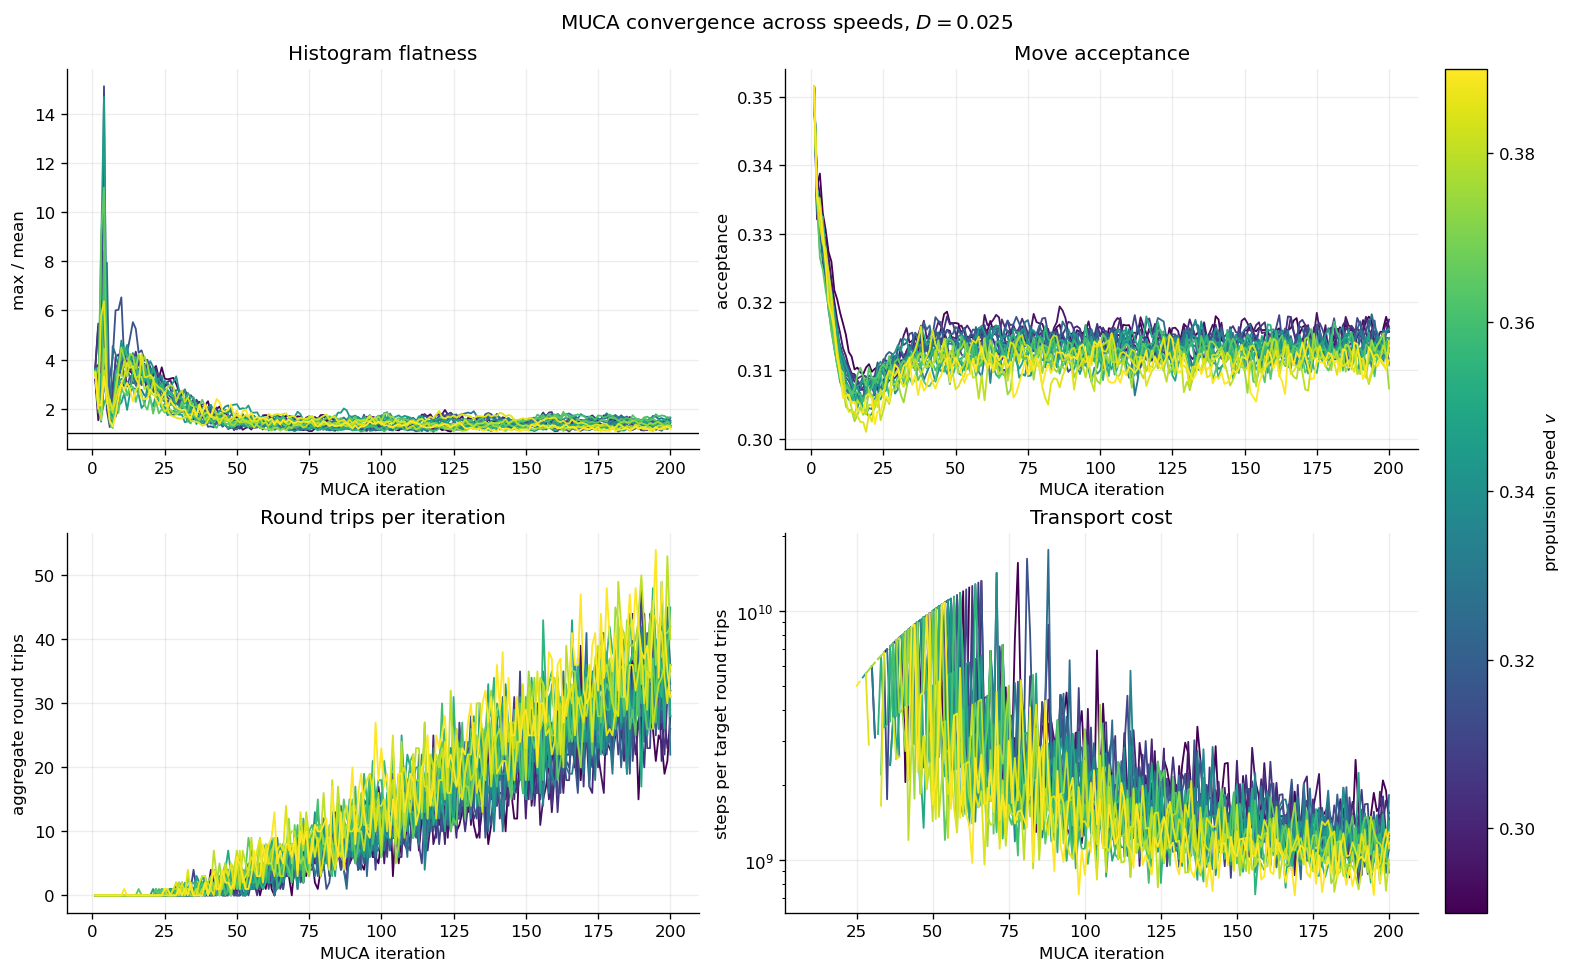

In [8]:
MUCA_ITER = {}
for row in CASES:
    p = row["case_dir"] / "muca_iteration_diagnostics.csv"
    if not p.is_file():
        warnings.warn(f"Missing {p}")
        continue
    df = pd.read_csv(p).apply(pd.to_numeric, errors="coerce")
    MUCA_ITER[row["v"]] = df

if not MUCA_ITER:
    raise FileNotFoundError("No muca_iteration_diagnostics.csv files found.")

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
ax1, ax2, ax3, ax4 = axes.ravel()

for v, df in MUCA_ITER.items():
    c = speed_color(v)
    ax1.plot(df["iteration"], df["flatness_max_over_mean"], lw=1.1, color=c)
    ax2.plot(df["iteration"], df["acceptance"], lw=1.1, color=c)
    ax3.plot(df["iteration"], df["roundtrips"], lw=1.1, color=c)
    if "steps_per_target_roundtrips" in df:
        y = pd.to_numeric(df["steps_per_target_roundtrips"], errors="coerce")
        ax4.plot(df["iteration"], y, lw=1.1, color=c)

ax1.axhline(1.0, lw=0.8, color="black")
ax1.set(xlabel="MUCA iteration", ylabel="max / mean", title="Histogram flatness")
ax2.set(xlabel="MUCA iteration", ylabel="acceptance", title="Move acceptance")
ax3.set(xlabel="MUCA iteration", ylabel="aggregate round trips", title="Round trips per iteration")
ax4.set(xlabel="MUCA iteration", ylabel="steps per target round trips", title="Transport cost")
ax4.set_yscale("log")

add_speed_colorbar(fig, axes)
fig.suptitle(rf"MUCA convergence across speeds, $D={FIXED_D:g}$")
finish_figure(fig, "01_muca_convergence.png")

In [9]:
muca_summary_rows = []
for v, df in MUCA_ITER.items():
    last = df.iloc[-1]
    tail = df.tail(min(10, len(df)))
    muca_summary_rows.append({
        "v": v,
        "iterations_completed": int(last["iteration"]),
        "final_acceptance": last.get("acceptance", np.nan),
        "final_flatness_max_over_mean": last.get("flatness_max_over_mean", np.nan),
        "final_flatness_mean_over_min": last.get("flatness_mean_over_min", np.nan),
        "final_roundtrips": last.get("roundtrips", np.nan),
        "last10_median_flatness": tail.get("flatness_max_over_mean", pd.Series(dtype=float)).median(),
        "last10_median_roundtrips": tail.get("roundtrips", pd.Series(dtype=float)).median(),
        "final_sampling_steps": last.get("sampling_steps", np.nan),
        "final_steps_per_target_roundtrips": last.get("steps_per_target_roundtrips", np.nan),
    })

muca_summary = pd.DataFrame(muca_summary_rows).sort_values("v")
display(muca_summary)

,v,iterations_completed,final_acceptance,final_flatness_max_over_mean,final_flatness_mean_over_min,final_roundtrips,last10_median_flatness,last10_median_roundtrips,final_sampling_steps,final_steps_per_target_roundtrips
0,0.290,200,0.316273,1.421918,1.124068,28.0,1.290516,25.5,800000000.0,1.428571e+09
1,0.295,200,0.315628,1.297655,1.112589,31.0,1.197206,31.5,800000000.0,1.290323e+09
2,0.300,200,0.317430,1.310952,1.292041,26.0,1.393534,31.0,800000000.0,1.538462e+09
3,0.305,200,0.311332,1.625571,1.232765,32.0,1.472345,29.0,800000000.0,1.250000e+09
4,0.310,200,0.310962,1.455887,1.161854,29.0,1.233406,31.0,800000000.0,1.379310e+09
5,0.315,200,0.315701,1.329771,1.147652,36.0,1.422764,32.0,800000000.0,1.111111e+09
6,0.320,200,0.314683,1.309235,1.191690,36.0,1.189925,31.0,800000000.0,1.111111e+09
7,0.325,200,0.316075,1.509959,1.244972,32.0,1.540563,32.0,800000000.0,1.250000e+09
8,0.330,200,0.314081,1.529689,1.282627,22.0,1.479886,29.5,800000000.0,1.818182e+09
9,0.335,200,0.314715,1.284382,1.095100,33.0,1.367279,35.0,800000000.0,1.212121e+09


## 7. Final MUCA histogram and learned logweights across speeds

The logweights are shifted by subtracting their value at the bin nearest
\(x(T)=-1\). Only logweight differences matter.

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/02_final_muca_histogram_logweights.png


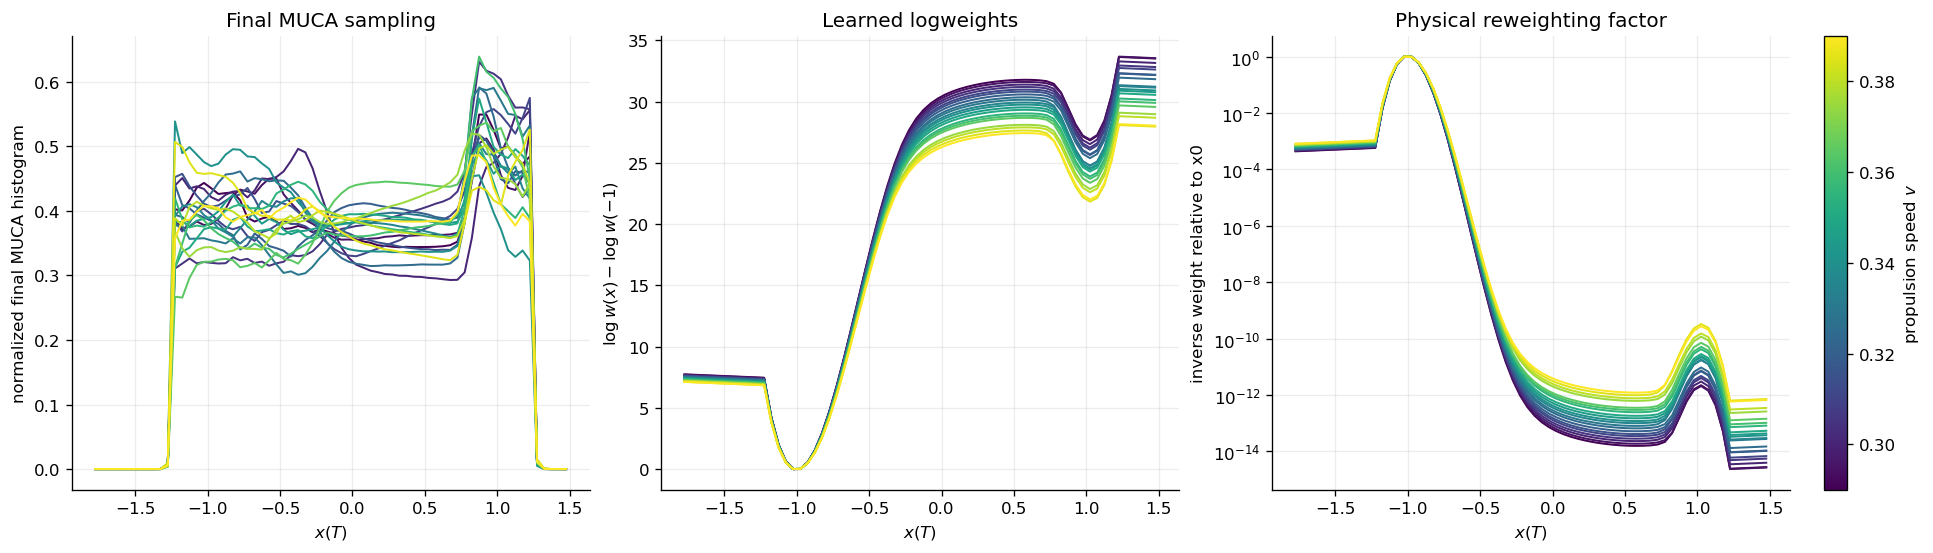

In [10]:
MUCA_LAST = {}
for row in CASES:
    p = row["case_dir"] / "muca_last_histogram_logweights.csv"
    if not p.is_file():
        warnings.warn(f"Missing {p}")
        continue
    df = pd.read_csv(p).apply(pd.to_numeric, errors="coerce")
    df = df.sort_values("x_T_center").reset_index(drop=True)
    MUCA_LAST[row["v"]] = df

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for v, df in MUCA_LAST.items():
    x = df["x_T_center"].to_numpy(float)
    counts = np.clip(df["last_hist_count"].to_numpy(float), 0, None)
    widths = bin_widths_from_centers(x)
    pdf = counts / (counts.sum() * widths) if counts.sum() > 0 else np.full_like(x, np.nan)
    axes[0].plot(x, pdf, lw=1.2, color=speed_color(v))

    logw = df["last_logweight"].to_numpy(float)
    finite = np.isfinite(x) & np.isfinite(logw)
    if finite.any():
        xx = x[finite]
        ww = logw[finite]
        i0 = np.argmin(np.abs(xx + 1.0))
        axes[1].plot(xx, ww - ww[i0], lw=1.2, color=speed_color(v))

    if "inverse_weight_relative_to_x0" in df:
        invw = pd.to_numeric(df["inverse_weight_relative_to_x0"], errors="coerce").to_numpy(float)
        good = np.isfinite(x) & np.isfinite(invw) & (invw > 0)
        axes[2].plot(x[good], invw[good], lw=1.2, color=speed_color(v))

axes[0].set(xlabel=r"$x(T)$", ylabel="normalized final MUCA histogram", title="Final MUCA sampling")
axes[1].set(xlabel=r"$x(T)$", ylabel=r"$\log w(x)-\log w(-1)$", title="Learned logweights")
axes[2].set(xlabel=r"$x(T)$", ylabel="inverse weight relative to x0", title="Physical reweighting factor")
axes[2].set_yscale("log")

add_speed_colorbar(fig, axes)
finish_figure(fig, "02_final_muca_histogram_logweights.png")

## 8. Logweight landscape as a speed–endpoint heatmap

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/03_logweight_speed_heatmap.png


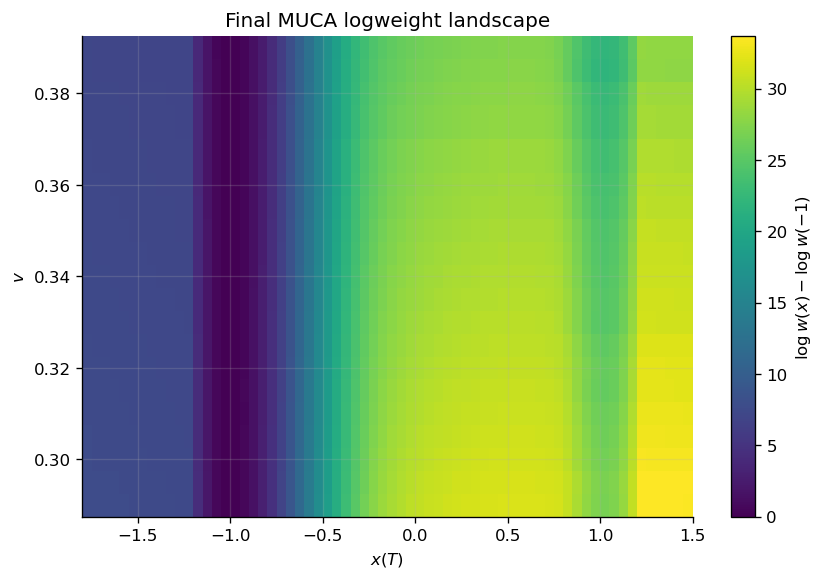

In [11]:
if MUCA_LAST:
    all_x = sorted(set(np.round(np.concatenate([
        df["x_T_center"].dropna().to_numpy(float) for df in MUCA_LAST.values()
    ]), 12)))

    logw_rows = []
    for v, df in MUCA_LAST.items():
        work = df[["x_T_center", "last_logweight"]].dropna().copy()
        x = work["x_T_center"].to_numpy(float)
        w = work["last_logweight"].to_numpy(float)
        i0 = np.argmin(np.abs(x + 1.0))
        for xx, ww in zip(x, w - w[i0]):
            logw_rows.append({"v": v, "x": xx, "shifted_logw": ww})

    logw_long = pd.DataFrame(logw_rows)
    pivot = logw_long.pivot_table(index="v", columns="x", values="shifted_logw", aggfunc="mean")
    pivot = pivot.sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    mesh = ax.pcolormesh(
        pivot.columns.to_numpy(float),
        pivot.index.to_numpy(float),
        pivot.to_numpy(float),
        shading="auto",
    )
    fig.colorbar(mesh, ax=ax, label=r"$\log w(x)-\log w(-1)$")
    ax.set(xlabel=r"$x(T)$", ylabel=r"$v$", title="Final MUCA logweight landscape")
    finish_figure(fig, "03_logweight_speed_heatmap.png")

# Production diagnostics

## 9. Reweighting ESS and final production round trips

,v,reweighting_ess,reweighting_n_samples,ESS_over_N,production_roundtrips_final_count
0,0.290,5.725359e+09,5.500000e+10,0.104097,3484.0
1,0.295,5.403622e+09,5.500000e+10,0.098248,3449.0
2,0.300,5.754888e+09,5.500000e+10,0.104634,3636.0
3,0.305,5.906265e+09,5.500000e+10,0.107387,3741.0
4,0.310,5.687662e+09,5.500000e+10,0.103412,3619.0
5,0.315,5.665046e+09,5.500000e+10,0.103001,3805.0
6,0.320,5.960165e+09,5.500000e+10,0.108367,3959.0
7,0.325,5.772766e+09,5.500000e+10,0.104959,3685.0
8,0.330,6.099926e+09,5.500000e+10,0.110908,3845.0
9,0.335,6.049720e+09,5.500000e+10,0.109995,3994.0


Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/04_production_ess_roundtrips.png


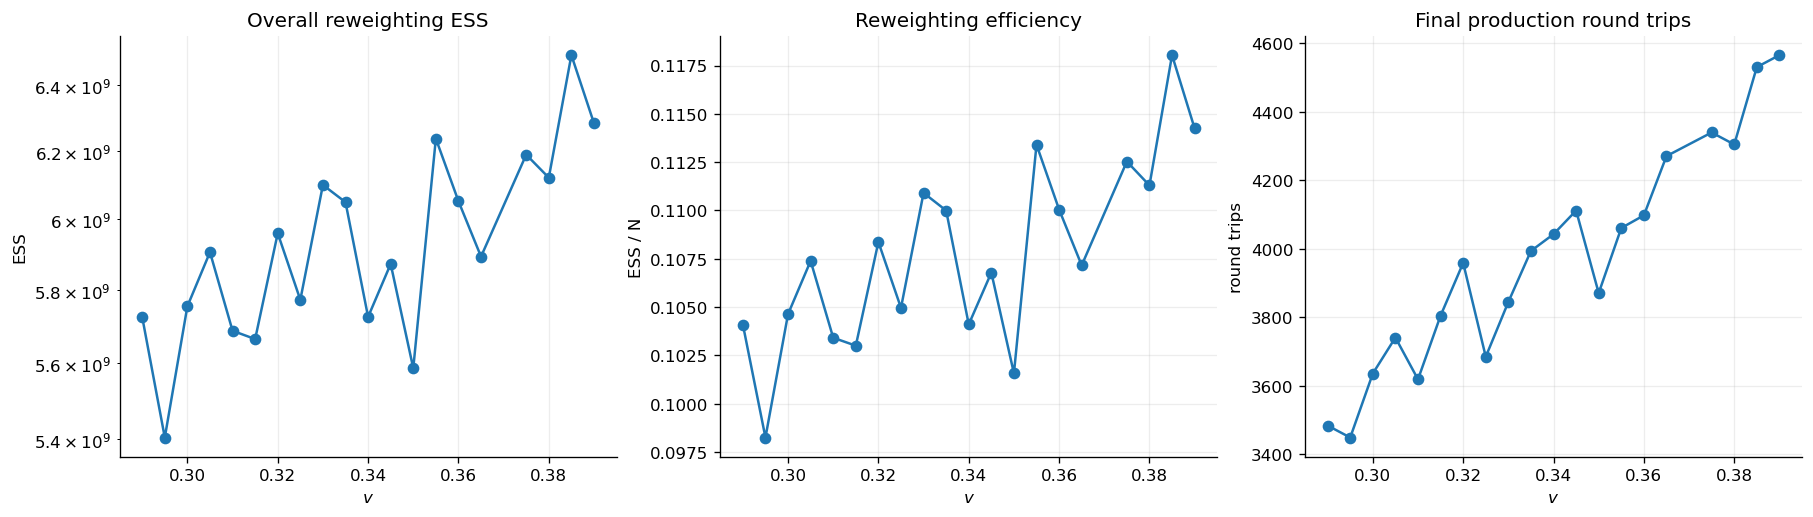

In [12]:
prod_diag = overview[[
    "v", "reweighting_ess", "reweighting_n_samples", "ESS_over_N",
    "production_roundtrips_final_count"
]].copy()

display(prod_diag)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
axes[0].plot(prod_diag["v"], prod_diag["reweighting_ess"], "o-")
axes[0].set(xlabel=r"$v$", ylabel="ESS", title="Overall reweighting ESS")
axes[0].set_yscale("log")

axes[1].plot(prod_diag["v"], prod_diag["ESS_over_N"], "o-")
axes[1].set(xlabel=r"$v$", ylabel="ESS / N", title="Reweighting efficiency")

axes[2].plot(prod_diag["v"], prod_diag["production_roundtrips_final_count"], "o-")
axes[2].set(xlabel=r"$v$", ylabel="round trips", title="Final production round trips")

finish_figure(fig, "04_production_ess_roundtrips.png")

## 10. Production round-trip traces

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/05_production_roundtrip_traces.png


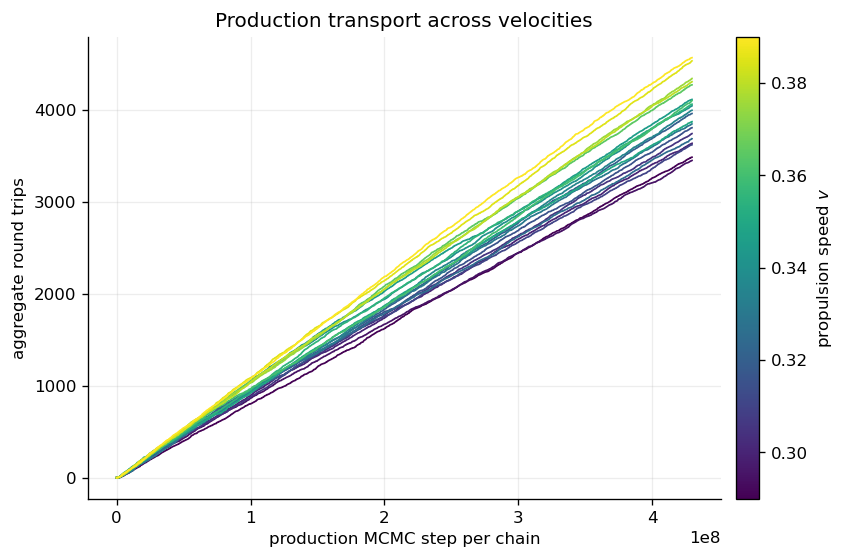

In [13]:
ROUNDTRIP_AGG = {}

fig, ax = plt.subplots(figsize=(8.2, 5.0))
for row in CASES:
    v = row["v"]
    p = row["case_dir"] / "production_roundtrip_aggregate.csv"
    if not p.is_file():
        continue
    df = pd.read_csv(p).apply(pd.to_numeric, errors="coerce")
    ROUNDTRIP_AGG[v] = df
    if {"local_step", "aggregate_roundtrips"}.issubset(df.columns):
        ax.plot(
            df["local_step"], df["aggregate_roundtrips"],
            lw=1.0, color=speed_color(v),
        )

ax.set(
    xlabel="production MCMC step per chain",
    ylabel="aggregate round trips",
    title="Production transport across velocities",
)
add_speed_colorbar(fig, ax)
finish_figure(fig, "05_production_roundtrip_traces.png")

# Reweighted physical results

## 11. Endpoint \(x(T)\) distributions across speeds

The left panel is the biased MUCA-production sampling distribution. The right
panel is the physical distribution after inverse-weight reweighting.

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/06_endpoint_distributions.png


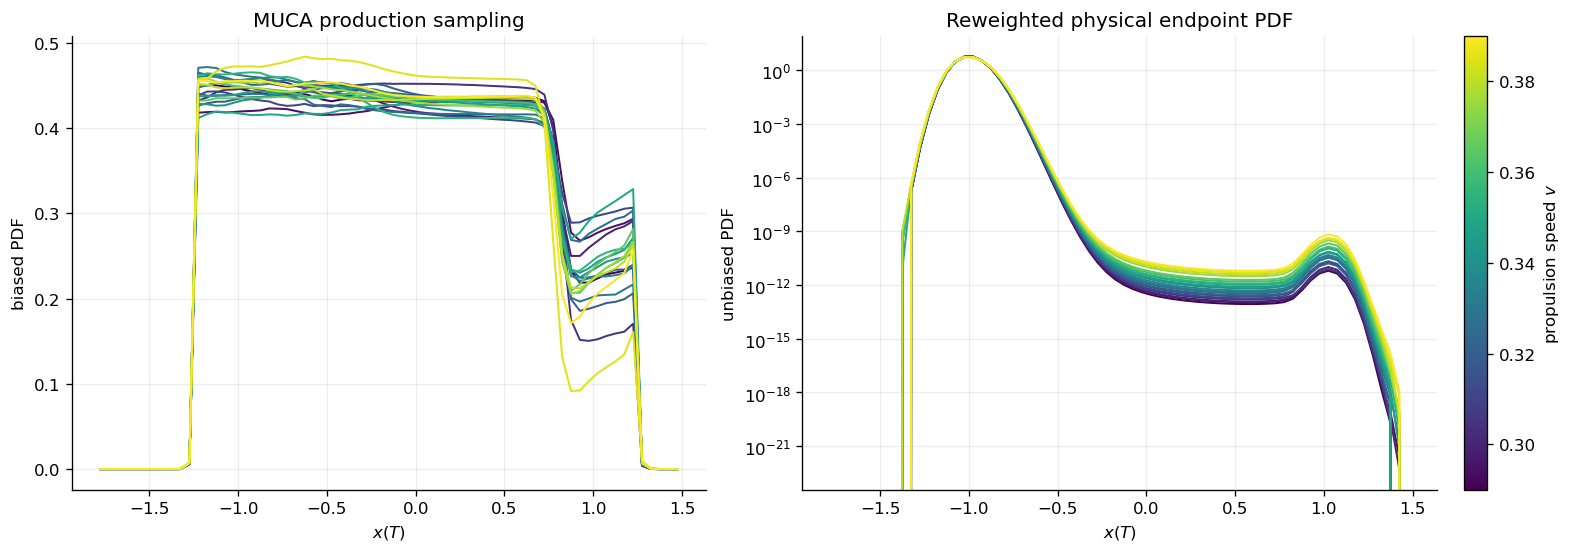

In [14]:
ENDPOINT = {}
for row in CASES:
    p = row["case_dir"] / "hist_endpoint_x_T.csv"
    if not p.is_file():
        continue
    df = pd.read_csv(p).apply(pd.to_numeric, errors="coerce").sort_values("x_T_center")
    ENDPOINT[row["v"]] = df

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for v, df in ENDPOINT.items():
    axes[0].plot(df["x_T_center"], df["biased_pdf"], lw=1.2, color=speed_color(v))
    axes[1].plot(df["x_T_center"], df["unbiased_pdf"], lw=1.2, color=speed_color(v))

axes[0].set(xlabel=r"$x(T)$", ylabel="biased PDF", title="MUCA production sampling")
axes[1].set(xlabel=r"$x(T)$", ylabel="unbiased PDF", title="Reweighted physical endpoint PDF")
axes[1].set_yscale("log")
add_speed_colorbar(fig, axes)
finish_figure(fig, "06_endpoint_distributions.png")

## 12. Endpoint-event probabilities and finite-time rate proxy

For \(R_a=\{x(T)>a\}\),

\[
P_v(R_a) = \Pr[x(T)>a],
\qquad
k_v^{(\mathrm{end})}=-\frac{1}{T}\log[1-P_v(R_a)].
\]

Because \(D\) is fixed, this is **not** an Arrhenius fit in \(1/D\). It is a
speed-dependent finite-time endpoint diagnostic.

,v,threshold,p_unbiased,p_biased,k_endpoint,I_eff,p_over_T,Delta_I
0,0.290,0.0,1.049966e-12,0.451594,2.624914e-14,1.379113,2.624914e-14,0.232501
1,0.295,0.0,1.292772e-12,0.474070,3.231929e-14,1.368712,3.231929e-14,0.222100
2,0.300,0.0,1.676137e-12,0.452177,4.190344e-14,1.355726,4.190344e-14,0.209115
3,0.305,0.0,1.331876e-12,0.434368,3.329691e-14,1.367222,3.329691e-14,0.220610
4,0.310,0.0,2.934788e-12,0.463125,7.336970e-14,1.327719,7.336970e-14,0.181107
5,0.315,0.0,3.518476e-12,0.451177,8.796189e-14,1.318650,8.796189e-14,0.172038
6,0.320,0.0,2.784586e-12,0.435445,6.961465e-14,1.330346,6.961465e-14,0.183734
7,0.325,0.0,5.487736e-12,0.460952,1.371934e-13,1.296425,1.371934e-13,0.149813
8,0.330,0.0,6.912398e-12,0.435132,1.728100e-13,1.284885,1.728100e-13,0.138273
9,0.335,0.0,7.814981e-12,0.436220,1.953745e-13,1.278749,1.953745e-13,0.132137



EFFECTIVE ACTION VALUES
D = 0.025

Endpoint condition: x(T) > 0
v = 0.290 | P = 1.049966e-12 | I_eff = 1.379113 | Delta_I = 0.232501
v = 0.295 | P = 1.292772e-12 | I_eff = 1.368712 | Delta_I = 0.222100
v = 0.300 | P = 1.676137e-12 | I_eff = 1.355726 | Delta_I = 0.209115
v = 0.305 | P = 1.331876e-12 | I_eff = 1.367222 | Delta_I = 0.220610
v = 0.310 | P = 2.934788e-12 | I_eff = 1.327719 | Delta_I = 0.181107
v = 0.315 | P = 3.518476e-12 | I_eff = 1.318650 | Delta_I = 0.172038
v = 0.320 | P = 2.784586e-12 | I_eff = 1.330346 | Delta_I = 0.183734
v = 0.325 | P = 5.487736e-12 | I_eff = 1.296425 | Delta_I = 0.149813
v = 0.330 | P = 6.912398e-12 | I_eff = 1.284885 | Delta_I = 0.138273
v = 0.335 | P = 7.814981e-12 | I_eff = 1.278749 | Delta_I = 0.132137
v = 0.340 | P = 1.076830e-11 | I_eff = 1.262721 | Delta_I = 0.116109
v = 0.345 | P = 1.194429e-11 | I_eff = 1.257538 | Delta_I = 0.110927
v = 0.350 | P = 1.812592e-11 | I_eff = 1.236684 | Delta_I = 0.090072
v = 0.355 | P = 2.018399e-11 | I_eff =

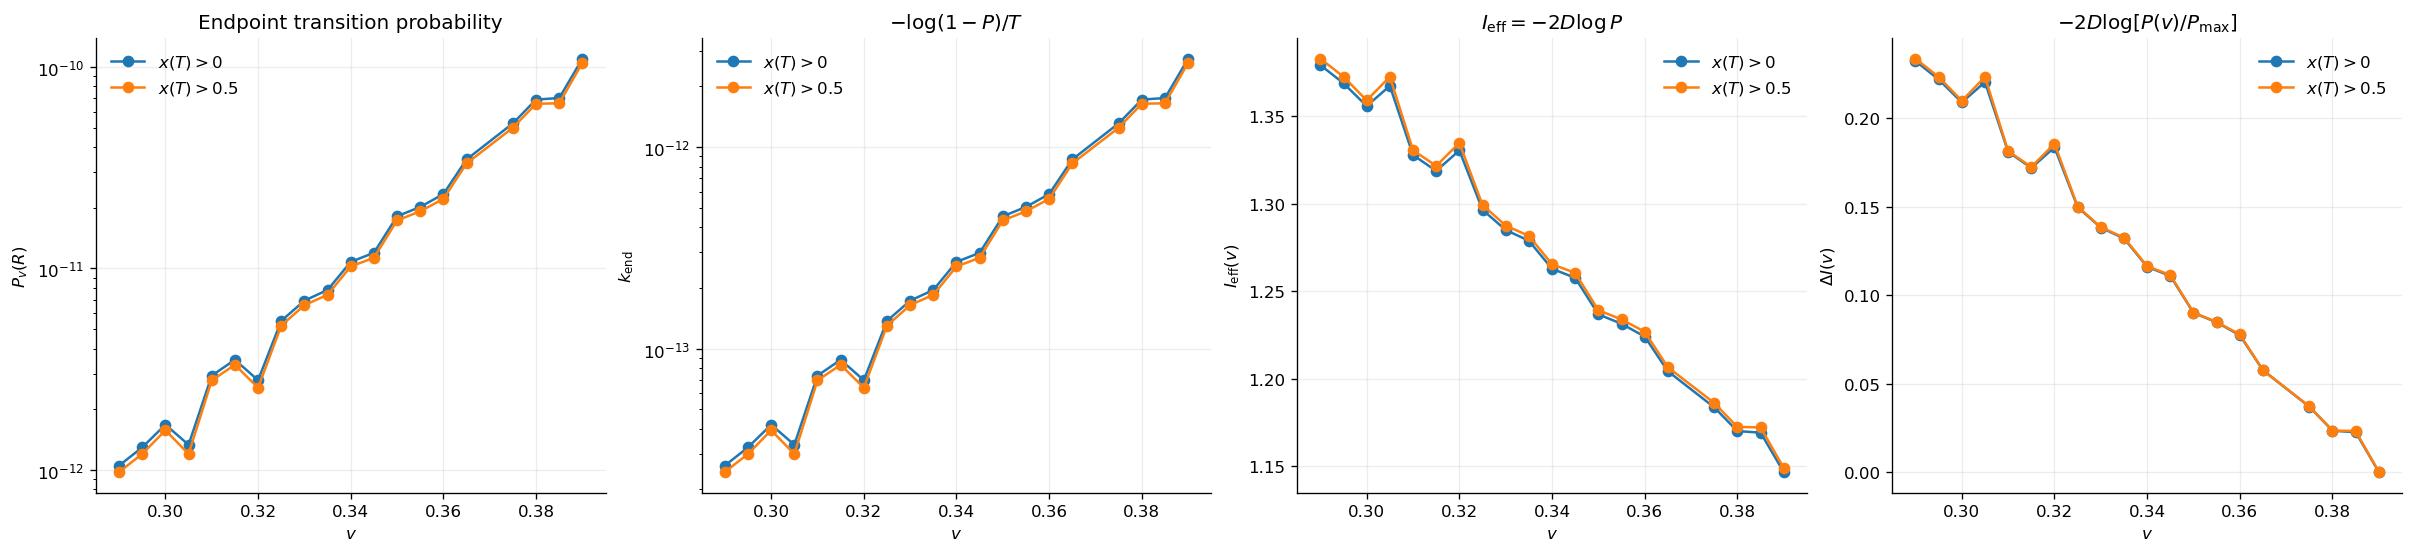

In [15]:
# ============================================================
# ENDPOINT PROBABILITY, RATE, AND EFFECTIVE ACTION VS SPEED
# ============================================================

def probability_above_from_counts(
    df: pd.DataFrame,
    threshold: float,
    prefix="unbiased"
) -> float:

    x = pd.to_numeric(
        df["x_T_center"],
        errors="coerce"
    ).to_numpy(float)

    mass = pd.to_numeric(
        df[f"{prefix}_count"],
        errors="coerce"
    ).to_numpy(float)

    good = np.isfinite(x) & np.isfinite(mass)

    x = x[good]
    mass = mass[good]

    mass = np.clip(mass, 0, None)

    total = mass.sum()

    if total <= 0:
        return math.nan

    return float(
        mass[x > threshold].sum() / total
    )


# ------------------------------------------------------------
# Fixed noise
# ------------------------------------------------------------

D_ACTION = FIXED_D       # = 0.025


# ------------------------------------------------------------
# Build table
# ------------------------------------------------------------

event_rows = []

for row in CASES:

    v = row["v"]

    if v not in ENDPOINT:
        continue

    T = as_float(
        row["summary"],
        "trajectory_T",
        40.0,
    )

    for th in ENDPOINT_THRESHOLDS:

        # Physical/reweighted probability
        p = probability_above_from_counts(
            ENDPOINT[v],
            th,
            "unbiased",
        )

        # MUCA-biased probability, only diagnostic
        pb = probability_above_from_counts(
            ENDPOINT[v],
            th,
            "biased",
        )

        if np.isfinite(p) and p > 0:

            # ------------------------------------------------
            # Effective endpoint action:
            #
            # P(R) ~ exp[-I/2D]
            #
            # therefore
            #
            # I_eff = -2D log P(R)
            #
            # This assumes an O(1) prefactor.
            # ------------------------------------------------

            I_eff = -2 * D_ACTION * np.log(p)

        else:

            I_eff = np.nan


        # ----------------------------------------------------
        # Finite-time rate estimate
        #
        # P = 1 - exp(-kT)
        #
        # => k = -log(1-P)/T
        # ----------------------------------------------------

        if np.isfinite(p):

            pclip = np.clip(
                p,
                0,
                1 - np.finfo(float).eps,
            )

            k = -np.log1p(-pclip) / T

        else:

            k = np.nan


        event_rows.append({
            "v": v,
            "threshold": th,

            "p_unbiased": p,
            "p_biased": pb,

            "k_endpoint": k,

            # effective action
            "I_eff": I_eff,

            "p_over_T": (
                p / T
                if np.isfinite(p)
                else np.nan
            ),
        })


event_table = (
    pd.DataFrame(event_rows)
    .sort_values(["threshold", "v"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Relative action
#
# ΔI(v) = -2D log[P(v)/P_max]
#
# Therefore min ΔI = 0.
# ------------------------------------------------------------

event_table["Delta_I"] = np.nan

for th, idx in event_table.groupby("threshold").groups.items():

    pvals = event_table.loc[idx, "p_unbiased"].to_numpy(float)

    good = np.isfinite(pvals) & (pvals > 0)

    if not np.any(good):
        continue

    pmax = np.max(pvals[good])

    valid_idx = np.asarray(list(idx))[good]

    event_table.loc[valid_idx, "Delta_I"] = (
        -2 * D_ACTION
        * np.log(
            event_table.loc[valid_idx, "p_unbiased"]
            / pmax
        )
    )


# ------------------------------------------------------------
# Print numerical values
# ------------------------------------------------------------

display(event_table)


print()
print("========================================================")
print("EFFECTIVE ACTION VALUES")
print("D =", D_ACTION)
print("========================================================")

for th, g in event_table.groupby("threshold"):

    print()
    print(f"Endpoint condition: x(T) > {th:g}")

    for _, r in g.iterrows():

        print(
            f"v = {r['v']:.3f}"
            f" | P = {r['p_unbiased']:.6e}"
            f" | I_eff = {r['I_eff']:.6f}"
            f" | Delta_I = {r['Delta_I']:.6f}"
        )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 4.5),
    constrained_layout=True,
)


for th, g in event_table.groupby("threshold"):

    label = rf"$x(T)>{th:g}$"

    # Probability
    axes[0].plot(
        g["v"],
        g["p_unbiased"],
        "o-",
        label=label,
    )

    # Rate
    axes[1].plot(
        g["v"],
        g["k_endpoint"],
        "o-",
        label=label,
    )

    # Absolute effective action
    axes[2].plot(
        g["v"],
        g["I_eff"],
        "o-",
        label=label,
    )

    # Relative action
    axes[3].plot(
        g["v"],
        g["Delta_I"],
        "o-",
        label=label,
    )


axes[0].set(
    xlabel=r"$v$",
    ylabel=r"$P_v(R)$",
    title="Endpoint transition probability",
)

axes[1].set(
    xlabel=r"$v$",
    ylabel=r"$k_{\rm end}$",
    title=r"$-\log(1-P)/T$",
)

axes[2].set(
    xlabel=r"$v$",
    ylabel=r"$I_{\rm eff}(v)$",
    title=r"$I_{\rm eff}=-2D\log P$",
)

axes[3].set(
    xlabel=r"$v$",
    ylabel=r"$\Delta I(v)$",
    title=r"$-2D\log[P(v)/P_{\max}]$",
)


axes[0].set_yscale("log")
axes[1].set_yscale("log")

for ax in axes:
    ax.legend()


finish_figure(
    fig,
    "07_endpoint_probability_rate_action.png",
)

## 13. Conditioned whole-path \(y\) occupation for \(x(T)>0.5\)

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/08_conditioned_path_y_across_speeds.png


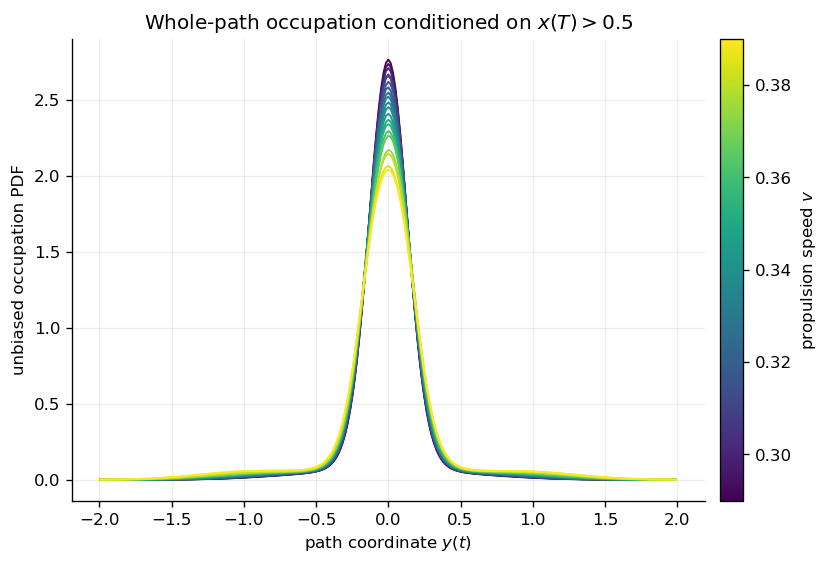

In [16]:
PATH_Y = {}
fig, ax = plt.subplots(figsize=(8.2, 5.0))

for row in CASES:
    v = row["v"]
    p = row["case_dir"] / ENDPOINT_PATH_Y_FILE
    if not p.is_file():
        continue
    df = pd.read_csv(p).apply(pd.to_numeric, errors="coerce").sort_values("path_y_center")
    PATH_Y[v] = df
    ax.plot(df["path_y_center"], df["unbiased_pdf"], lw=1.15, color=speed_color(v))

ax.set(
    xlabel=r"path coordinate $y(t)$",
    ylabel="unbiased occupation PDF",
    title=r"Whole-path occupation conditioned on $x(T)>0.5$",
)
add_speed_colorbar(fig, ax)
finish_figure(fig, "08_conditioned_path_y_across_speeds.png")

## 14. Simple symmetry-breaking order parameters from the conditioned path occupation

These are descriptive finite-\(D\), finite-\(T\) observables:

- \(\langle |y|\rangle\),
- \(\sqrt{\langle y^2\rangle}\),
- the absolute location of the positive-\(y\) mode.

The subsequent LDF/Landau section is more directly tied to your large-deviation
interpretation.

## 15. Conditioned \(x\)-\(y\) occupation maps at representative speeds

Each map uses the **unbiased/reweighted** path occupation conditioned on
\(x(T)>0.5\). The actual left-hand path cutoff is whatever was exported in
`case_summary.csv`.

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/10_path_xy_v0p320ppng


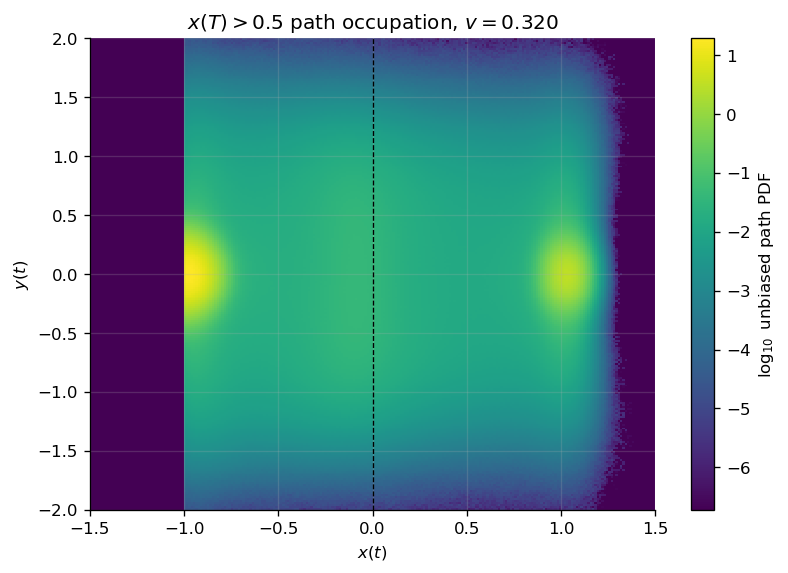

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/10_path_xy_v0p340ppng


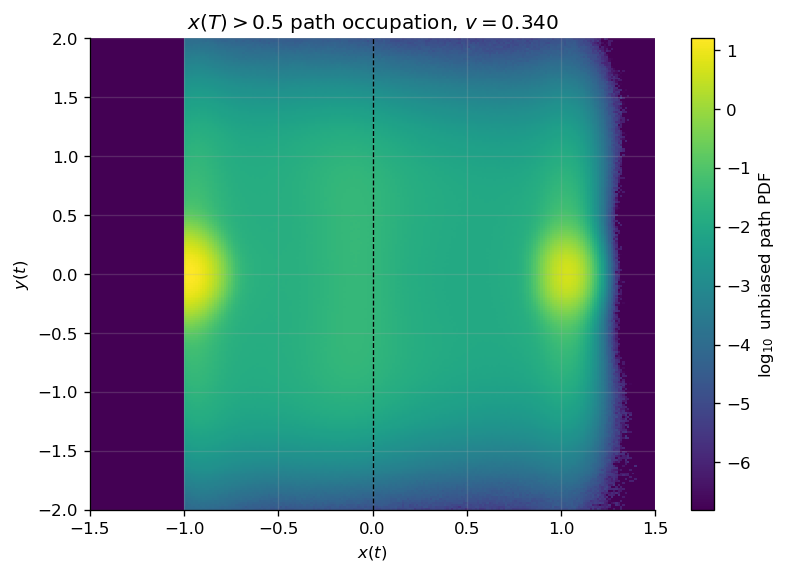

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/10_path_xy_v0p350ppng


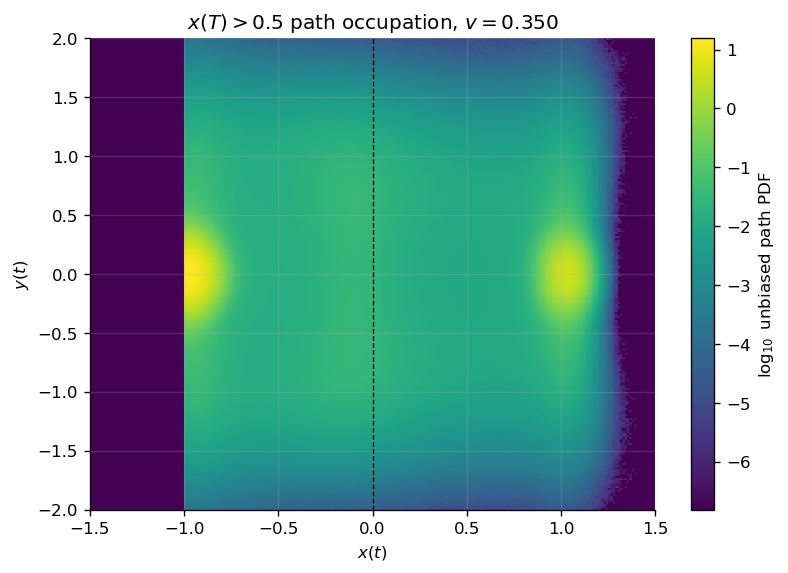

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/10_path_xy_v0p365ppng


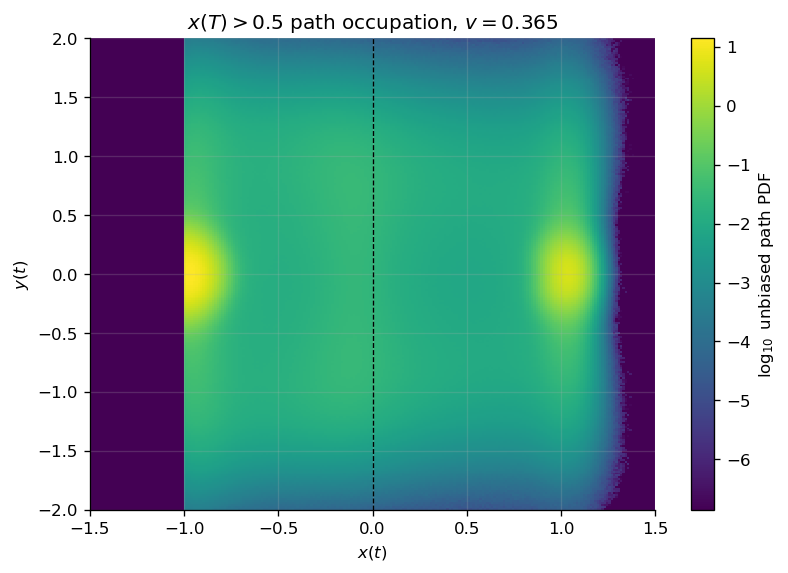

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/10_path_xy_v0p390ppng


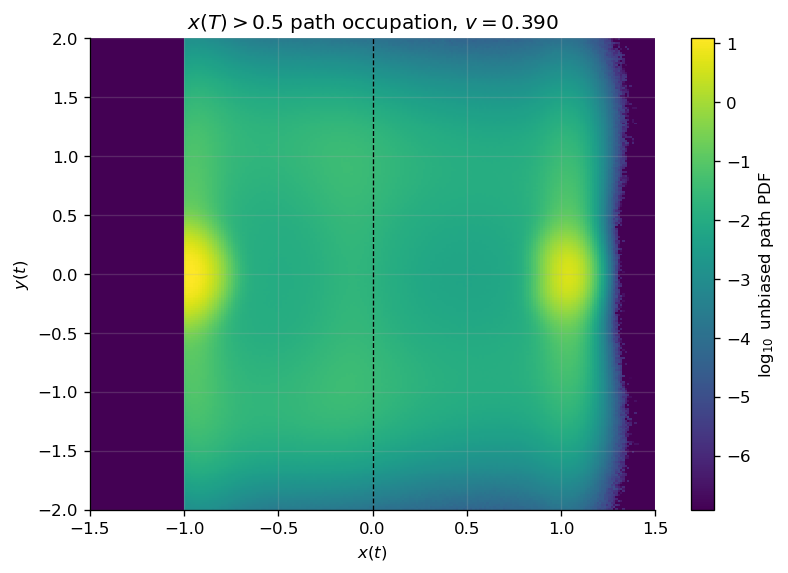

In [17]:
def nearest_available_speed(target: float, available) -> float:
    a = np.asarray(sorted(available), dtype=float)
    return float(a[np.argmin(np.abs(a - target))])


PATH_XY = {}
for row in CASES:
    v = row["v"]
    p = row["case_dir"] / ENDPOINT_PATH_FILE
    if p.is_file():
        PATH_XY[v] = pd.read_csv(p).apply(pd.to_numeric, errors="coerce")

selected_map_speeds = []
for target in REPRESENTATIVE_SPEEDS:
    if PATH_XY:
        vv = nearest_available_speed(target, PATH_XY.keys())
        if vv not in selected_map_speeds:
            selected_map_speeds.append(vv)

for v in selected_map_speeds:
    df = PATH_XY[v]
    xvals = np.sort(df["path_x_center"].dropna().unique())
    yvals = np.sort(df["path_y_center"].dropna().unique())
    pivot = df.pivot_table(
        index="path_y_center",
        columns="path_x_center",
        values="unbiased_pdf",
        aggfunc="sum",
    ).reindex(index=yvals, columns=xvals)

    z = pivot.to_numpy(float)
    positive = z[np.isfinite(z) & (z > 0)]
    if positive.size:
        floor = np.nanmax(positive) * 1e-8
        zshow = np.log10(np.maximum(z, floor))
    else:
        zshow = z

    fig, ax = plt.subplots(figsize=(7.6, 5.1))
    mesh = ax.pcolormesh(xvals, yvals, zshow, shading="auto")
    fig.colorbar(mesh, ax=ax, label=r"$\log_{10}$ unbiased path PDF")
    ax.axvline(0.0, lw=0.8, ls="--", color="black")
    ax.set(
        xlabel=r"$x(t)$",
        ylabel=r"$y(t)$",
        title=rf"$x(T)>0.5$ path occupation, $v={v:.3f}$",
    )
    finish_figure(fig, f"10_path_xy_v{v:.3f}.png".replace(".", "p"))

,v,x_min,x_max,x_center,x_width,mean_abs_y,sqrt_mean_y2,positive_mode_abs_y
0,0.290,-1.0,1.1,0.05,2.1,0.138139,0.206739,0.000000
1,0.295,-1.0,1.1,0.05,2.1,0.140517,0.211487,0.000000
2,0.300,-1.0,1.1,0.05,2.1,0.142621,0.215451,0.000000
3,0.305,-1.0,1.1,0.05,2.1,0.145235,0.219894,0.000000
4,0.310,-1.0,1.1,0.05,2.1,0.146877,0.223744,0.000000
...,...,...,...,...,...,...,...,...
115,0.365,0.1,0.4,0.25,0.3,0.673302,0.772642,0.746888
116,0.375,0.1,0.4,0.25,0.3,0.720983,0.816233,0.846473
117,0.380,0.1,0.4,0.25,0.3,0.731732,0.826393,0.879668
118,0.385,0.1,0.4,0.25,0.3,0.765079,0.856720,0.879668


Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/path_order_parameters_different_x_filters.png


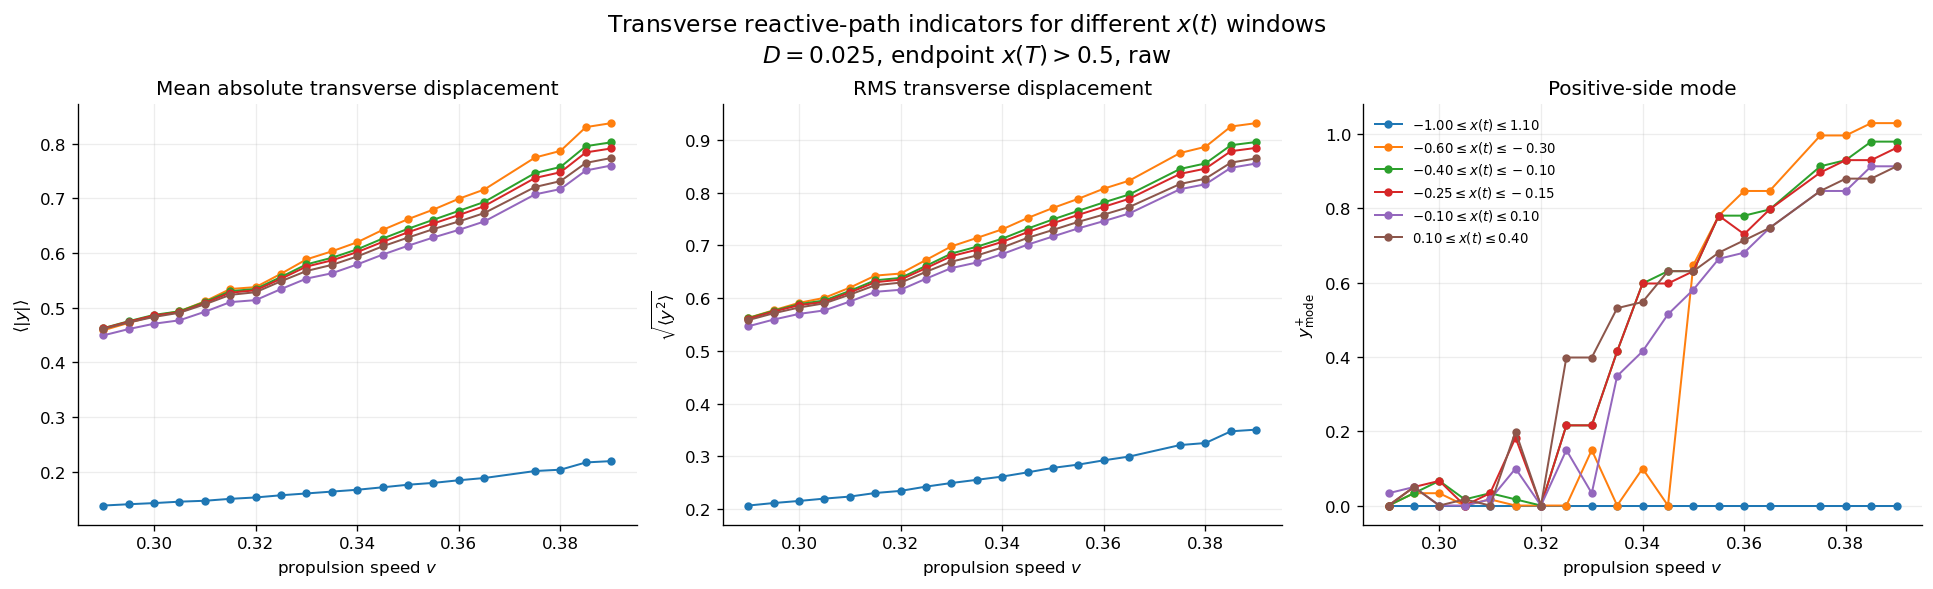

In [18]:
# ============================================================
# TRANSVERSE PATH INDICATORS FOR DIFFERENT x(t) FILTERS
#
# Uses PATH_XY, because PATH_Y has already integrated over x.
#
# Computes versus speed:
#
#   <|y|>
#   sqrt(<y^2>)
#   positive-y mode
#
# for several x(t) windows, always conditioned on x(T)>0.5.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

X_FILTERS = [
    (-1.00,  1.10),   # almost whole retained reactive path
    (-0.60, -0.30),
    (-0.40, -0.10),   # important transition-region slice
    (-0.25, -0.15),   # narrow slice around x ~ -0.2
    (-0.10,  0.10),   # around central region
    ( 0.10,  0.40),
]

# Symmetrize p(y) under y -> -y before computing observables?
#
# False = raw sampled distribution
# True  = remove finite-sampling upper/lower imbalance
SYMMETRIZE = False

# Restrict y range if desired
Y_MIN_FILTER = -1.6
Y_MAX_FILTER =  1.6

SAVE_FIGURE = True


# ============================================================
# HELPER: construct p(y) inside one x(t) interval
# ============================================================

def filtered_path_y_distribution(
    df,
    x_min,
    x_max,
    symmetrize=False,
):

    # Select path-occupation bins in the desired x(t) region
    cut = df[
        (df["path_x_center"] >= x_min)
        &
        (df["path_x_center"] <= x_max)
        &
        (df["path_y_center"] >= Y_MIN_FILTER)
        &
        (df["path_y_center"] <= Y_MAX_FILTER)
    ].copy()

    if cut.empty:
        return None

    # Integrate over x inside this interval
    prof = (
        cut.groupby(
            "path_y_center",
            as_index=False,
        )
        .agg(
            unbiased_count=(
                "unbiased_count",
                "sum",
            )
        )
        .sort_values(
            "path_y_center"
        )
    )

    y = prof[
        "path_y_center"
    ].to_numpy(float)

    m = prof[
        "unbiased_count"
    ].to_numpy(float)

    good = (
        np.isfinite(y)
        &
        np.isfinite(m)
    )

    y = y[good]
    m = m[good]

    m = np.clip(
        m,
        0.0,
        None,
    )

    if m.sum() <= 0:
        return None


    # --------------------------------------------------------
    # Optional y -> -y symmetrization
    # --------------------------------------------------------

    if symmetrize:

        reflected = np.interp(
            -y,
            y,
            m,
            left=np.nan,
            right=np.nan,
        )

        both = (
            np.isfinite(m)
            &
            np.isfinite(reflected)
        )

        m_sym = m.copy()

        m_sym[both] = 0.5 * (
            m[both]
            +
            reflected[both]
        )

        m = m_sym


    # Probability mass over the y bins
    prob = m / m.sum()

    return y, prob


# ============================================================
# COMPUTE OBSERVABLES
# ============================================================

order_rows = []


for x_min, x_max in X_FILTERS:

    for v in sorted(PATH_XY):

        result = filtered_path_y_distribution(
            PATH_XY[v],
            x_min=x_min,
            x_max=x_max,
            symmetrize=SYMMETRIZE,
        )

        if result is None:
            continue

        y, prob = result


        # ----------------------------------------------------
        # <|y|>
        # ----------------------------------------------------

        mean_abs_y = np.sum(
            np.abs(y) * prob
        )


        # ----------------------------------------------------
        # sqrt(<y^2>)
        # ----------------------------------------------------

        rms_y = np.sqrt(
            np.sum(
                y**2 * prob
            )
        )


        # ----------------------------------------------------
        # Positive-side mode
        #
        # argmax_{y >= 0} p(y)
        # ----------------------------------------------------

        pos = y >= 0

        if np.any(pos):

            y_pos = y[pos]
            p_pos = prob[pos]

            mode_abs = np.abs(
                y_pos[
                    np.argmax(p_pos)
                ]
            )

        else:

            mode_abs = np.nan


        order_rows.append({

            "v": v,

            "x_min": x_min,
            "x_max": x_max,

            "x_center": 0.5 * (
                x_min + x_max
            ),

            "x_width": (
                x_max - x_min
            ),

            "mean_abs_y": mean_abs_y,

            "sqrt_mean_y2": rms_y,

            "positive_mode_abs_y": mode_abs,
        })


order_xfiltered = (
    pd.DataFrame(order_rows)
    .sort_values([
        "x_min",
        "x_max",
        "v",
    ])
    .reset_index(drop=True)
)


display(order_xfiltered)


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
    constrained_layout=True,
)


observables = [

    (
        "mean_abs_y",
        r"$\langle |y|\rangle$",
        "Mean absolute transverse displacement",
    ),

    (
        "sqrt_mean_y2",
        r"$\sqrt{\langle y^2\rangle}$",
        "RMS transverse displacement",
    ),

    (
        "positive_mode_abs_y",
        r"$y_{\rm mode}^{+}$",
        "Positive-side mode",
    ),
]


for (
    x_min,
    x_max
), g in order_xfiltered.groupby(
    [
        "x_min",
        "x_max",
    ]
):

    g = g.sort_values(
        "v"
    )

    label = (
        rf"${x_min:.2f}"
        rf"\leq x(t)\leq"
        rf"{x_max:.2f}$"
    )


    for ax, (
        col,
        ylabel,
        title,
    ) in zip(
        axes,
        observables,
    ):

        ax.plot(
            g["v"],
            g[col],
            "o-",
            ms=4,
            lw=1.2,
            label=label,
        )


for ax, (
    col,
    ylabel,
    title,
) in zip(
    axes,
    observables,
):

    ax.set(
        xlabel=r"propulsion speed $v$",
        ylabel=ylabel,
        title=title,
    )


axes[2].legend(
    fontsize=8,
    ncol=1,
)


sym_text = (
    "symmetrized"
    if SYMMETRIZE
    else "raw"
)


fig.suptitle(
    rf"Transverse reactive-path indicators for different $x(t)$ windows"
    "\n"
    rf"$D={FIXED_D:g}$, endpoint $x(T)>0.5$, {sym_text}",
    fontsize=14,
)


if SAVE_FIGURE:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    outfile = (
        OUTPUT_DIR
        / "path_order_parameters_different_x_filters.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        outfile,
    )


plt.show()

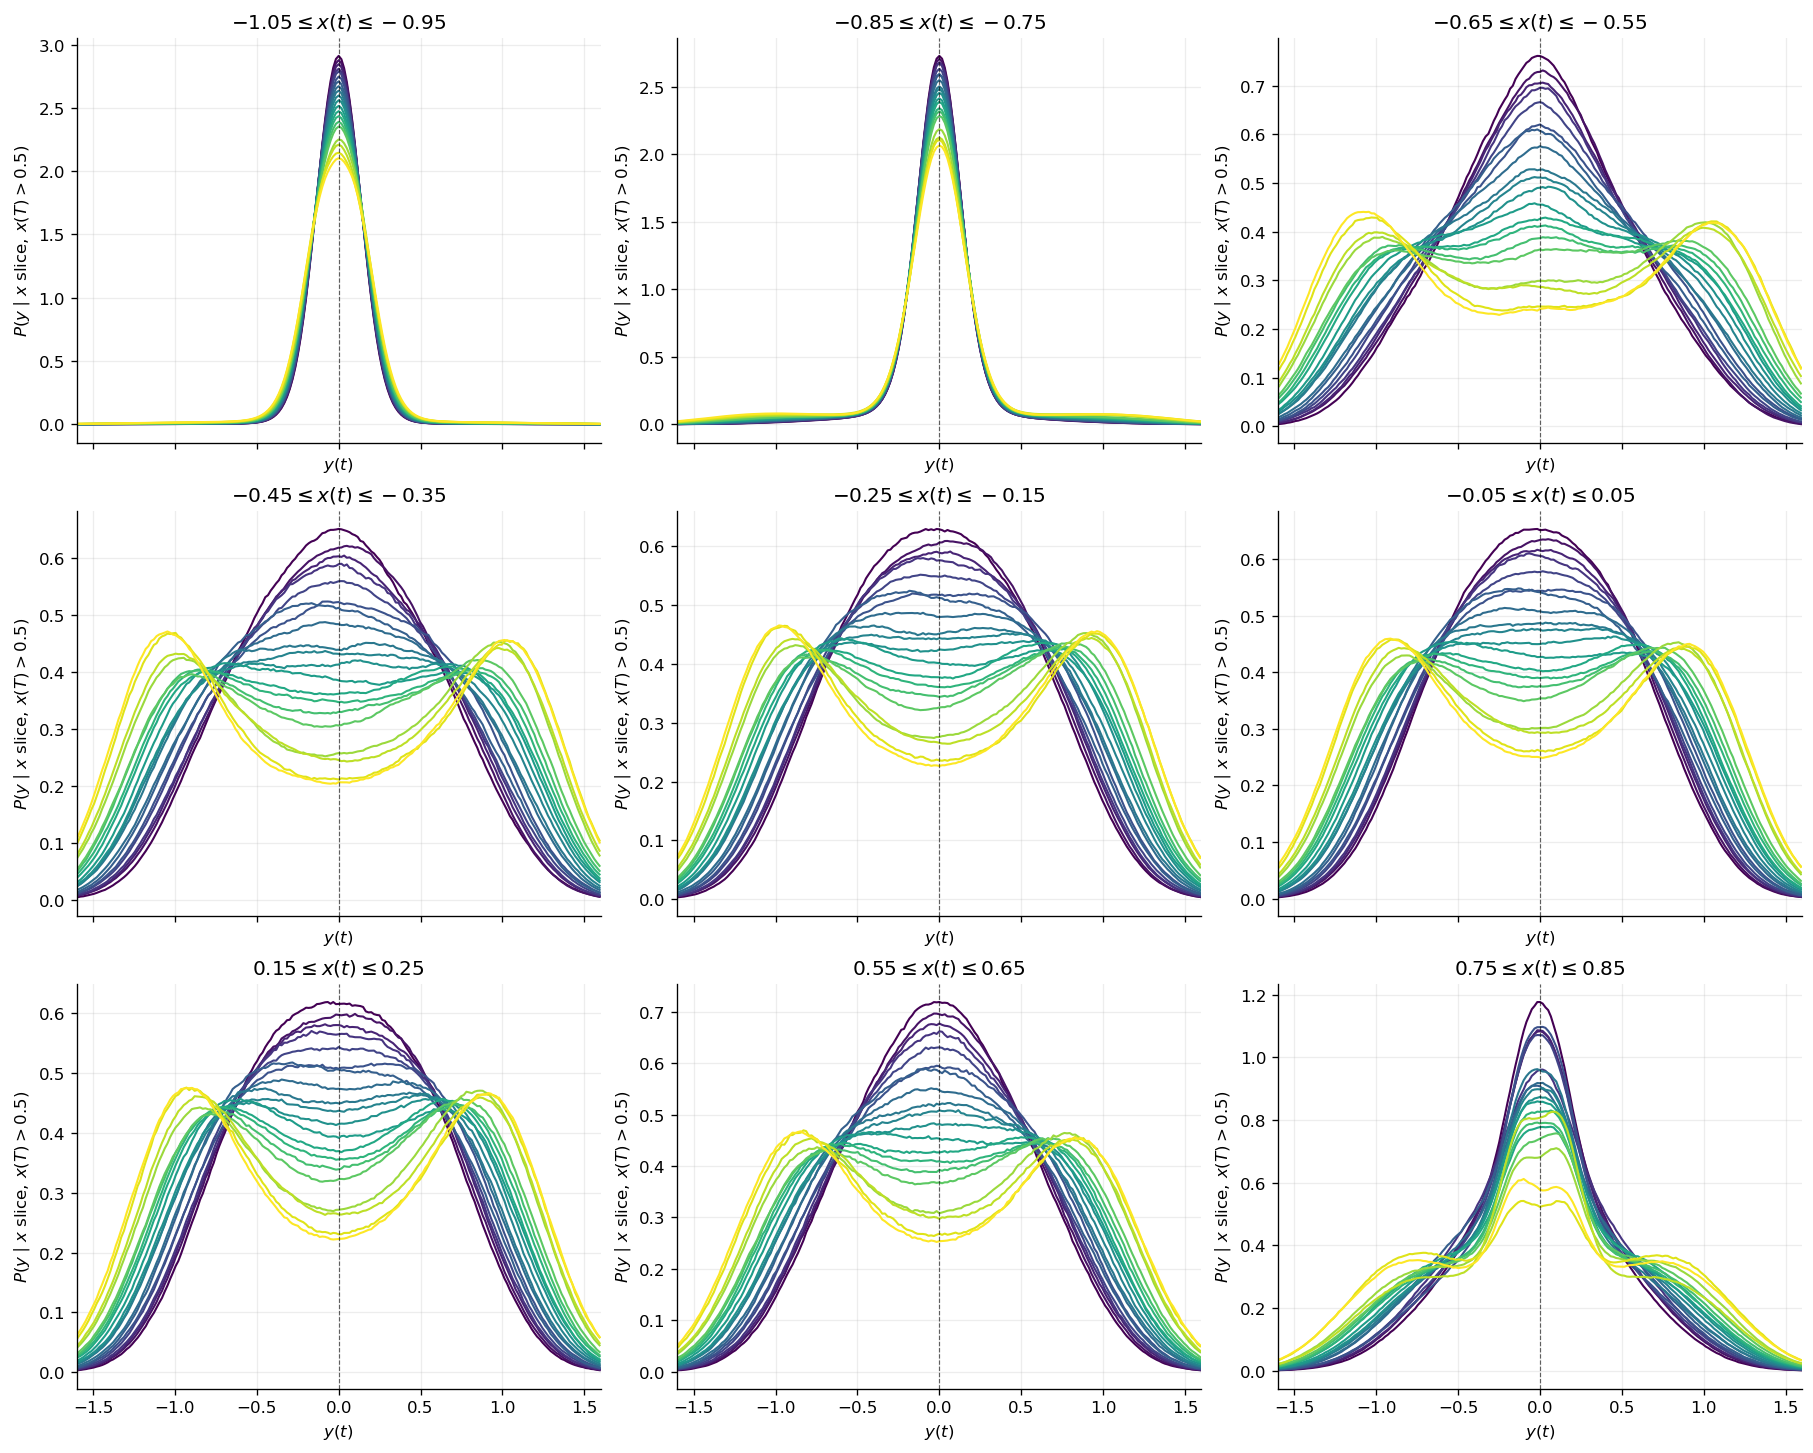

In [19]:
# ============================================================
# PATH-OCCUPATION SLICES
# P(y | x(t) in slice, x(T)>0.5) for all propulsion speeds
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

# Centers of the x slices you want to inspect
SLICE_CENTERS = [
    -1.00,
    -0.80,
    -0.60,
    -0.40,
    -0.20,
     0.00,
     0.20,
     0.60,
     0.80,
]

# Each slice is:
# x_c - SLICE_HALF_WIDTH <= x(t) <= x_c + SLICE_HALF_WIDTH
SLICE_HALF_WIDTH = 0.05

# Plot only this y range
Y_PLOT_MIN = -1.6
Y_PLOT_MAX =  1.6

# Use reweighted physical occupation.
# Change to "biased_count" if you specifically want the MUCA-biased ensemble.
COUNT_COLUMN = "unbiased_count"

# Optional symmetry operation.
# Keep FALSE first so you can actually see whether numerical/asampling
# asymmetry exists in the raw data.
SYMMETRIZE = False

# Save figure?
SAVE_SLICE_FIGURE = True


# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------

def path_y_slice(df, x_center, half_width, count_column="unbiased_count",
                 symmetrize=False):

    xlo = x_center - half_width
    xhi = x_center + half_width

    # Select all path-occupation bins belonging to this x slice.
    cut = df[
        (df["path_x_center"] >= xlo) &
        (df["path_x_center"] <= xhi)
    ].copy()

    if cut.empty:
        return None

    # Integrate occupation over x inside the selected slice.
    prof = (
        cut.groupby("path_y_center", as_index=False)[count_column]
        .sum()
        .sort_values("path_y_center")
    )

    y = prof["path_y_center"].to_numpy(float)
    counts = prof[count_column].to_numpy(float)

    good = np.isfinite(y) & np.isfinite(counts)
    y = y[good]
    counts = counts[good]

    counts = np.clip(counts, 0.0, None)

    if counts.sum() <= 0:
        return None

    # --------------------------------------------------------
    # Optional y -> -y symmetrization
    # --------------------------------------------------------
    if symmetrize:
        reflected = np.interp(
            -y,
            y,
            counts,
            left=np.nan,
            right=np.nan,
        )

        both = np.isfinite(counts) & np.isfinite(reflected)

        counts_sym = counts.copy()
        counts_sym[both] = 0.5 * (
            counts[both] + reflected[both]
        )

        counts = counts_sym

    # --------------------------------------------------------
    # Convert histogram mass to a normalized PDF in y.
    # --------------------------------------------------------
    if len(y) > 1:
        mids = 0.5 * (y[:-1] + y[1:])

        edges = np.r_[
            y[0] - (mids[0] - y[0]),
            mids,
            y[-1] + (y[-1] - mids[-1]),
        ]

        dy = np.diff(edges)

    else:
        dy = np.ones_like(y)

    norm = np.sum(counts)

    probability_mass = counts / norm
    pdf = probability_mass / dy

    return {
        "y": y,
        "pdf": pdf,
        "mass": probability_mass,
        "counts": counts,
        "xlo": xlo,
        "xhi": xhi,
    }


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

n_slices = len(SLICE_CENTERS)

ncols = 3
nrows = int(np.ceil(n_slices / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.0 * ncols, 4.0 * nrows),
    constrained_layout=True,
    sharex=True,
)

axes = np.atleast_1d(axes).ravel()


for iax, x_center in enumerate(SLICE_CENTERS):

    ax = axes[iax]

    xlo = x_center - SLICE_HALF_WIDTH
    xhi = x_center + SLICE_HALF_WIDTH

    for v in sorted(PATH_XY):

        df = PATH_XY[v]

        result = path_y_slice(
            df,
            x_center=x_center,
            half_width=SLICE_HALF_WIDTH,
            count_column=COUNT_COLUMN,
            symmetrize=SYMMETRIZE,
        )

        if result is None:
            continue

        y = result["y"]
        pdf = result["pdf"]

        mask = (
            (y >= Y_PLOT_MIN) &
            (y <= Y_PLOT_MAX) &
            np.isfinite(pdf)
        )

        ax.plot(
            y[mask],
            pdf[mask],
            lw=1.25,
            color=speed_color(v),
        )

    ax.axvline(
        0.0,
        color="black",
        ls="--",
        lw=0.7,
        alpha=0.6,
    )

    # FIXED: single backslashes in raw LaTeX string
    ax.set_title(
        rf"${xlo:.2f} \leq x(t) \leq {xhi:.2f}$"
    )

    ax.set_xlabel(r"$y(t)$")

    ax.set_ylabel(
        r"$P(y\mid x\ {\rm slice},\,x(T)>0.5)$"
    )

    ax.set_xlim(Y_PLOT_MIN, Y_PLOT_MAX)

# Speed-dependent LDF and Landau analysis

## 16. Occupation-based slice profile

For each velocity, integrate the conditioned path occupation over

\[
x_{\min}\le x(t)\le x_{\max},
\qquad
x_{\min}=-0.4,\quad x_{\max}=-0.1,
\]

and define

\[
\Phi_v(y)
=
-D\log\frac{p_v(y)}{\max_{y'}p_v(y')}.
\]

This is an **occupation-based slice profile**, not a first-crossing
distribution. It is therefore appropriate for diagnosing the symmetry of the
saved conditioned path ensemble, but it should not be relabelled as a
first-passage crossing LDF unless production explicitly records first
crossings.

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/11_slice_phi_across_speeds.png


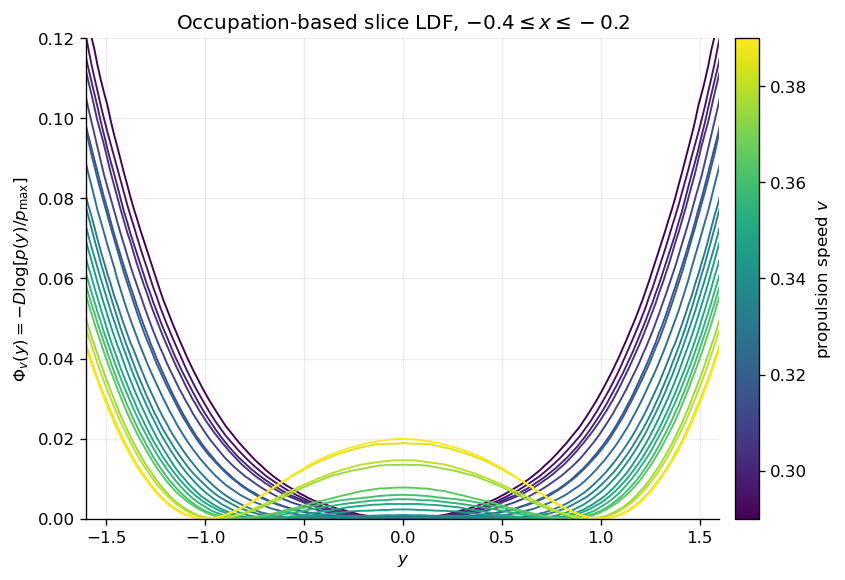

In [29]:
def symmetrize_on_grid(y: np.ndarray, density: np.ndarray) -> np.ndarray:
    order = np.argsort(y)
    y = y[order]
    d = density[order]
    # Interpolate the reflected density onto the same grid.
    reflected = np.interp(-y, y, d, left=np.nan, right=np.nan)
    out = d.copy()
    both = np.isfinite(d) & np.isfinite(reflected)
    out[both] = 0.5 * (d[both] + reflected[both])
    return out


def make_slice_profile(df: pd.DataFrame, x_min: float, x_max: float):
    work = df[
        (df["path_x_center"] >= x_min) &
        (df["path_x_center"] <= x_max)
    ].copy()

    if work.empty:
        return None

    grouped = (
        work.groupby("path_y_center", as_index=False)
        .agg(unbiased_count=("unbiased_count", "sum"),
             biased_count=("biased_count", "sum"))
        .sort_values("path_y_center")
    )

    y = grouped["path_y_center"].to_numpy(float)
    mass = np.clip(grouped["unbiased_count"].to_numpy(float), 0, None)
    if mass.sum() <= 0:
        return None

    widths = bin_widths_from_centers(y)
    density_raw = mass / (mass.sum() * widths)
    density = symmetrize_on_grid(y, density_raw) if SYMMETRIZE_LDF else density_raw.copy()

    peak = np.nanmax(density)
    valid = np.isfinite(density) & (density > peak * RELATIVE_DENSITY_CUTOFF)
    phi = np.full_like(density, np.nan)
    phi[valid] = -FIXED_D * np.log(density[valid] / peak)

    return pd.DataFrame({
        "y": y,
        "unbiased_count": mass,
        "biased_count": grouped["biased_count"].to_numpy(float),
        "density_raw": density_raw,
        "density_used": density,
        "phi": phi,
    })


SLICE_PROFILES = {}
for v, df in PATH_XY.items():
    prof = make_slice_profile(df, LDF_X_MIN, LDF_X_MAX)
    if prof is not None:
        SLICE_PROFILES[v] = prof

fig, ax = plt.subplots(figsize=(8.2, 5.2))
for v, prof in SLICE_PROFILES.items():
    ax.plot(prof["y"], prof["phi"], lw=1.15, color=speed_color(v))
ax.set(
    xlabel=r"$y$",
    ylabel=rf"$\Phi_v(y)=-D\log[p(y)/p_{{\max}}]$",
    title=rf"Occupation-based slice LDF, ${LDF_X_MIN:g}\leq x\leq {LDF_X_MAX:g}$",
)
ax.set_ylim(bottom=0, top=0.12)
ax.set_xlim(left=-1.6, right=1.6)
add_speed_colorbar(fig, ax)
finish_figure(fig, "11_slice_phi_across_speeds.png")

## 17. Quartic Landau fit

The fit convention is explicitly

$$
\Phi_v(y)=c_0(v)+c_2(v)y^2+c_4(v)y^4.
$$

With this convention, if \(c_4>0\) and \(c_2<0\), the nonzero minima satisfy

$$
y_*^2=-\frac{c_2}{2c_4}.
$$

The fit is restricted to \(|y|\leq 1.2\) by default.

In [21]:
def fit_even_quartic(profile: pd.DataFrame, y_max: float):
    y = profile["y"].to_numpy(float)
    phi = profile["phi"].to_numpy(float)
    good = np.isfinite(y) & np.isfinite(phi) & (np.abs(y) <= y_max)
    y = y[good]
    phi = phi[good]

    if len(y) < 5:
        return None

    X = np.column_stack([np.ones_like(y), y**2, y**4])
    beta, *_ = np.linalg.lstsq(X, phi, rcond=None)
    pred = X @ beta

    ss_res = np.sum((phi - pred)**2)
    ss_tot = np.sum((phi - np.mean(phi))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    c0, c2, c4 = beta
    ystar2 = -c2/(2*c4) if c4 > 0 and c2 < 0 else 0.0
    return {
        "c0": c0,
        "c2": c2,
        "c4": c4,
        "R2": r2,
        "y_star": math.sqrt(max(0.0, ystar2)),
        "n_fit": len(y),
    }


landau_rows = []
for v, prof in SLICE_PROFILES.items():
    fit = fit_even_quartic(prof, LANDAU_Y_MAX)
    if fit is not None:
        fit["v"] = v
        landau_rows.append(fit)

landau = pd.DataFrame(landau_rows).sort_values("v")
display(landau)

,c0,c2,c4,R2,y_star,n_fit,v
0,0.000100,0.019701,0.011438,0.999932,0.000000,121,0.290
1,-0.000015,0.016922,0.011329,0.999957,0.000000,121,0.295
2,0.000145,0.013885,0.012005,0.999866,0.000000,121,0.300
3,0.000012,0.012498,0.012166,0.999929,0.000000,121,0.305
4,0.000023,0.008678,0.012620,0.999905,0.000000,121,0.310
5,0.000071,0.003029,0.014461,0.999879,0.000000,121,0.315
6,-0.000020,0.003126,0.013937,0.999805,0.000000,121,0.320
7,0.000088,-0.000526,0.013782,0.999744,0.138151,121,0.325
8,0.000571,-0.005922,0.015541,0.998877,0.436490,121,0.330
9,0.000502,-0.005528,0.013117,0.997949,0.459044,121,0.335


Total quartic fits: 800


,v,x_min,x_max,x_center,y_max,c0,c2,c4,R2,y_star,n_fit
0,0.290,-0.75,-0.55,-0.65,0.6,0.001684,0.148556,-0.222730,0.985698,0.000000,73
1,0.295,-0.75,-0.55,-0.65,0.6,0.001654,0.148653,-0.227901,0.986920,0.000000,73
2,0.300,-0.75,-0.55,-0.65,0.6,0.001589,0.148829,-0.236057,0.985297,0.000000,73
3,0.305,-0.75,-0.55,-0.65,0.6,0.001749,0.156636,-0.254686,0.984053,0.000000,73
4,0.310,-0.75,-0.55,-0.65,0.6,0.001776,0.147819,-0.245355,0.981707,0.000000,73
...,...,...,...,...,...,...,...,...,...,...,...
795,0.365,0.00,0.20,0.10,1.4,0.006321,-0.021009,0.018845,0.997979,0.746592,169
796,0.375,0.00,0.20,0.10,1.4,0.011377,-0.030203,0.020873,0.996574,0.850584,169
797,0.380,0.00,0.20,0.10,1.4,0.012294,-0.031567,0.020991,0.996662,0.867127,169
798,0.385,0.00,0.20,0.10,1.4,0.015871,-0.036810,0.021834,0.996437,0.918134,169



v_c SENSITIVITY TABLE


,x_min,x_max,x_center,x_width,y_max,v_c,c4_at_vc,R2_at_vc,n_speeds,n_crossings
0,-0.75,-0.55,-0.65,0.2,0.6,NaN,NaN,NaN,20,0
1,-0.75,-0.55,-0.65,0.2,0.8,NaN,NaN,NaN,20,0
2,-0.75,-0.55,-0.65,0.2,1.0,NaN,NaN,NaN,20,0
3,-0.75,-0.55,-0.65,0.2,1.2,NaN,NaN,NaN,20,0
4,-0.75,-0.55,-0.65,0.2,1.4,0.384099,0.000675,0.041900,20,1
5,-0.50,-0.30,-0.40,0.2,0.6,0.329927,0.008600,0.844846,20,3
6,-0.50,-0.30,-0.40,0.2,0.8,0.329585,0.008968,0.982485,20,3
7,-0.50,-0.30,-0.40,0.2,1.0,0.328549,0.010852,0.997460,20,1
8,-0.50,-0.30,-0.40,0.2,1.2,0.327414,0.012055,0.999090,20,1
9,-0.50,-0.30,-0.40,0.2,1.4,0.326638,0.012601,0.999641,20,1



ROBUSTNESS SUMMARY
Valid fits          = 36
mean(v_c)           = 0.327075
median(v_c)         = 0.325334
std(v_c)            = 0.010210
min(v_c)            = 0.314581
max(v_c)            = 0.384099
full systematic span = 0.069518


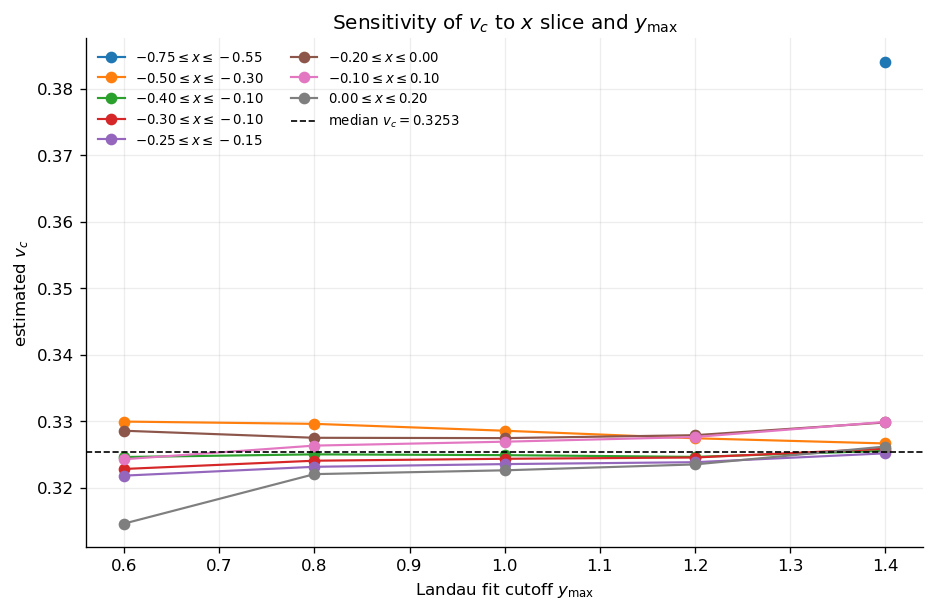

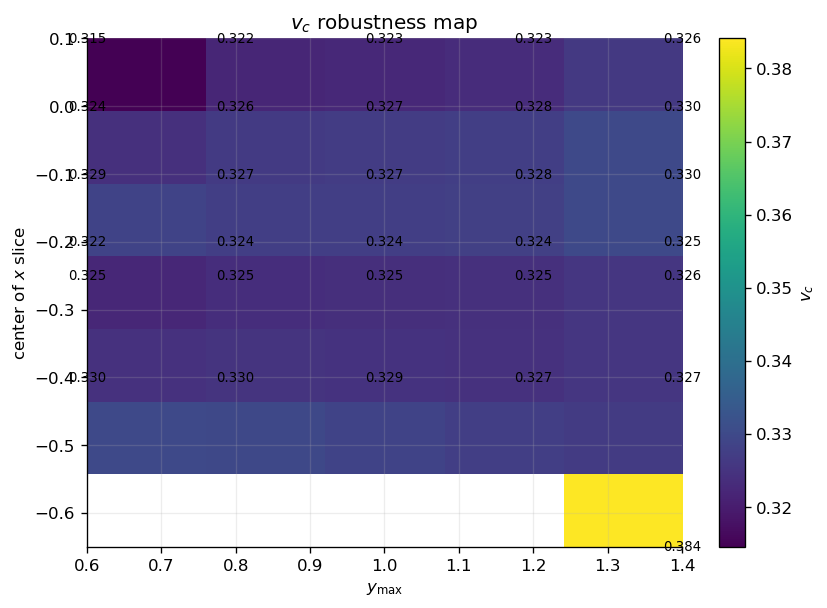

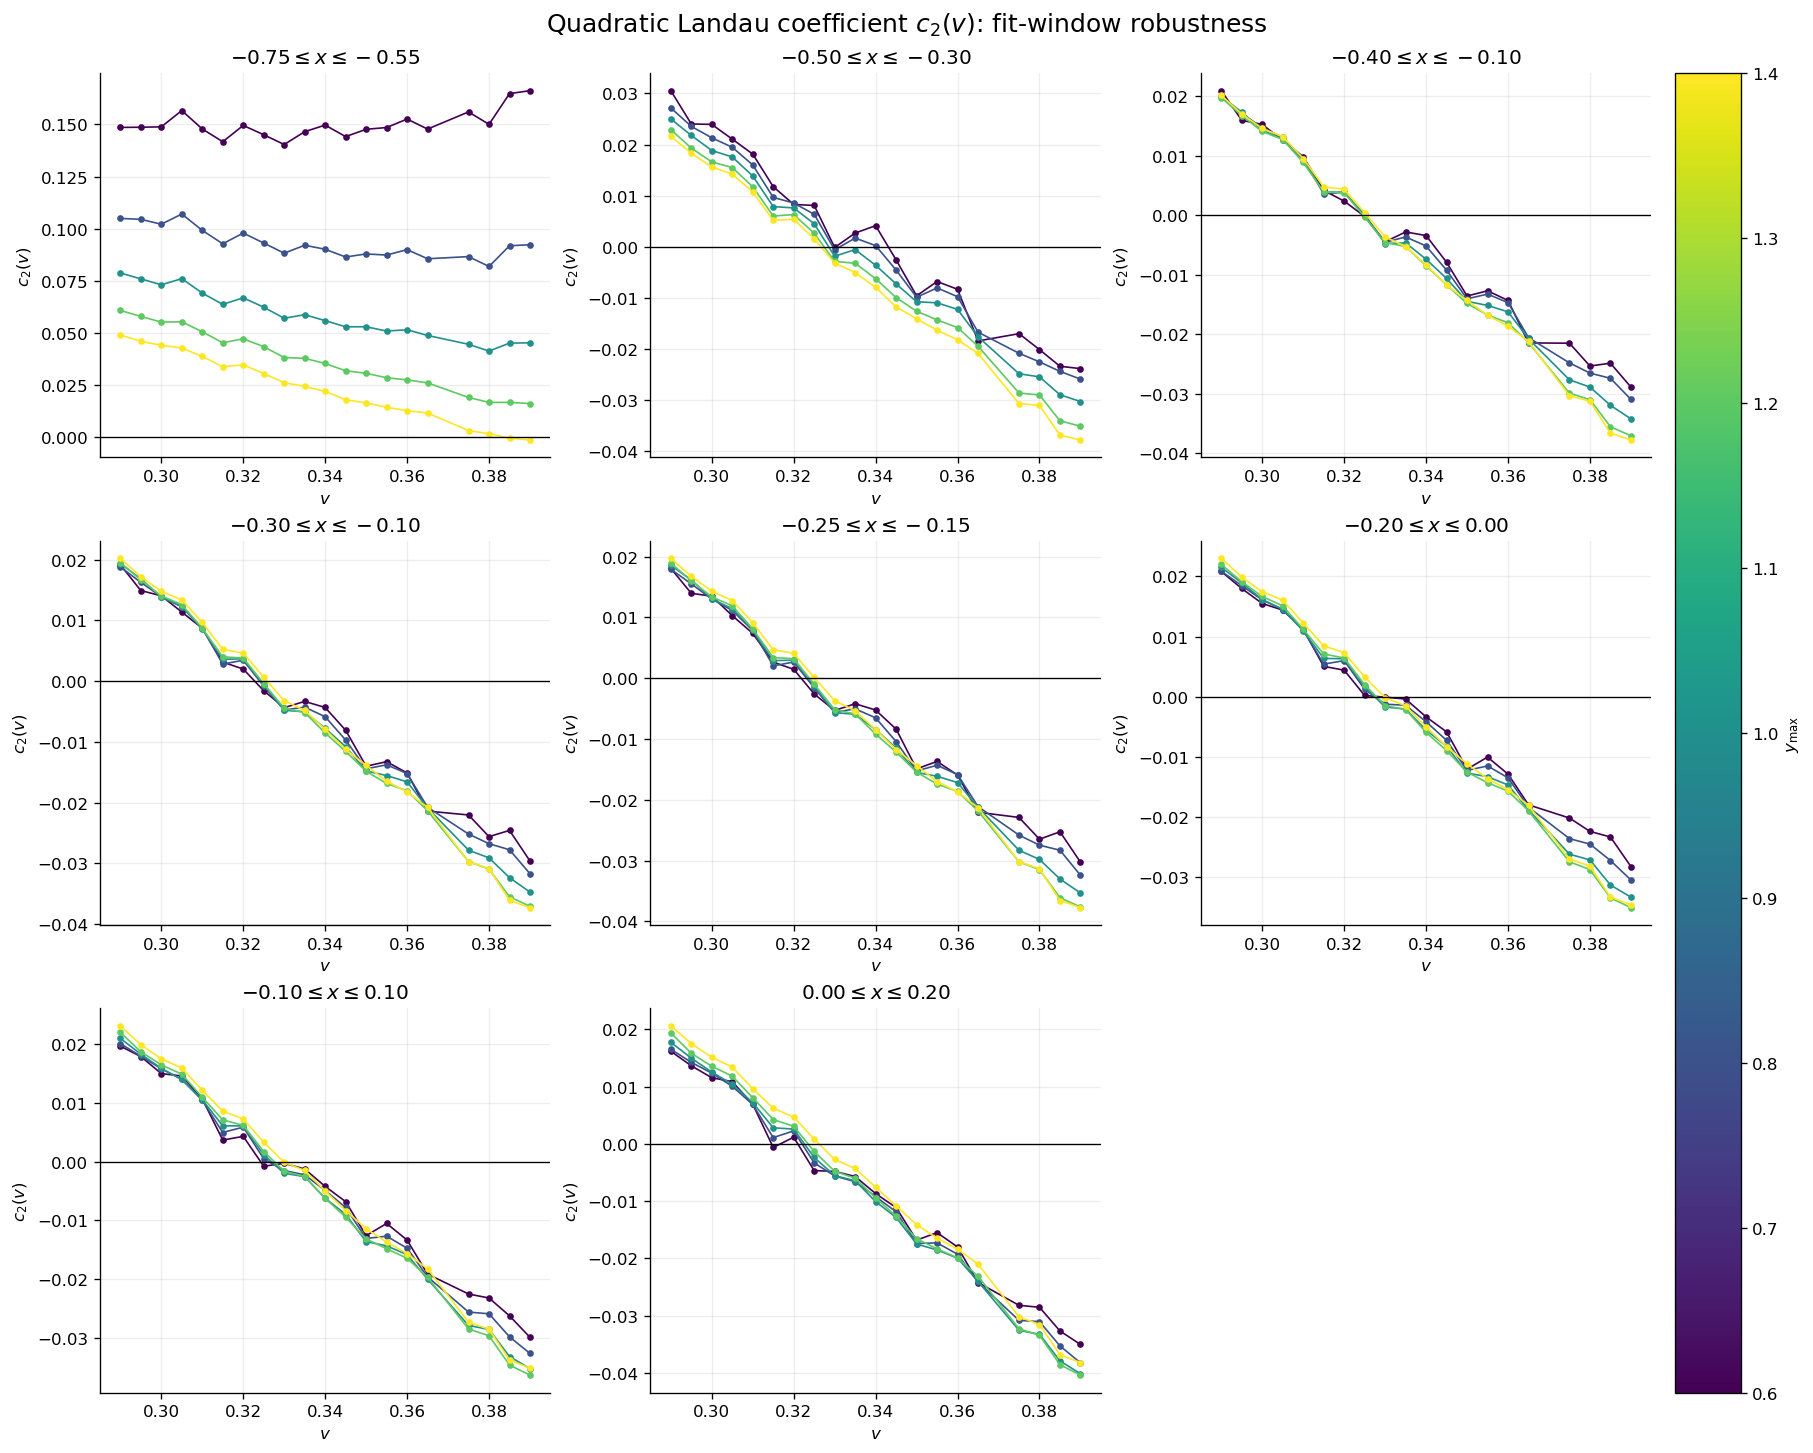

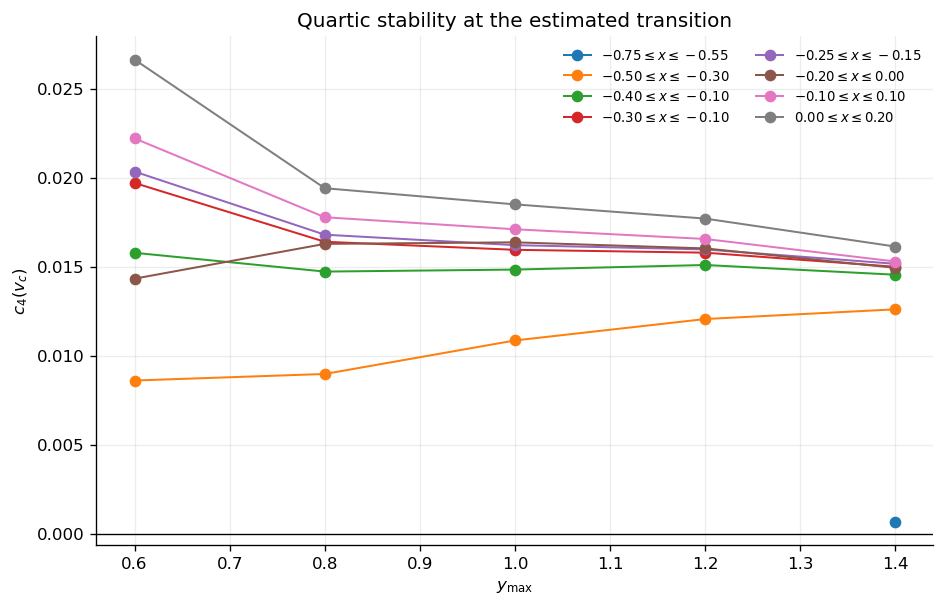


Saved sensitivity tables to: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987


In [22]:
# ============================================================
# LANDAU ROBUSTNESS / SENSITIVITY STUDY
#
# Vary:
#   1) x-slice used to construct p(y | x slice, x(T)>0.5)
#   2) maximum |y| included in quartic fit
#
# Fits:
#
#   Phi_v(y) = c0 + c2 y^2 + c4 y^4
#
# and extracts:
#
#   c2(v_c) = 0
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

D_LANDAU = FIXED_D   # 0.025

# Explicit x-windows.
#
X_SLICES = [
    (-0.75, -0.55),
    (-0.50, -0.30),
    (-0.40, -0.10),
    (-0.30, -0.10),
    (-0.25, -0.15),
    (-0.20,  0.00),
    (-0.10,  0.10),
    ( 0.00,  0.20),
]

# Different |y| fitting windows
Y_MAX_VALUES = [
    0.60,
    0.80,
    1.00,
    1.20,
    1.40,
]

# Symmetrize p(y) before constructing Phi.
SYMMETRIZE = True

# Ignore extremely small histogram density before log
RELATIVE_DENSITY_CUTOFF = 1e-12

# Minimum number of points required for quartic fit
MIN_FIT_POINTS = 7

# Optional quality filter.
# Set to None to keep every fit.
MIN_R2 = None 

SAVE_FIGURES = False


# ============================================================
# HELPER: bin widths
# ============================================================

def get_bin_widths(y):

    y = np.asarray(y, float)

    if len(y) < 2:
        return np.ones_like(y)

    mids = 0.5 * (
        y[:-1] + y[1:]
    )

    edges = np.r_[
        y[0] - (mids[0] - y[0]),
        mids,
        y[-1] + (y[-1] - mids[-1]),
    ]

    return np.diff(edges)


# ============================================================
# HELPER: y -> -y symmetrization
# ============================================================

def symmetrize_density(y, density):

    y = np.asarray(y, float)
    density = np.asarray(density, float)

    reflected = np.interp(
        -y,
        y,
        density,
        left=np.nan,
        right=np.nan,
    )

    out = density.copy()

    good = (
        np.isfinite(density)
        &
        np.isfinite(reflected)
    )

    out[good] = 0.5 * (
        density[good]
        +
        reflected[good]
    )

    return out


# ============================================================
# CONSTRUCT Phi(y) FOR A GIVEN x-SLICE
# ============================================================

def make_phi_for_x_slice(
    df,
    x_min,
    x_max,
    D,
    symmetrize=True,
):

    cut = df[
        (df["path_x_center"] >= x_min)
        &
        (df["path_x_center"] <= x_max)
    ].copy()

    if cut.empty:
        return None

    # Integrate all x bins in the slice.
    prof = (
        cut.groupby(
            "path_y_center",
            as_index=False,
        )
        .agg(
            unbiased_count=(
                "unbiased_count",
                "sum",
            )
        )
        .sort_values(
            "path_y_center"
        )
    )

    y = prof[
        "path_y_center"
    ].to_numpy(float)

    counts = prof[
        "unbiased_count"
    ].to_numpy(float)

    good = (
        np.isfinite(y)
        &
        np.isfinite(counts)
    )

    y = y[good]
    counts = counts[good]

    counts = np.clip(
        counts,
        0,
        None,
    )

    if counts.sum() <= 0:
        return None

    dy = get_bin_widths(y)

    density = (
        counts
        /
        (counts.sum() * dy)
    )

    if symmetrize:
        density = symmetrize_density(
            y,
            density,
        )

    peak = np.nanmax(density)

    if (
        not np.isfinite(peak)
        or peak <= 0
    ):
        return None

    valid = (
        np.isfinite(density)
        &
        (
            density
            >
            peak
            * RELATIVE_DENSITY_CUTOFF
        )
    )

    phi = np.full_like(
        density,
        np.nan,
    )

    phi[valid] = (
        -D
        * np.log(
            density[valid] / peak
        )
    )

    return pd.DataFrame({
        "y": y,
        "density": density,
        "phi": phi,
    })


# ============================================================
# QUARTIC LANDAU FIT
#
# Phi = c0 + c2 y^2 + c4 y^4
# ============================================================

def fit_quartic_landau(
    profile,
    y_max,
):

    y = profile[
        "y"
    ].to_numpy(float)

    phi = profile[
        "phi"
    ].to_numpy(float)

    good = (
        np.isfinite(y)
        &
        np.isfinite(phi)
        &
        (np.abs(y) <= y_max)
    )

    y = y[good]
    phi = phi[good]

    if len(y) < MIN_FIT_POINTS:
        return None

    X = np.column_stack([
        np.ones_like(y),
        y**2,
        y**4,
    ])

    beta, *_ = np.linalg.lstsq(
        X,
        phi,
        rcond=None,
    )

    c0, c2, c4 = beta

    pred = X @ beta

    ss_res = np.sum(
        (phi - pred)**2
    )

    ss_tot = np.sum(
        (phi - np.mean(phi))**2
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    # For:
    #
    # Phi = c0 + c2 y² + c4 y⁴
    #
    # nonzero stationary minima:
    #
    # y_*² = -c2 / (2 c4)
    #
    if c4 > 0 and c2 < 0:

        y_star = np.sqrt(
            -c2 / (2 * c4)
        )

    else:

        y_star = 0.0

    return {
        "c0": c0,
        "c2": c2,
        "c4": c4,
        "R2": r2,
        "y_star": y_star,
        "n_fit": len(y),
    }


# ============================================================
# ZERO CROSSING OF c2(v)
# ============================================================

def adjacent_zero_crossing(
    x,
    y,
):

    x = np.asarray(x, float)
    y = np.asarray(y, float)

    order = np.argsort(x)

    x = x[order]
    y = y[order]

    good = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[good]
    y = y[good]

    hits = []

    for i in range(
        len(x) - 1
    ):

        if y[i] == 0:

            hits.append(
                x[i]
            )

        elif (
            y[i]
            * y[i + 1]
            < 0
        ):

            xc = (
                x[i]
                -
                y[i]
                * (
                    x[i + 1]
                    - x[i]
                )
                /
                (
                    y[i + 1]
                    - y[i]
                )
            )

            hits.append(
                xc
            )

    return hits


# ============================================================
# RUN ALL COMBINATIONS
# ============================================================

fit_rows = []


for x_min, x_max in X_SLICES:

    x_center = 0.5 * (
        x_min + x_max
    )

    for v in sorted(PATH_XY):

        profile = make_phi_for_x_slice(
            PATH_XY[v],
            x_min=x_min,
            x_max=x_max,
            D=D_LANDAU,
            symmetrize=SYMMETRIZE,
        )

        if profile is None:
            continue

        for y_max in Y_MAX_VALUES:

            fit = fit_quartic_landau(
                profile,
                y_max,
            )

            if fit is None:
                continue

            fit_rows.append({
                "v": v,

                "x_min": x_min,
                "x_max": x_max,
                "x_center": x_center,

                "y_max": y_max,

                **fit,
            })


landau_sensitivity = (
    pd.DataFrame(fit_rows)
    .sort_values([
        "x_center",
        "y_max",
        "v",
    ])
    .reset_index(drop=True)
)


print(
    "Total quartic fits:",
    len(landau_sensitivity),
)

display(
    landau_sensitivity
)


# ============================================================
# ESTIMATE vc FOR EACH (x-slice, y_max)
# ============================================================

vc_rows = []


for (
    x_min,
    x_max,
    y_max
), g in landau_sensitivity.groupby(
    [
        "x_min",
        "x_max",
        "y_max",
    ]
):

    g = g.sort_values("v")

    # Optional quality cut
    if MIN_R2 is not None:

        guse = g[
            g["R2"] >= MIN_R2
        ].copy()

    else:

        guse = g.copy()


    candidates = adjacent_zero_crossing(
        guse["v"],
        guse["c2"],
    )


    vc = (
        candidates[0]
        if len(candidates) > 0
        else np.nan
    )


    # Interpolate c4 and R2 close to vc
    if (
        np.isfinite(vc)
        and len(guse) >= 2
    ):

        c4_at_vc = np.interp(
            vc,
            guse["v"],
            guse["c4"],
        )

        r2_at_vc = np.interp(
            vc,
            guse["v"],
            guse["R2"],
        )

    else:

        c4_at_vc = np.nan
        r2_at_vc = np.nan


    vc_rows.append({

        "x_min": x_min,
        "x_max": x_max,

        "x_center": 0.5 * (
            x_min + x_max
        ),

        "x_width": (
            x_max - x_min
        ),

        "y_max": y_max,

        "v_c": vc,

        "c4_at_vc": c4_at_vc,

        "R2_at_vc": r2_at_vc,

        "n_speeds": len(guse),

        "n_crossings": len(candidates),
    })


vc_table = (
    pd.DataFrame(vc_rows)
    .sort_values([
        "x_center",
        "y_max",
    ])
    .reset_index(drop=True)
)


print()
print(
    "================================================"
)
print(
    "v_c SENSITIVITY TABLE"
)
print(
    "================================================"
)

display(
    vc_table
)


# ============================================================
# SUMMARY OF vc SPREAD
# ============================================================

valid_vc = vc_table[
    np.isfinite(
        vc_table["v_c"]
    )
].copy()


if not valid_vc.empty:

    vc_mean = (
        valid_vc["v_c"]
        .mean()
    )

    vc_median = (
        valid_vc["v_c"]
        .median()
    )

    vc_std = (
        valid_vc["v_c"]
        .std()
    )

    vc_min = (
        valid_vc["v_c"]
        .min()
    )

    vc_max = (
        valid_vc["v_c"]
        .max()
    )


    print()
    print(
        "================================================"
    )

    print(
        "ROBUSTNESS SUMMARY"
    )

    print(
        "================================================"
    )

    print(
        f"Valid fits          = {len(valid_vc)}"
    )

    print(
        f"mean(v_c)           = {vc_mean:.6f}"
    )

    print(
        f"median(v_c)         = {vc_median:.6f}"
    )

    print(
        f"std(v_c)            = {vc_std:.6f}"
    )

    print(
        f"min(v_c)            = {vc_min:.6f}"
    )

    print(
        f"max(v_c)            = {vc_max:.6f}"
    )

    print(
        f"full systematic span = "
        f"{vc_max - vc_min:.6f}"
    )

else:

    print(
        "No valid c2 zero crossings "
        "were found."
    )


# ============================================================
# FIGURE 1:
# vc versus y_max for every x-slice
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


for (
    x_min,
    x_max
), g in vc_table.groupby(
    [
        "x_min",
        "x_max",
    ]
):

    g = g.sort_values(
        "y_max"
    )

    label = (
        rf"${x_min:.2f}"
        rf"\leq x\leq"
        rf"{x_max:.2f}$"
    )

    ax.plot(
        g["y_max"],
        g["v_c"],
        "o-",
        lw=1.3,
        label=label,
    )


if (
    not valid_vc.empty
):

    ax.axhline(
        vc_median,
        color="black",
        ls="--",
        lw=1.0,
        label=(
            rf"median $v_c="
            rf"{vc_median:.4f}$"
        ),
    )


ax.set(
    xlabel=r"Landau fit cutoff $y_{\max}$",
    ylabel=r"estimated $v_c$",
    title=(
        r"Sensitivity of $v_c$ "
        r"to $x$ slice and $y_{\max}$"
    ),
)

ax.legend(
    fontsize=8,
    ncol=2,
)

finish_figure(
    fig,
    "landau_vc_sensitivity_ymax_xslice.png",
)


# ============================================================
# FIGURE 2:
# HEATMAP vc(x-slice, y_max)
# ============================================================

vc_pivot = (
    vc_table
    .pivot_table(
        index="x_center",
        columns="y_max",
        values="v_c",
        aggfunc="mean",
    )
    .sort_index()
    .sort_index(axis=1)
)


fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


im = ax.imshow(
    vc_pivot.to_numpy(float),
    aspect="auto",
    origin="lower",
    extent=[
        vc_pivot.columns.min(),
        vc_pivot.columns.max(),
        vc_pivot.index.min(),
        vc_pivot.index.max(),
    ],
)


fig.colorbar(
    im,
    ax=ax,
    label=r"$v_c$",
)


# Write numerical vc in each cell
for iy, xc in enumerate(
    vc_pivot.index
):

    for ix, ym in enumerate(
        vc_pivot.columns
    ):

        value = (
            vc_pivot
            .loc[xc, ym]
        )

        if np.isfinite(value):

            ax.text(
                ym,
                xc,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )


ax.set(
    xlabel=r"$y_{\max}$",
    ylabel=r"center of $x$ slice",
    title=r"$v_c$ robustness map",
)


finish_figure(
    fig,
    "landau_vc_robustness_heatmap.png",
)


# ============================================================
# FIGURE 3:
# c2(v) FOR EACH x-SLICE
#
# Different colors = y_max
# ============================================================

n_slices = len(
    X_SLICES
)

ncols = 3

nrows = int(
    np.ceil(
        n_slices / ncols
    )
)


fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
        5.0 * ncols,
        4.0 * nrows,
    ),
    constrained_layout=True,
)

axes = np.atleast_1d(
    axes
).ravel()


ymax_norm = plt.Normalize(
    min(Y_MAX_VALUES),
    max(Y_MAX_VALUES),
)

ymax_cmap = plt.get_cmap(
    "viridis"
)


for iax, (
    x_min,
    x_max
) in enumerate(
    X_SLICES
):

    ax = axes[iax]


    for y_max in Y_MAX_VALUES:

        g = landau_sensitivity[
            np.isclose(
                landau_sensitivity["x_min"],
                x_min,
            )
            &
            np.isclose(
                landau_sensitivity["x_max"],
                x_max,
            )
            &
            np.isclose(
                landau_sensitivity["y_max"],
                y_max,
            )
        ].sort_values(
            "v"
        )


        if g.empty:
            continue


        ax.plot(
            g["v"],
            g["c2"],
            "o-",
            ms=3,
            lw=1.0,
            color=ymax_cmap(
                ymax_norm(
                    y_max
                )
            ),
        )


    ax.axhline(
        0,
        color="black",
        lw=0.8,
    )


    ax.set_title(
        rf"${x_min:.2f}"
        rf"\leq x\leq"
        rf"{x_max:.2f}$"
    )

    ax.set_xlabel(
        r"$v$"
    )

    ax.set_ylabel(
        r"$c_2(v)$"
    )


# hide unused axes
for j in range(
    n_slices,
    len(axes),
):

    axes[j].axis(
        "off"
    )


sm = plt.cm.ScalarMappable(
    norm=ymax_norm,
    cmap=ymax_cmap,
)

sm.set_array([])


fig.colorbar(
    sm,
    ax=axes.tolist(),
    label=r"$y_{\max}$",
    pad=0.015,
)


fig.suptitle(
    r"Quadratic Landau coefficient "
    r"$c_2(v)$: fit-window robustness",
    fontsize=15,
)


finish_figure(
    fig,
    "landau_c2_all_xslices_ymax.png",
)


# ============================================================
# FIGURE 4:
# c4 at the inferred transition
#
# Important diagnostic:
# for a conventional continuous quartic Landau transition
# we want c4 > 0 around vc.
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


for (
    x_min,
    x_max
), g in vc_table.groupby(
    [
        "x_min",
        "x_max",
    ]
):

    g = g.sort_values(
        "y_max"
    )

    ax.plot(
        g["y_max"],
        g["c4_at_vc"],
        "o-",
        lw=1.2,
        label=(
            rf"${x_min:.2f}"
            rf"\leq x\leq"
            rf"{x_max:.2f}$"
        ),
    )


ax.axhline(
    0,
    color="black",
    lw=0.8,
)


ax.set(
    xlabel=r"$y_{\max}$",
    ylabel=r"$c_4(v_c)$",
    title=(
        r"Quartic stability at the "
        r"estimated transition"
    ),
)


ax.legend(
    fontsize=8,
    ncol=2,
)


finish_figure(
    fig,
    "landau_c4_at_vc_sensitivity.png",
)


# ============================================================
# SAVE TABLES
# ============================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


landau_sensitivity.to_csv(
    OUTPUT_DIR
    / "landau_sensitivity_all_fits.csv",
    index=False,
)


vc_table.to_csv(
    OUTPUT_DIR
    / "landau_vc_sensitivity.csv",
    index=False,
)


print()
print(
    "Saved sensitivity tables to:",
    OUTPUT_DIR,
)

## 18. Inspect fitted profiles at selected velocities

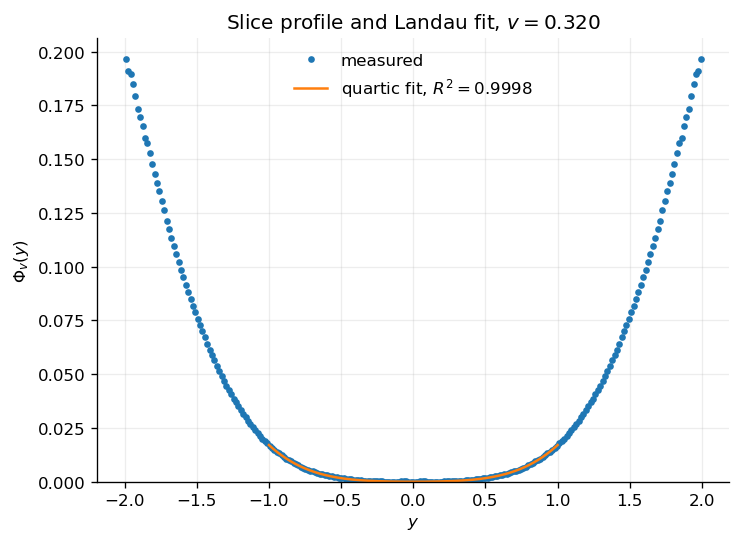

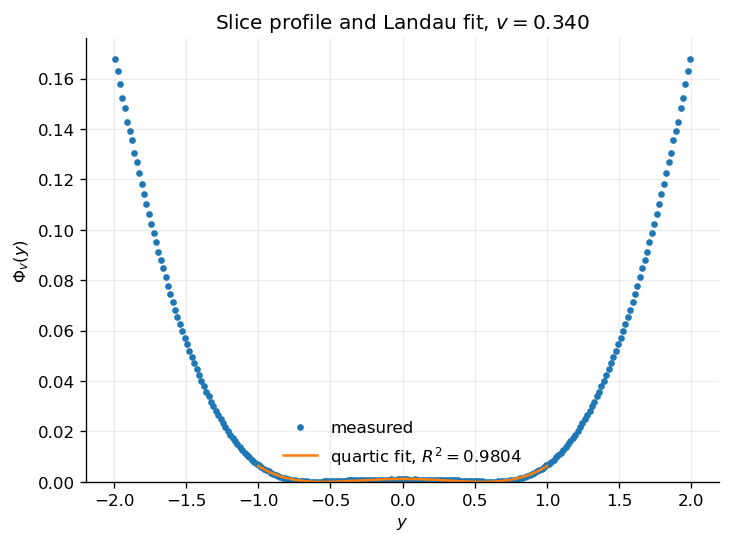

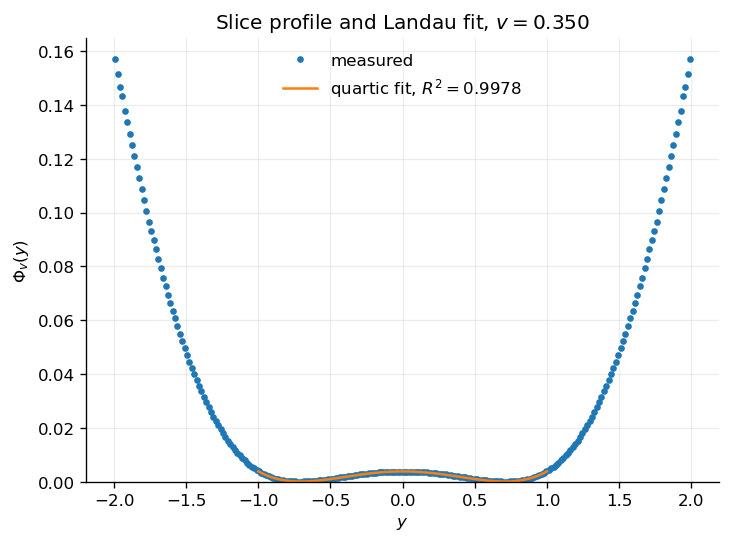

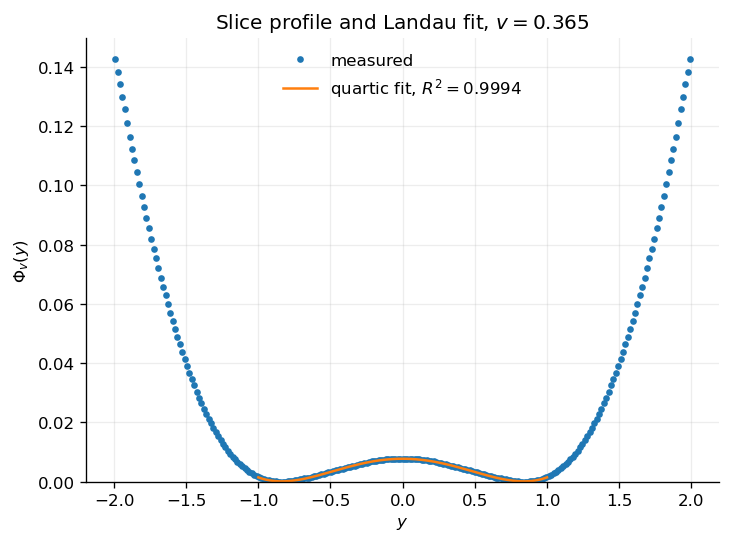

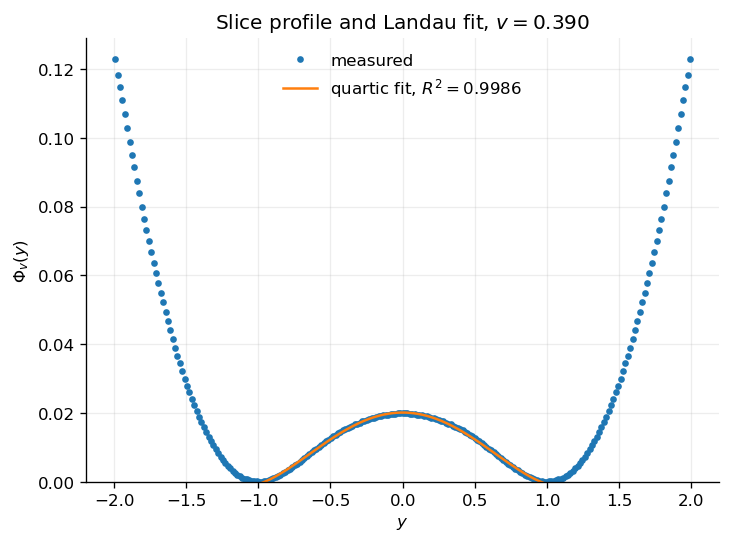

In [23]:
inspect_speeds = []
for target in REPRESENTATIVE_SPEEDS:
    if SLICE_PROFILES:
        vv = nearest_available_speed(target, SLICE_PROFILES.keys())
        if vv not in inspect_speeds:
            inspect_speeds.append(vv)

for v in inspect_speeds:
    prof = SLICE_PROFILES[v]
    fitrow = landau[np.isclose(landau["v"], v)]
    fig, ax = plt.subplots(figsize=(6.8, 4.8))
    ax.plot(prof["y"], prof["phi"], "o", ms=3, label="measured")

    if not fitrow.empty:
        r = fitrow.iloc[0]
        yy = np.linspace(-LANDAU_Y_MAX, LANDAU_Y_MAX, 400)
        ff = r["c0"] + r["c2"]*yy**2 + r["c4"]*yy**4
        ax.plot(yy, ff, "-", lw=1.5, label=rf"quartic fit, $R^2={r['R2']:.4f}$")

    ax.set(
        xlabel=r"$y$",
        ylabel=r"$\Phi_v(y)$",
        title=rf"Slice profile and Landau fit, $v={v:.3f}$",
    )
    ax.set_ylim(bottom=0)
    ax.legend()
    finish_figure(fig, f"13_landau_fit_v{v:.3f}.png".replace(".", "p"))

Requested left speed  = 0.290 -> using v = 0.290
Requested right speed = 0.390 -> using v = 0.390
Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/path_ldf_comparison_speeds.png


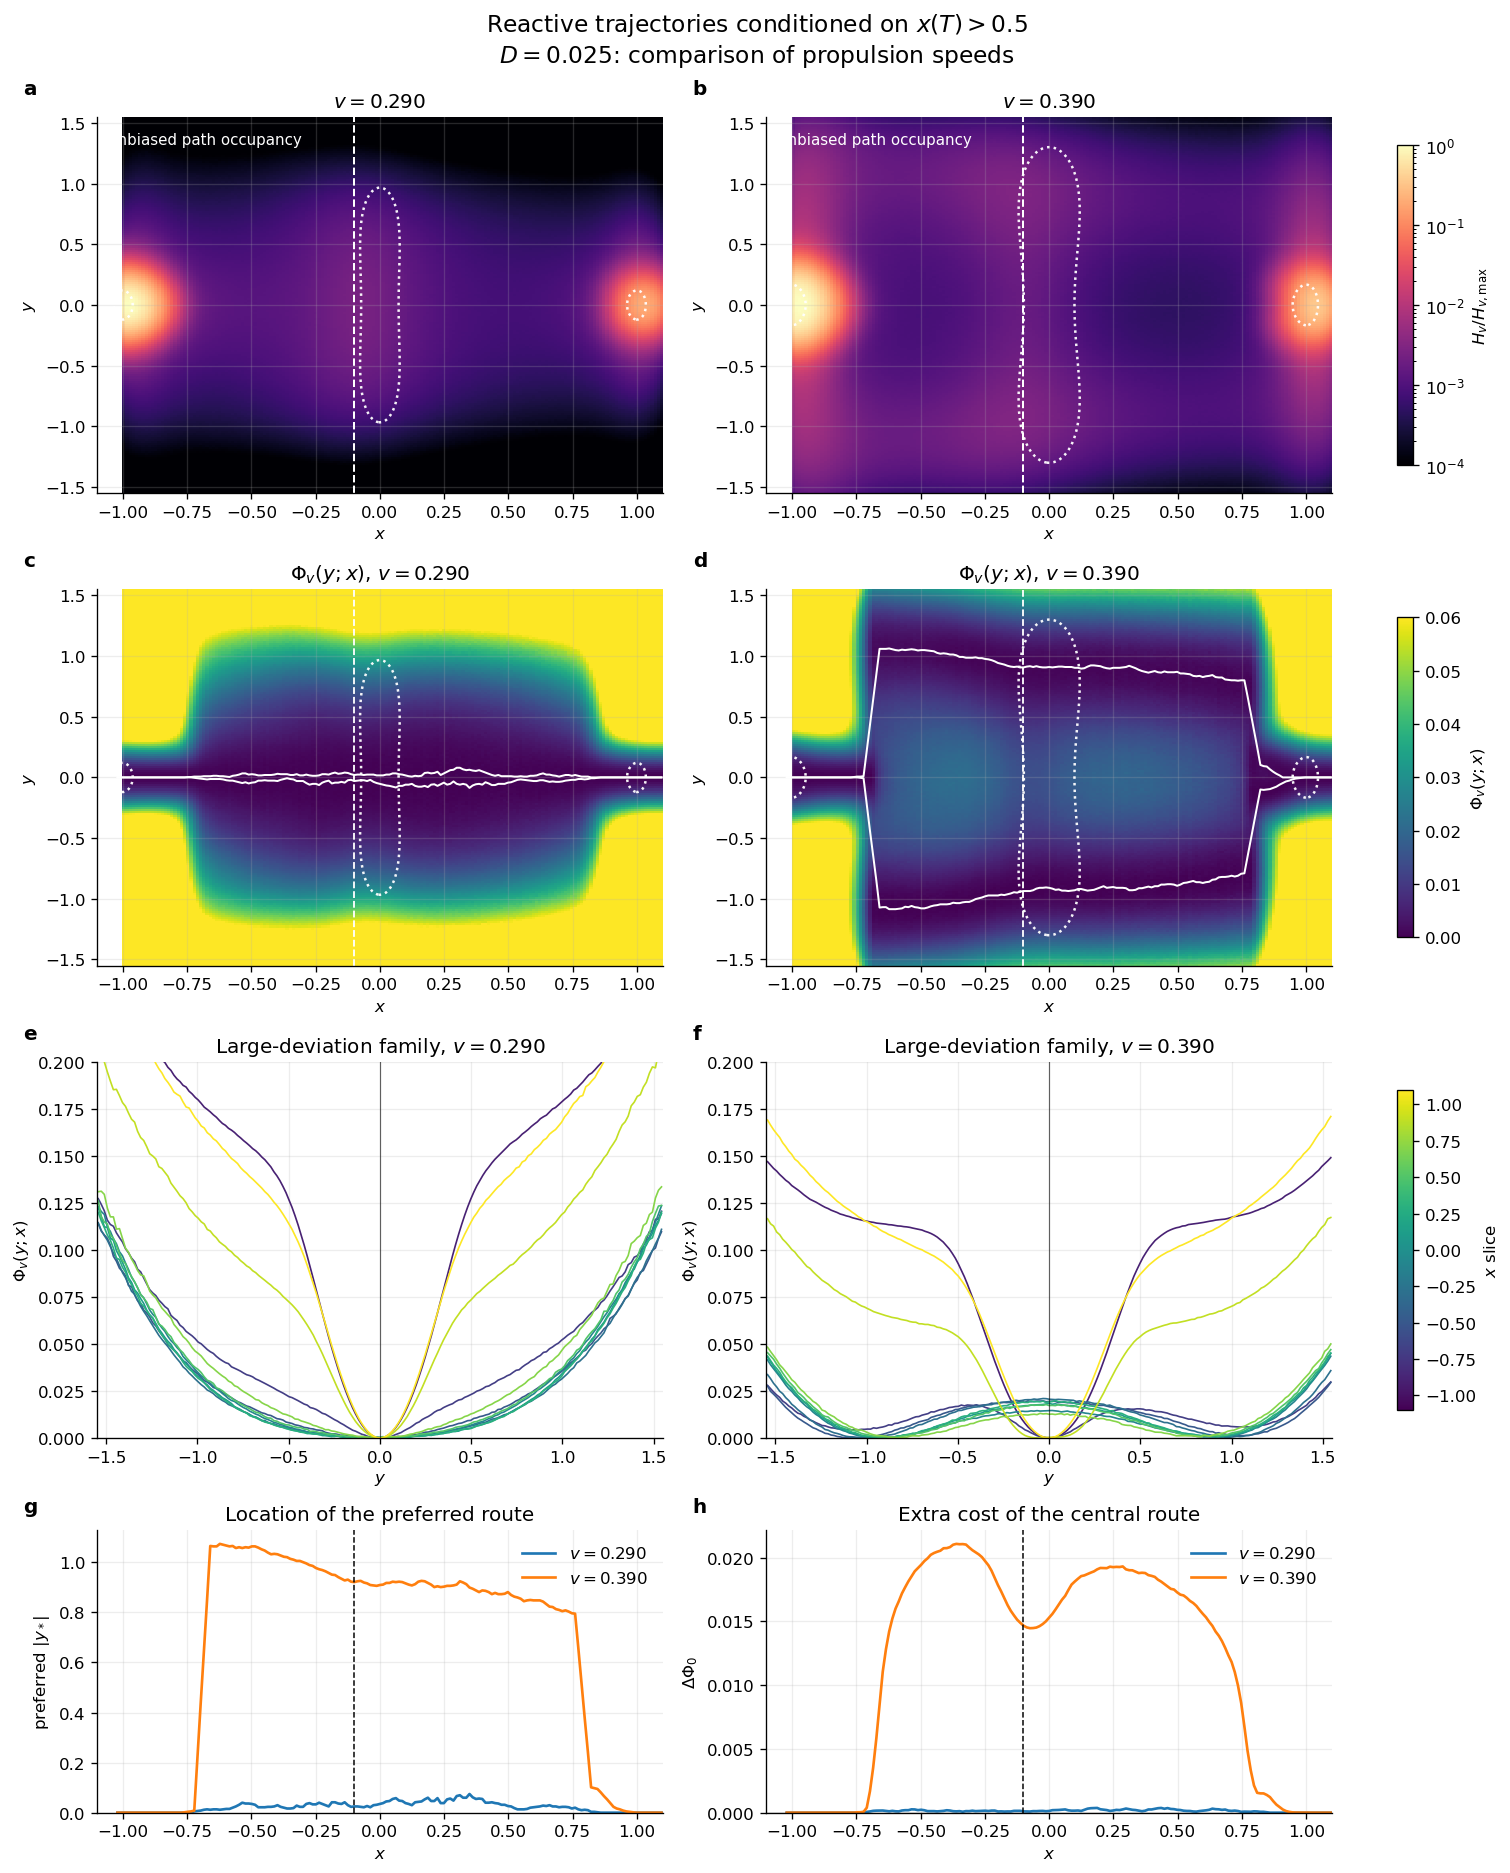

In [24]:
# ============================================================
# PATH-LDF FIGURE: compare TWO PROPULSION SPEEDS
# Fixed D, conditioned on x(T) > 0.5
#
# Requires PATH_XY dictionary from the previous notebook cells:
#
#     PATH_XY[v] = dataframe from
#     endpoint_x_gt_0p5_filtered_path_x_y_long.csv
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


# ============================================================
# CONFIGURATION
# ============================================================

SPEED_LEFT  = 0.29
SPEED_RIGHT = 0.39

D_LDF = FIXED_D       # 0.025

# Plot region
X_MIN = -1.10
X_MAX =  1.10

Y_MIN = -1.55
Y_MAX =  1.55

# Maximum value shown in Phi colormap
PHI_MAX = 0.06

# Maximum Phi shown in the slice-family panels
PHI_SLICE_MAX = 0.20

# How many x-slices to draw in panels e/f
N_X_SLICES = 12

# Relative-density cutoff before taking log
RELATIVE_CUTOFF = 1e-10

# Smooth the extracted preferred route in x.
# Set = 1 for no smoothing.
ROUTE_SMOOTH_WINDOW = 5

# Dashed vertical reference line
X_REFERENCE = -0.10

SAVE_FIGURE = True
FIGURE_NAME = "path_ldf_comparison_speeds.png"


# ============================================================
# FORCE-BALANCE REFERENCE CONTOURS
#
# Draw the three disconnected components of
#
#       |grad V(x,y)| = v
#
# associated with the left basin, saddle region, and right basin.
# ============================================================

SHOW_FORCE_BALANCE_CONTOURS = True

K_POTENTIAL = 0.3
LAMBDA_POTENTIAL = 2.5

# Use a somewhat larger x-domain internally so that the basin loops
# are computed completely even when the displayed path range is tighter.
FORCE_X_MIN = min(X_MIN, -1.35)
FORCE_X_MAX = max(X_MAX,  1.35)
FORCE_Y_MIN = Y_MIN
FORCE_Y_MAX = Y_MAX

FORCE_CONTOUR_NX = 700
FORCE_CONTOUR_NY = 700

# Keep the three force-balance components visually distinct from
# the solid preferred-route curves.
FORCE_CONTOUR_COLOR = "white"
FORCE_CONTOUR_LINEWIDTH = 1.5
FORCE_CONTOUR_ALPHA = 0.95



# ============================================================
# ABP POTENTIAL GRADIENT
#
# g(x) = (x^2 - 1)^2
# F(y) = 1 + k y^2 / 2
# H(y) = lambda y^2 / 2
# f_mix = F H / (F + H)
# V(x,y) = g(x) [F(y) - f_mix(y)] + f_mix(y)
# ============================================================

def grad_abp_potential(x, y, k=K_POTENTIAL, lam=LAMBDA_POTENTIAL):
    """Return dV/dx and dV/dy on scalar values or NumPy arrays."""

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    g = (x**2 - 1.0)**2
    dg_dx = 4.0 * x * (x**2 - 1.0)

    F = 1.0 + 0.5 * k * y**2
    H = 0.5 * lam * y**2

    dF_dy = k * y
    dH_dy = lam * y

    denom = F + H
    f_mix = F * H / denom

    # Exact derivative of F*H/(F+H):
    #
    # f_mix' = [F' H^2 + F^2 H'] / (F+H)^2
    #
    df_mix_dy = (
        dF_dy * H**2
        + F**2 * dH_dy
    ) / denom**2

    dV_dx = dg_dx * (F - f_mix)

    dV_dy = (
        g * dF_dy
        + (1.0 - g) * df_mix_dy
    )

    return dV_dx, dV_dy


def gradV_magnitude(x, y):
    """Return |grad V|."""
    dV_dx, dV_dy = grad_abp_potential(x, y)
    return np.hypot(dV_dx, dV_dy)


def add_force_balance_contours(
    ax,
    v,
    *,
    color=FORCE_CONTOUR_COLOR,
    linewidth=FORCE_CONTOUR_LINEWIDTH,
    alpha=FORCE_CONTOUR_ALPHA,
):
    """
    Overlay all disconnected components of

        |grad V(x,y)| = v

    on an existing x-y axis.

    For the present potential and v=0.32--0.39 there are three components:
      - loop around the left basin,
      - elongated component around the central saddle channel,
      - loop around the right basin.

    They are all drawn dotted because they represent the same
    force-balance criterion, not three different physical equations.
    """

    x_force = np.linspace(
        FORCE_X_MIN,
        FORCE_X_MAX,
        FORCE_CONTOUR_NX,
    )

    y_force = np.linspace(
        FORCE_Y_MIN,
        FORCE_Y_MAX,
        FORCE_CONTOUR_NY,
    )

    XX, YY = np.meshgrid(
        x_force,
        y_force,
    )

    force = gradV_magnitude(
        XX,
        YY,
    )

    cs = ax.contour(
        XX,
        YY,
        force,
        levels=[float(v)],
        colors=[color],
        linestyles=":",
        linewidths=linewidth,
        alpha=alpha,
        zorder=8,
    )

    return cs


# ============================================================
# FIND NEAREST ACTUAL SPEED
# ============================================================

def nearest_speed(target, available):
    available = np.asarray(sorted(available), dtype=float)
    return float(available[np.argmin(np.abs(available - target))])


v_left = nearest_speed(SPEED_LEFT, PATH_XY.keys())
v_right = nearest_speed(SPEED_RIGHT, PATH_XY.keys())

print(f"Requested left speed  = {SPEED_LEFT:.3f} -> using v = {v_left:.3f}")
print(f"Requested right speed = {SPEED_RIGHT:.3f} -> using v = {v_right:.3f}")


# ============================================================
# BUILD REGULAR H(x,y) GRID
# ============================================================

def build_path_grid(df, count_column="unbiased_count"):

    work = df.copy()

    work["path_x_center"] = pd.to_numeric(
        work["path_x_center"],
        errors="coerce"
    )

    work["path_y_center"] = pd.to_numeric(
        work["path_y_center"],
        errors="coerce"
    )

    work[count_column] = pd.to_numeric(
        work[count_column],
        errors="coerce"
    )

    work = work.dropna(
        subset=[
            "path_x_center",
            "path_y_center",
            count_column
        ]
    )

    # Limit plotting region
    work = work[
        (work["path_x_center"] >= X_MIN) &
        (work["path_x_center"] <= X_MAX) &
        (work["path_y_center"] >= Y_MIN) &
        (work["path_y_center"] <= Y_MAX)
    ]

    pivot = work.pivot_table(
        index="path_y_center",
        columns="path_x_center",
        values=count_column,
        aggfunc="sum",
        fill_value=0.0,
    )

    pivot = pivot.sort_index().sort_index(axis=1)

    x = pivot.columns.to_numpy(float)
    y = pivot.index.to_numpy(float)

    H = pivot.to_numpy(float)

    H = np.clip(H, 0.0, None)

    return x, y, H


# ============================================================
# COMPUTE LOCAL LDF
#
# Phi(y;x) = -D log[
#                  H(x,y)
#                  ----------------
#                  max_y H(x,y)
#                ]
#
# Therefore min_y Phi(y;x) = 0 for each x.
# ============================================================

def occupation_to_phi(H, D):

    Phi = np.full_like(H, np.nan, dtype=float)

    for ix in range(H.shape[1]):

        col = H[:, ix]

        hmax = np.nanmax(col)

        if not np.isfinite(hmax) or hmax <= 0:
            continue

        threshold = hmax * RELATIVE_CUTOFF

        good = (
            np.isfinite(col) &
            (col > threshold)
        )

        Phi[good, ix] = (
            -D * np.log(col[good] / hmax)
        )

    return Phi


# ============================================================
# EXTRACT PREFERRED ROUTE
#
# For each x:
#   y_+(x) = minimum of Phi on y >= 0
#   y_-(x) = minimum of Phi on y <= 0
#
# Preferred |y_*| is their symmetric average.
# ============================================================

def preferred_routes(y, Phi):

    nx = Phi.shape[1]

    y_plus = np.full(nx, np.nan)
    y_minus = np.full(nx, np.nan)

    pos = y >= 0
    neg = y <= 0

    for ix in range(nx):

        phi_col = Phi[:, ix]

        # Positive branch
        phi_pos = phi_col[pos]

        if np.any(np.isfinite(phi_pos)):
            yy = y[pos]
            j = np.nanargmin(phi_pos)
            y_plus[ix] = yy[j]

        # Negative branch
        phi_neg = phi_col[neg]

        if np.any(np.isfinite(phi_neg)):
            yy = y[neg]
            j = np.nanargmin(phi_neg)
            y_minus[ix] = yy[j]

    preferred_abs = 0.5 * (
        np.abs(y_plus) +
        np.abs(y_minus)
    )

    return y_plus, y_minus, preferred_abs


# ============================================================
# CENTRAL ROUTE COST
#
# Since Phi is normalized so min_y Phi = 0:
#
# Delta Phi_0(x) = Phi(y=0 ; x)
# ============================================================

def central_route_cost(y, Phi):

    # interpolate around y = 0 if necessary
    central = np.full(Phi.shape[1], np.nan)

    for ix in range(Phi.shape[1]):

        good = np.isfinite(Phi[:, ix])

        if np.sum(good) < 2:
            continue

        yy = y[good]
        pp = Phi[good, ix]

        if yy.min() <= 0 <= yy.max():
            central[ix] = np.interp(
                0.0,
                yy,
                pp,
            )

    return central


# ============================================================
# SIMPLE RUNNING MEAN
# ============================================================

def smooth_nan(y, window=5):

    if window <= 1:
        return y.copy()

    s = pd.Series(y)

    return (
        s.rolling(
            window,
            center=True,
            min_periods=1,
        )
        .mean()
        .to_numpy()
    )


# ============================================================
# PREPARE BOTH SPEEDS
# ============================================================

datasets = {}

for v in [v_left, v_right]:

    x, y, H = build_path_grid(
        PATH_XY[v],
        count_column="unbiased_count",
    )

    Phi = occupation_to_phi(
        H,
        D_LDF,
    )

    yplus, yminus, ystar = preferred_routes(
        y,
        Phi,
    )

    central = central_route_cost(
        y,
        Phi,
    )

    yplus_s = smooth_nan(
        yplus,
        ROUTE_SMOOTH_WINDOW
    )

    yminus_s = smooth_nan(
        yminus,
        ROUTE_SMOOTH_WINDOW
    )

    ystar_s = smooth_nan(
        ystar,
        ROUTE_SMOOTH_WINDOW
    )

    central_s = smooth_nan(
        central,
        ROUTE_SMOOTH_WINDOW
    )

    datasets[v] = {
        "x": x,
        "y": y,
        "H": H,
        "Phi": Phi,
        "yplus": yplus_s,
        "yminus": yminus_s,
        "ystar": ystar_s,
        "central": central_s,
    }


# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(
    figsize=(12.5, 15.5),
    constrained_layout=True,
)

gs = fig.add_gridspec(
    4,
    2,
    height_ratios=[1.0, 1.0, 1.0, 0.75],
)


ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

ax_g = fig.add_subplot(gs[3, 0])
ax_h = fig.add_subplot(gs[3, 1])


top_axes = [ax_a, ax_b]
phi_axes = [ax_c, ax_d]
slice_axes = [ax_e, ax_f]

speeds = [v_left, v_right]


# ============================================================
# PANELS a,b — PATH OCCUPATION
# ============================================================

all_positive_H = []

for v in speeds:

    H = datasets[v]["H"]

    if np.any(H > 0):
        hrel = H / np.nanmax(H)
        all_positive_H.extend(
            hrel[hrel > 0].ravel()
        )

if len(all_positive_H):

    occupation_vmin = max(
        1e-4,
        np.nanpercentile(
            all_positive_H,
            0.1,
        )
    )

else:
    occupation_vmin = 1e-4


occupation_mesh = None

for ax, v in zip(top_axes, speeds):

    dat = datasets[v]

    x = dat["x"]
    y = dat["y"]
    H = dat["H"]

    Hrel = H / np.nanmax(H)

    Hshow = np.where(
        Hrel > 0,
        Hrel,
        np.nan,
    )

    occupation_mesh = ax.pcolormesh(
        x,
        y,
        Hshow,
        shading="auto",
        cmap="magma",
        norm=LogNorm(
            vmin=occupation_vmin,
            vmax=1.0,
        ),
    )

    # Dotted force-balance reference curves:
    # left basin / saddle channel / right basin.
    if SHOW_FORCE_BALANCE_CONTOURS:
        add_force_balance_contours(
            ax,
            v,
        )

    ax.axvline(
        X_REFERENCE,
        color="white",
        ls="--",
        lw=1.2,
    )

    ax.text(
        0.02,
        0.96,
        "unbiased path occupancy",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=9,
    )

    ax.set(
        xlabel=r"$x$",
        ylabel=r"$y$",
        title=rf"$v={v:.3f}$",
    )

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)


fig.colorbar(
    occupation_mesh,
    ax=top_axes,
    label=r"$H_v/H_{v,\max}$",
    shrink=0.85,
)


# ============================================================
# PANELS c,d — Phi(y;x) COLORMAP
# ============================================================

phi_mesh = None

for ax, v in zip(phi_axes, speeds):

    dat = datasets[v]

    x = dat["x"]
    y = dat["y"]
    Phi = dat["Phi"]

    phi_mesh = ax.pcolormesh(
        x,
        y,
        np.clip(Phi, 0, PHI_MAX),
        shading="auto",
        cmap="viridis",
        vmin=0,
        vmax=PHI_MAX,
    )

    # Dotted force-balance reference curves:
    # left basin / saddle channel / right basin.
    if SHOW_FORCE_BALANCE_CONTOURS:
        add_force_balance_contours(
            ax,
            v,
        )

    # Preferred positive and negative branches (solid white)
    ax.plot(
        x,
        dat["yplus"],
        color="white",
        lw=1.2,
    )

    ax.plot(
        x,
        dat["yminus"],
        color="white",
        lw=1.2,
    )

    ax.axvline(
        X_REFERENCE,
        color="white",
        ls="--",
        lw=1.1,
    )

    ax.set(
        xlabel=r"$x$",
        ylabel=r"$y$",
        title=rf"$\Phi_v(y;x)$, $v={v:.3f}$",
    )

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)


fig.colorbar(
    phi_mesh,
    ax=phi_axes,
    label=r"$\Phi_v(y;x)$",
    shrink=0.85,
)


# ============================================================
# PANELS e,f — FAMILY OF LDFs FOR DIFFERENT x
# ============================================================

slice_norm = Normalize(
    vmin=X_MIN,
    vmax=X_MAX,
)

slice_cmap = plt.get_cmap("viridis")


for ax, v in zip(slice_axes, speeds):

    dat = datasets[v]

    x = dat["x"]
    y = dat["y"]
    Phi = dat["Phi"]

    # Select approximately evenly spaced x values.
    wanted_x = np.linspace(
        X_MIN,
        X_MAX,
        N_X_SLICES,
    )

    indices = []

    for xt in wanted_x:

        ix = int(
            np.argmin(
                np.abs(x - xt)
            )
        )

        if ix not in indices:
            indices.append(ix)

    for ix in indices:

        xx = x[ix]
        phi = Phi[:, ix]

        good = (
            np.isfinite(y) &
            np.isfinite(phi)
        )

        ax.plot(
            y[good],
            phi[good],
            lw=1.0,
            color=slice_cmap(
                slice_norm(xx)
            ),
        )

    ax.axvline(
        0.0,
        color="black",
        lw=0.7,
        alpha=0.6,
    )

    ax.set(
        xlabel=r"$y$",
        ylabel=r"$\Phi_v(y;x)$",
        title=rf"Large-deviation family, $v={v:.3f}$",
    )

    ax.set_xlim(Y_MIN, Y_MAX)
    ax.set_ylim(0, PHI_SLICE_MAX)


slice_sm = plt.cm.ScalarMappable(
    norm=slice_norm,
    cmap=slice_cmap,
)

slice_sm.set_array([])

fig.colorbar(
    slice_sm,
    ax=slice_axes,
    label=r"$x$ slice",
    shrink=0.85,
)


# ============================================================
# PANEL g — LOCATION OF PREFERRED ROUTE
# ============================================================

for v in speeds:

    dat = datasets[v]

    ax_g.plot(
        dat["x"],
        dat["ystar"],
        lw=1.6,
        label=rf"$v={v:.3f}$",
    )

ax_g.axvline(
    X_REFERENCE,
    color="black",
    ls="--",
    lw=0.9,
)

ax_g.set(
    xlabel=r"$x$",
    ylabel=r"preferred $|y_*|$",
    title="Location of the preferred route",
)

ax_g.set_xlim(X_MIN, X_MAX)
ax_g.set_ylim(bottom=0)

ax_g.legend()


# ============================================================
# PANEL h — EXTRA COST OF CENTRAL ROUTE
# ============================================================

for v in speeds:

    dat = datasets[v]

    ax_h.plot(
        dat["x"],
        dat["central"],
        lw=1.6,
        label=rf"$v={v:.3f}$",
    )

ax_h.axvline(
    X_REFERENCE,
    color="black",
    ls="--",
    lw=0.9,
)

ax_h.axhline(
    0.0,
    color="black",
    lw=0.7,
)

ax_h.set(
    xlabel=r"$x$",
    ylabel=r"$\Delta\Phi_0$",
    title="Extra cost of the central route",
)

ax_h.set_xlim(X_MIN, X_MAX)
ax_h.set_ylim(bottom=0)

ax_h.legend()


# ============================================================
# PANEL LABELS
# ============================================================

for label, ax in zip(
    list("abcdefgh"),
    [
        ax_a, ax_b,
        ax_c, ax_d,
        ax_e, ax_f,
        ax_g, ax_h,
    ],
):

    ax.text(
        -0.13,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="left",
    )


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    rf"Reactive trajectories conditioned on $x(T)>0.5$"
    "\n"
    rf"$D={D_LDF:g}$: comparison of propulsion speeds",
    fontsize=14,
)


# ============================================================
# SAVE
# ============================================================

if SAVE_FIGURE:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    outfile = (
        OUTPUT_DIR
        / FIGURE_NAME
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print("Saved:", outfile)


plt.show()

# Export compact analysis tables

The notebook saves its derived summary tables alongside the figures so the
speed dependence can be reused without rerunning the plotting cells.

Number of speeds: 20
Speeds: 0.290, 0.295, 0.300, 0.305, 0.310, 0.315, 0.320, 0.325, 0.330, 0.335, 0.340, 0.345, 0.350, 0.355, 0.360, 0.365, 0.375, 0.380, 0.385, 0.390
Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/all_speeds_phi_xy.png


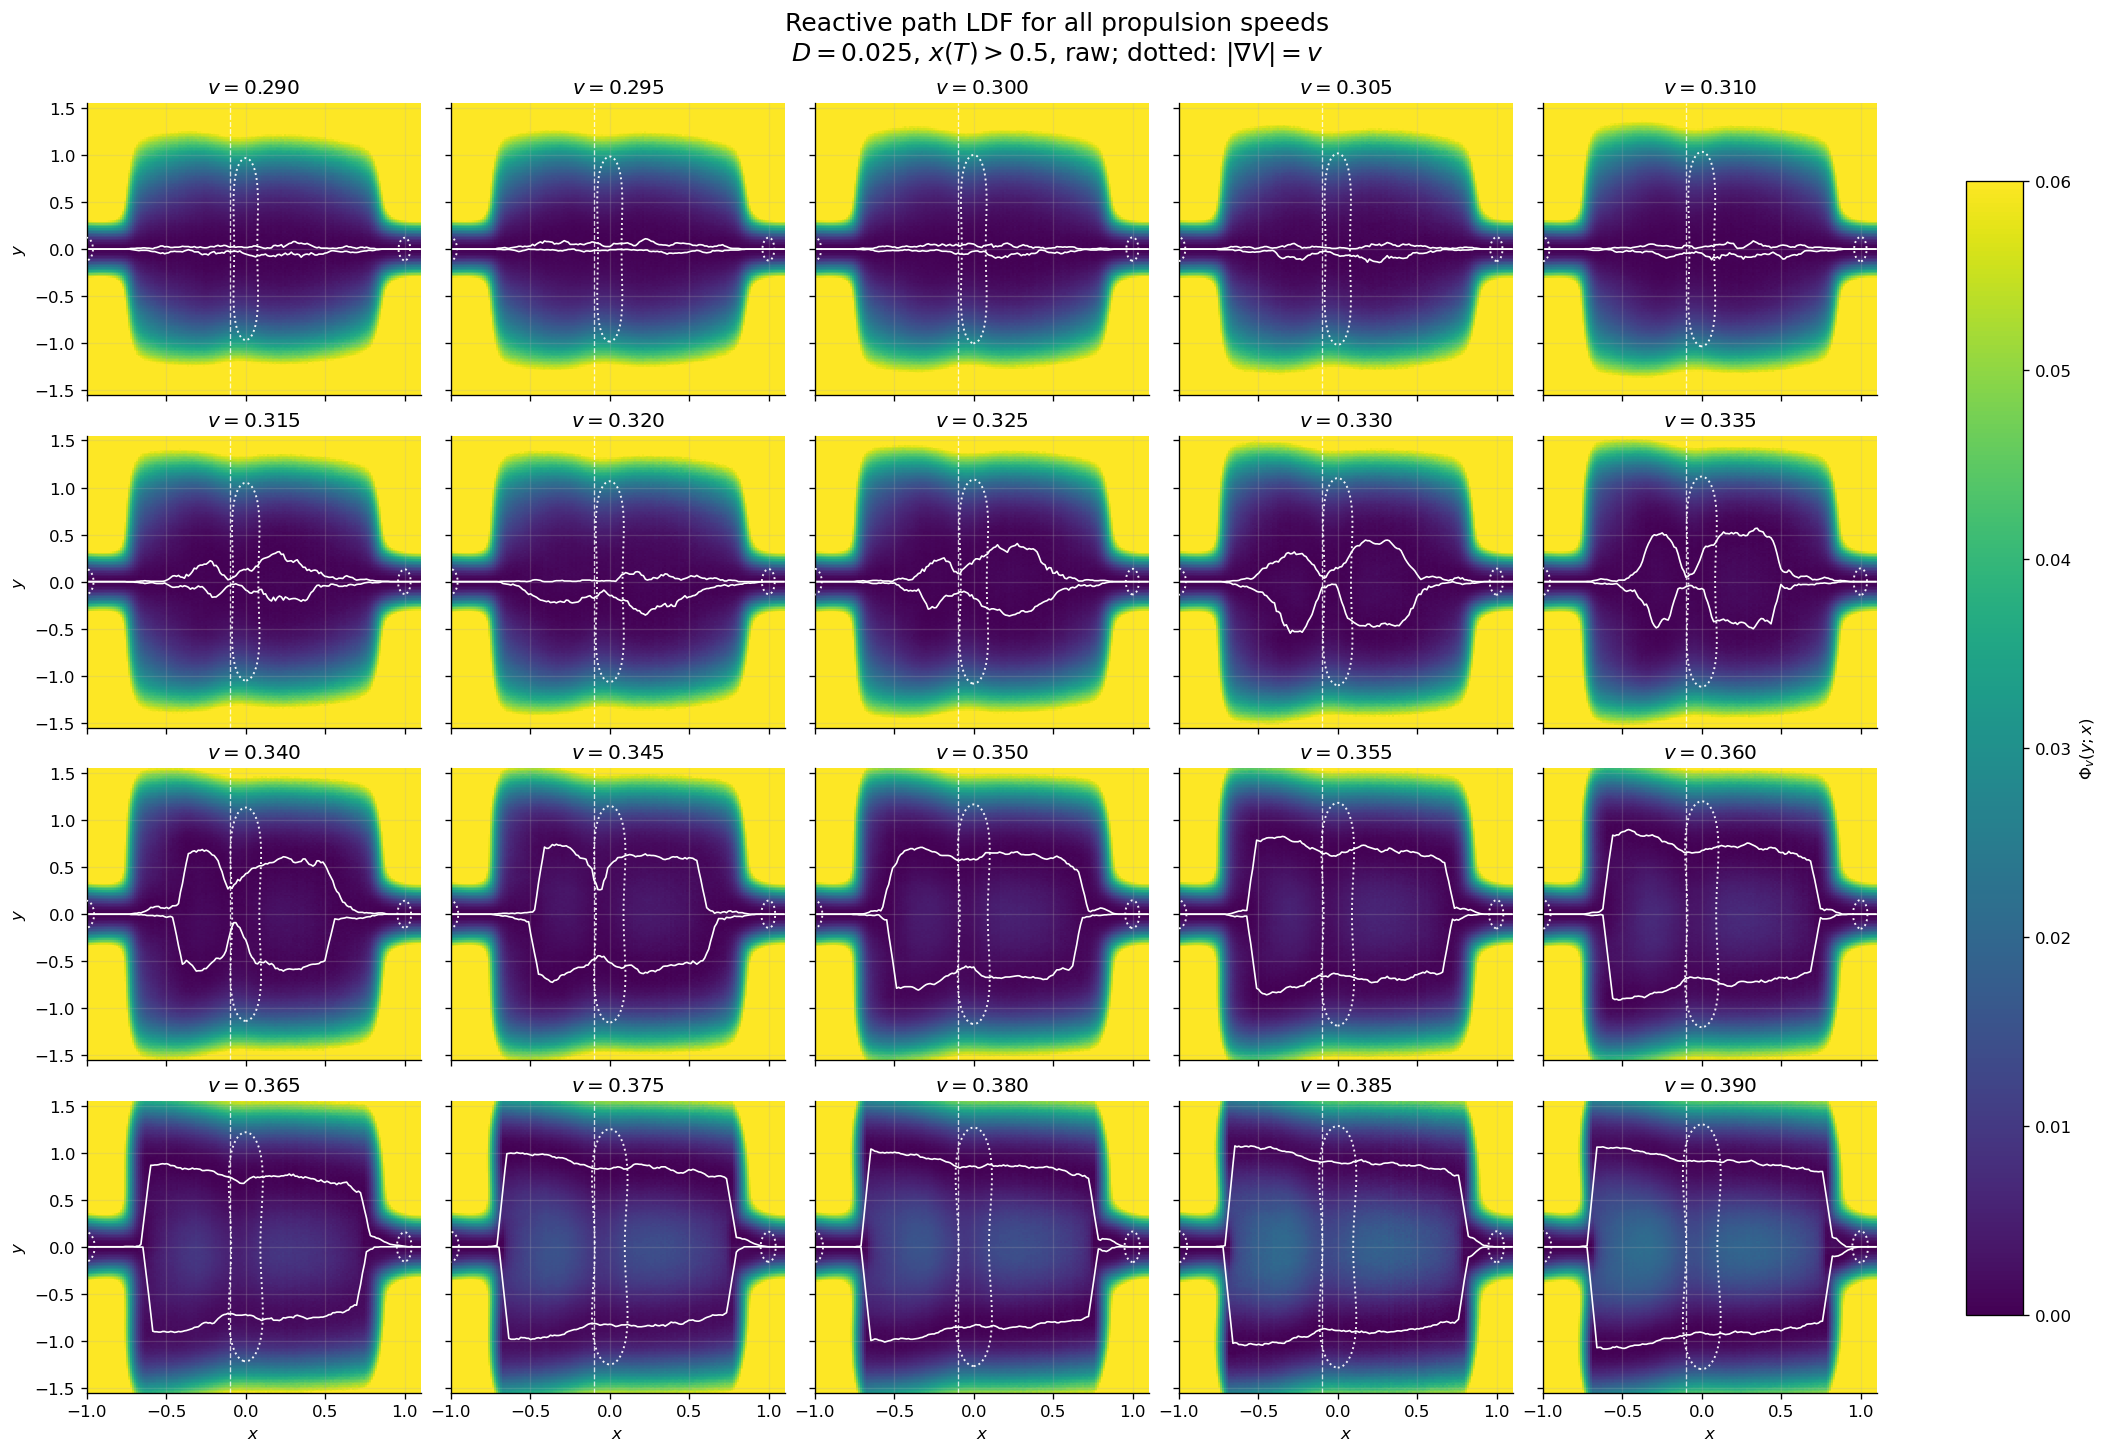

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/all_speeds_preferred_route_central_cost.png


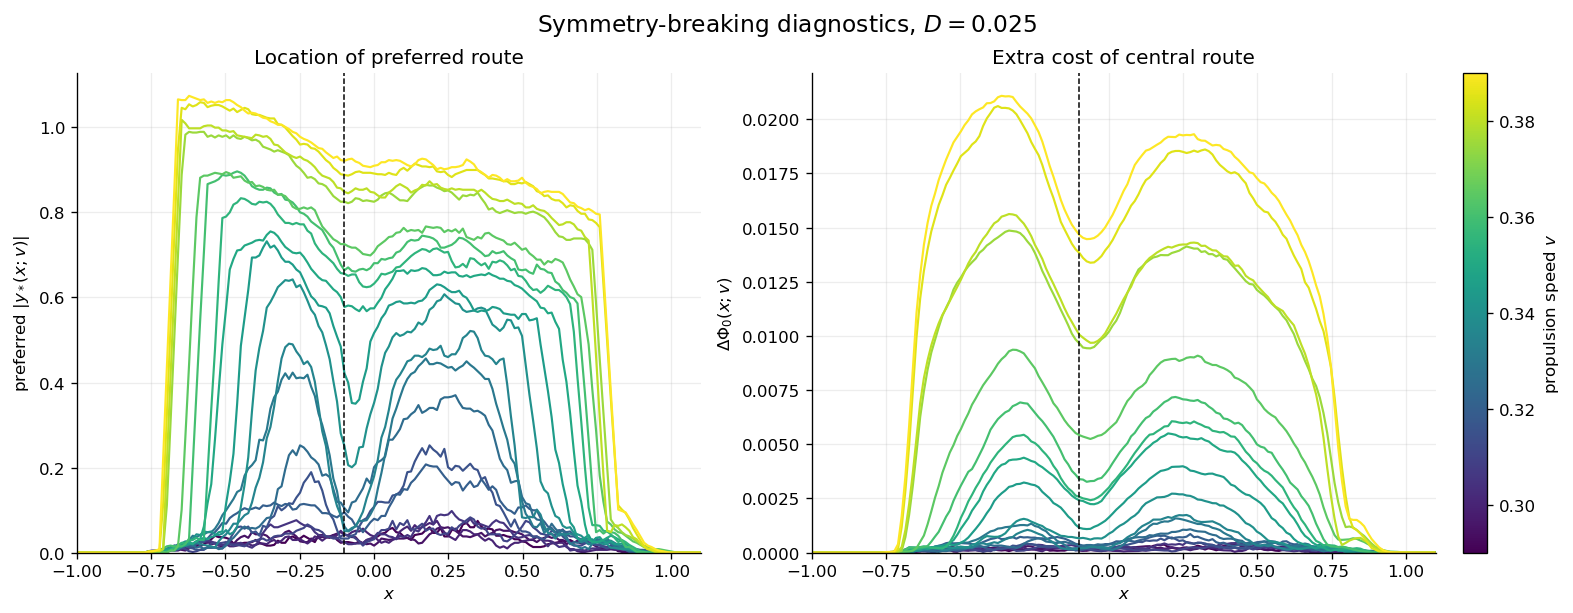

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/all_speeds_phi_slice_x-0.20.png


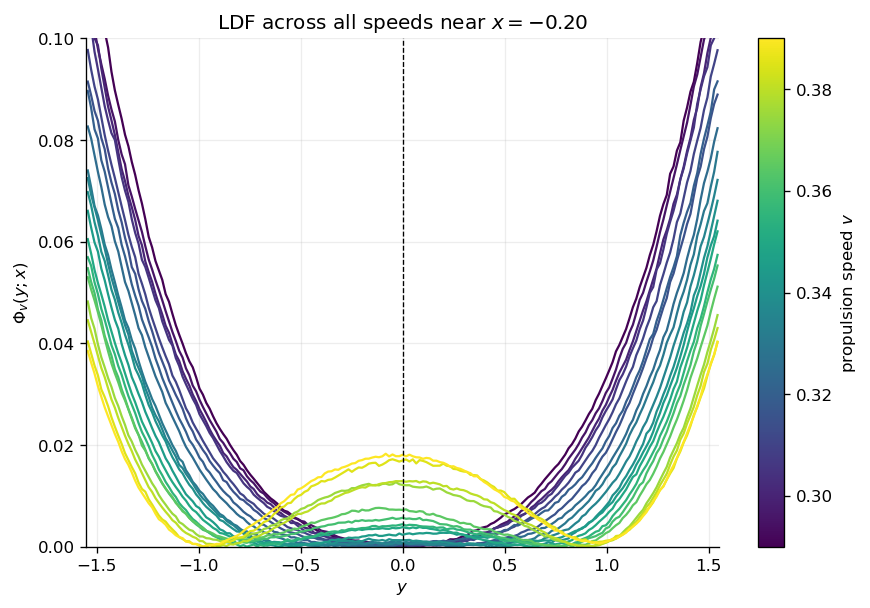


Requested slice x = -0.2
Actual nearest x-grid values: [np.float64(-0.19917)]


In [25]:
# ============================================================
# ALL-SPEED COMPARISON
# Fixed D = 0.025, conditioned on x(T) > 0.5
#
# Produces:
#   1) Phi_v(y;x) heatmaps for ALL speeds
#   2) preferred route |y_*(x)| for ALL speeds
#   3) central-route cost Delta Phi_0(x) for ALL speeds
#   4) Phi_v(y;x_slice) for ALL speeds at one chosen x
#
# Requires PATH_XY from the notebook.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# ============================================================
# CONFIGURATION
# ============================================================

D_LDF = FIXED_D          # 0.025

# Symmetrize under y -> -y before computing the LDF
SYMMETRIZE = False

# Spatial region shown
X_MIN = -1
X_MAX =  1.10

Y_MIN = -1.55
Y_MAX =  1.55

# Maximum Phi shown on heatmaps
PHI_MAX = 0.06

# x position at which all LDF profiles are compared
X_SLICE_COMPARE = -0.20

# Maximum y-LDF shown in slice comparison
PHI_SLICE_MAX = 0.10

# Ignore histogram values smaller than this fraction of
# the maximum at each fixed x
RELATIVE_CUTOFF = 1e-10

# Smooth preferred-route and central-cost curves in x
# Set = 1 for no smoothing
ROUTE_SMOOTH_WINDOW = 5

# Reference line, e.g. C1
X_REFERENCE = -0.10

SAVE_FIGURES = True


# ============================================================
# FORCE-BALANCE CONTOURS |grad V| = v
#
# Reference loci where the active propulsion magnitude v can
# exactly balance the conservative force magnitude.
# ============================================================

SHOW_FORCE_BALANCE_CONTOURS = True

# Potential parameters
K_POTENTIAL = 0.3
LAMBDA_POTENTIAL = 2.5

# Use a slightly larger internal x-domain than the displayed one so
# that the left/right basin contours are computed completely.
FORCE_X_MIN = min(X_MIN, -1.35)
FORCE_X_MAX = max(X_MAX,  1.35)
FORCE_Y_MIN = Y_MIN
FORCE_Y_MAX = Y_MAX

FORCE_CONTOUR_NX = 700
FORCE_CONTOUR_NY = 700

FORCE_CONTOUR_COLOR = "white"
FORCE_CONTOUR_LINEWIDTH = 1.15
FORCE_CONTOUR_ALPHA = 0.95



# ============================================================
# ABP POTENTIAL AND ANALYTIC GRADIENT
#
# g(x) = (x^2 - 1)^2
# F(y) = 1 + k y^2 / 2
# H(y) = lambda y^2 / 2
# f_mix = F H / (F + H)
# V(x,y) = g(x) [F(y) - f_mix(y)] + f_mix(y)
# ============================================================

def grad_abp_potential(x, y, k=K_POTENTIAL, lam=LAMBDA_POTENTIAL):
    """Return dV/dx and dV/dy for scalar values or NumPy arrays."""

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # g(x)
    g = (x**2 - 1.0)**2
    dg_dx = 4.0 * x * (x**2 - 1.0)

    # F(y), H(y)
    F = 1.0 + 0.5 * k * y**2
    H = 0.5 * lam * y**2

    dF_dy = k * y
    dH_dy = lam * y

    denom = F + H

    # f_mix(y)
    f_mix = F * H / denom

    # Exact derivative:
    #
    # d/dy [F H / (F + H)]
    # = [F' H^2 + F^2 H'] / (F + H)^2
    #
    df_mix_dy = (
        dF_dy * H**2
        + F**2 * dH_dy
    ) / denom**2

    # V = g(F-f_mix) + f_mix
    dV_dx = dg_dx * (F - f_mix)

    dV_dy = (
        g * dF_dy
        + (1.0 - g) * df_mix_dy
    )

    return dV_dx, dV_dy


def gradV_magnitude(x, y):
    """Return |grad V(x,y)|."""
    dV_dx, dV_dy = grad_abp_potential(x, y)
    return np.hypot(dV_dx, dV_dy)


# Precompute the force field grid once. The level changes with v,
# but the potential and plotting domain are common to every panel.
_force_x = np.linspace(
    FORCE_X_MIN,
    FORCE_X_MAX,
    FORCE_CONTOUR_NX,
)

_force_y = np.linspace(
    FORCE_Y_MIN,
    FORCE_Y_MAX,
    FORCE_CONTOUR_NY,
)

_FORCE_XX, _FORCE_YY = np.meshgrid(
    _force_x,
    _force_y,
)

_FORCE_MAG = gradV_magnitude(
    _FORCE_XX,
    _FORCE_YY,
)


def add_force_balance_contours(
    ax,
    v,
    *,
    color=FORCE_CONTOUR_COLOR,
    linewidth=FORCE_CONTOUR_LINEWIDTH,
    alpha=FORCE_CONTOUR_ALPHA,
):
    """
    Draw all disconnected components of

        |grad V(x,y)| = v

    on an existing x-y axis.

    In the present double-well geometry these provide the three
    reference components associated with:
        - left basin,
        - central saddle region,
        - right basin.
    """

    return ax.contour(
        _FORCE_XX,
        _FORCE_YY,
        _FORCE_MAG,
        levels=[float(v)],
        colors=[color],
        linestyles=":",
        linewidths=linewidth,
        alpha=alpha,
        zorder=8,
    )


# ============================================================
# HELPERS
# ============================================================

def build_path_grid(df, count_column="unbiased_count"):

    work = df.copy()

    for col in [
        "path_x_center",
        "path_y_center",
        count_column,
    ]:
        work[col] = pd.to_numeric(
            work[col],
            errors="coerce",
        )

    work = work.dropna(
        subset=[
            "path_x_center",
            "path_y_center",
            count_column,
        ]
    )

    work = work[
        (work["path_x_center"] >= X_MIN) &
        (work["path_x_center"] <= X_MAX) &
        (work["path_y_center"] >= Y_MIN) &
        (work["path_y_center"] <= Y_MAX)
    ]

    pivot = work.pivot_table(
        index="path_y_center",
        columns="path_x_center",
        values=count_column,
        aggfunc="sum",
        fill_value=0.0,
    )

    pivot = (
        pivot
        .sort_index()
        .sort_index(axis=1)
    )

    x = pivot.columns.to_numpy(float)
    y = pivot.index.to_numpy(float)

    H = pivot.to_numpy(float)

    H = np.clip(
        H,
        0.0,
        None,
    )

    return x, y, H


def symmetrize_path_grid(y, H):
    """
    H_sym(x,y) = 1/2 [H(x,y) + H(x,-y)]
    """

    Hsym = np.empty_like(
        H,
        dtype=float,
    )

    for ix in range(H.shape[1]):

        col = H[:, ix]

        reflected = np.interp(
            -y,
            y,
            col,
            left=np.nan,
            right=np.nan,
        )

        Hsym[:, ix] = col

        good = (
            np.isfinite(col) &
            np.isfinite(reflected)
        )

        Hsym[good, ix] = 0.5 * (
            col[good] +
            reflected[good]
        )

    return Hsym


def occupation_to_phi(H, D):
    """
    At each fixed x:

        Phi_v(y;x)
        =
        -D log[
            H_v(x,y) / max_y H_v(x,y)
        ]

    so min_y Phi = 0 for each x.
    """

    Phi = np.full_like(
        H,
        np.nan,
        dtype=float,
    )

    for ix in range(H.shape[1]):

        col = H[:, ix]

        if not np.any(
            np.isfinite(col)
        ):
            continue

        hmax = np.nanmax(col)

        if hmax <= 0:
            continue

        good = (
            np.isfinite(col) &
            (col > hmax * RELATIVE_CUTOFF)
        )

        Phi[good, ix] = (
            -D
            * np.log(
                col[good] / hmax
            )
        )

    return Phi


def preferred_routes(y, Phi):

    nx = Phi.shape[1]

    y_plus = np.full(
        nx,
        np.nan,
    )

    y_minus = np.full(
        nx,
        np.nan,
    )

    pos = y >= 0
    neg = y <= 0

    for ix in range(nx):

        col = Phi[:, ix]

        # positive branch
        cp = col[pos]

        if np.any(np.isfinite(cp)):

            yp = y[pos]

            j = np.nanargmin(cp)

            y_plus[ix] = yp[j]

        # negative branch
        cm = col[neg]

        if np.any(np.isfinite(cm)):

            ym = y[neg]

            j = np.nanargmin(cm)

            y_minus[ix] = ym[j]

    preferred_abs = 0.5 * (
        np.abs(y_plus)
        +
        np.abs(y_minus)
    )

    return (
        y_plus,
        y_minus,
        preferred_abs,
    )


def central_route_cost(y, Phi):

    central = np.full(
        Phi.shape[1],
        np.nan,
    )

    for ix in range(
        Phi.shape[1]
    ):

        good = np.isfinite(
            Phi[:, ix]
        )

        if np.sum(good) < 2:
            continue

        yy = y[good]
        pp = Phi[good, ix]

        if (
            yy.min() <= 0
            and yy.max() >= 0
        ):

            central[ix] = np.interp(
                0.0,
                yy,
                pp,
            )

    return central


def smooth_nan(values, window):

    if window <= 1:
        return values.copy()

    return (
        pd.Series(values)
        .rolling(
            window,
            center=True,
            min_periods=1,
        )
        .mean()
        .to_numpy()
    )


# ============================================================
# PREPARE ALL SPEEDS
# ============================================================

ALL_SPEEDS = sorted(
    PATH_XY.keys()
)

print(
    f"Number of speeds: {len(ALL_SPEEDS)}"
)

print(
    "Speeds:",
    ", ".join(
        f"{v:.3f}"
        for v in ALL_SPEEDS
    ),
)


all_data = {}


for v in ALL_SPEEDS:

    x, y, H = build_path_grid(
        PATH_XY[v],
        count_column="unbiased_count",
    )

    # ----------------------------------------
    # Symmetrize BEFORE computing Phi
    # ----------------------------------------

    if SYMMETRIZE:

        H = symmetrize_path_grid(
            y,
            H,
        )

    Phi = occupation_to_phi(
        H,
        D_LDF,
    )

    (
        y_plus,
        y_minus,
        y_star,
    ) = preferred_routes(
        y,
        Phi,
    )

    central = central_route_cost(
        y,
        Phi,
    )

    all_data[v] = {

        "x": x,
        "y": y,
        "H": H,
        "Phi": Phi,

        "y_plus": smooth_nan(
            y_plus,
            ROUTE_SMOOTH_WINDOW,
        ),

        "y_minus": smooth_nan(
            y_minus,
            ROUTE_SMOOTH_WINDOW,
        ),

        "y_star": smooth_nan(
            y_star,
            ROUTE_SMOOTH_WINDOW,
        ),

        "central": smooth_nan(
            central,
            ROUTE_SMOOTH_WINDOW,
        ),
    }


# ============================================================
# SPEED COLORMAP
# ============================================================

vmin = min(ALL_SPEEDS)
vmax = max(ALL_SPEEDS)

speed_norm = Normalize(
    vmin=vmin,
    vmax=vmax,
)

speed_cmap = plt.get_cmap(
    "viridis"
)


def vcolor(v):

    return speed_cmap(
        speed_norm(v)
    )


# ============================================================
# FIGURE 1
#
# Phi_v(y;x) FOR EVERY SPEED
# ============================================================

n = len(ALL_SPEEDS)

NCOLS = 5

NROWS = int(
    np.ceil(
        n / NCOLS
    )
)


fig, axes = plt.subplots(
    NROWS,
    NCOLS,
    figsize=(
        3.5 * NCOLS,
        3.0 * NROWS,
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(
    axes
).ravel()


phi_mesh = None


for i, v in enumerate(
    ALL_SPEEDS
):

    ax = axes[i]

    dat = all_data[v]

    x = dat["x"]
    y = dat["y"]
    Phi = dat["Phi"]

    phi_mesh = ax.pcolormesh(
        x,
        y,
        np.clip(
            Phi,
            0,
            PHI_MAX,
        ),
        shading="auto",
        cmap="viridis",
        vmin=0,
        vmax=PHI_MAX,
    )

    # Dotted force-balance reference contours:
    # |grad V(x,y)| = v
    #
    # The level is different in every panel because each panel
    # corresponds to a different propulsion speed.
    if SHOW_FORCE_BALANCE_CONTOURS:
        add_force_balance_contours(
            ax,
            v,
        )

    # preferred upper/lower branches (solid white)
    ax.plot(
        x,
        dat["y_plus"],
        color="white",
        lw=1.0,
    )

    ax.plot(
        x,
        dat["y_minus"],
        color="white",
        lw=1.0,
    )

    ax.axvline(
        X_REFERENCE,
        color="white",
        ls="--",
        lw=0.8,
        alpha=0.8,
    )

    ax.set_title(
        rf"$v={v:.3f}$"
    )

    ax.set_xlim(
        X_MIN,
        X_MAX,
    )

    ax.set_ylim(
        Y_MIN,
        Y_MAX,
    )

    if i % NCOLS == 0:
        ax.set_ylabel(r"$y$")

    if i >= (
        NROWS - 1
    ) * NCOLS:
        ax.set_xlabel(r"$x$")


# hide empty panels
for j in range(
    n,
    len(axes),
):

    axes[j].axis("off")


fig.colorbar(
    phi_mesh,
    ax=axes.tolist(),
    label=r"$\Phi_v(y;x)$",
    shrink=0.88,
)


sym_text = (
    "symmetrized"
    if SYMMETRIZE
    else "raw"
)


fig.suptitle(
    rf"Reactive path LDF for all propulsion speeds"
    "\n"
    rf"$D={D_LDF:g}$, $x(T)>0.5$, {sym_text}; "
    rf"dotted: $|\nabla V|=v$",
    fontsize=15,
)


if SAVE_FIGURES:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    outfile = (
        OUTPUT_DIR
        / "all_speeds_phi_xy.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        outfile,
    )


plt.show()


# ============================================================
# FIGURE 2
#
# ALL SPEEDS:
# preferred |y_*|
# and central-route action penalty
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True,
)


# ------------------------------------------------------------
# Preferred route
# ------------------------------------------------------------

for v in ALL_SPEEDS:

    dat = all_data[v]

    axes[0].plot(
        dat["x"],
        dat["y_star"],
        lw=1.3,
        color=vcolor(v),
    )


axes[0].axvline(
    X_REFERENCE,
    color="black",
    ls="--",
    lw=0.9,
)


axes[0].set(
    xlabel=r"$x$",
    ylabel=r"preferred $|y_*(x;v)|$",
    title="Location of preferred route",
)


axes[0].set_xlim(
    X_MIN,
    X_MAX,
)

axes[0].set_ylim(
    bottom=0,
)


# ------------------------------------------------------------
# Central-route penalty
# ------------------------------------------------------------

for v in ALL_SPEEDS:

    dat = all_data[v]

    axes[1].plot(
        dat["x"],
        dat["central"],
        lw=1.3,
        color=vcolor(v),
    )


axes[1].axvline(
    X_REFERENCE,
    color="black",
    ls="--",
    lw=0.9,
)


axes[1].axhline(
    0,
    color="black",
    lw=0.7,
)


axes[1].set(
    xlabel=r"$x$",
    ylabel=r"$\Delta\Phi_0(x;v)$",
    title="Extra cost of central route",
)


axes[1].set_xlim(
    X_MIN,
    X_MAX,
)

axes[1].set_ylim(
    bottom=0,
)


# Shared speed colorbar
sm = plt.cm.ScalarMappable(
    norm=speed_norm,
    cmap=speed_cmap,
)

sm.set_array([])


fig.colorbar(
    sm,
    ax=axes.tolist(),
    label=r"propulsion speed $v$",
    pad=0.02,
)


fig.suptitle(
    rf"Symmetry-breaking diagnostics, $D={D_LDF:g}$",
    fontsize=14,
)


if SAVE_FIGURES:

    outfile = (
        OUTPUT_DIR
        / "all_speeds_preferred_route_central_cost.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        outfile,
    )


plt.show()


# ============================================================
# FIGURE 3
#
# DIRECT LDF COMPARISON AT ONE x SLICE
#
# Phi_v(y ; x = X_SLICE_COMPARE)
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


actual_x_values = []


for v in ALL_SPEEDS:

    dat = all_data[v]

    x = dat["x"]
    y = dat["y"]
    Phi = dat["Phi"]

    ix = int(
        np.argmin(
            np.abs(
                x
                -
                X_SLICE_COMPARE
            )
        )
    )

    actual_x_values.append(
        x[ix]
    )

    phi = Phi[:, ix]

    good = (
        np.isfinite(y)
        &
        np.isfinite(phi)
    )

    ax.plot(
        y[good],
        phi[good],
        lw=1.35,
        color=vcolor(v),
    )


ax.axvline(
    0,
    color="black",
    ls="--",
    lw=0.8,
)


ax.set(
    xlabel=r"$y$",
    ylabel=r"$\Phi_v(y;x)$",
    title=(
        rf"LDF across all speeds near "
        rf"$x={X_SLICE_COMPARE:.2f}$"
    ),
)


ax.set_xlim(
    Y_MIN,
    Y_MAX,
)

ax.set_ylim(
    0,
    PHI_SLICE_MAX,
)


sm = plt.cm.ScalarMappable(
    norm=speed_norm,
    cmap=speed_cmap,
)

sm.set_array([])


fig.colorbar(
    sm,
    ax=ax,
    label=r"propulsion speed $v$",
)


if SAVE_FIGURES:

    outfile = (
        OUTPUT_DIR
        / (
            "all_speeds_phi_slice_"
            f"x{X_SLICE_COMPARE:+.2f}"
            ".png"
        )
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        outfile,
    )


plt.show()


print()
print(
    "Requested slice x =",
    X_SLICE_COMPARE,
)

print(
    "Actual nearest x-grid values:",
    sorted(
        set(
            np.round(
                actual_x_values,
                6,
            )
        )
    ),
)

## Interpretation checklist

Before using the speed-dependent Landau result in the thesis/paper, check:

- all 15 expected velocities are present;
- the final MUCA histograms actually cover the full intended bias window;
- flatness/round-trip behavior does not deteriorate catastrophically at one speed;
- ESS/N remains acceptable for the reweighted observables;
- `path_x_filter_min` is the intended value for every speed;
- the inferred \(v_c\) is stable when changing the \(x\)-slice and the quartic fit window;
- \(c_4>0\) in the region where the continuous-transition Landau picture is invoked;
- the qualitative route splitting is visible directly in the \(x\)-\(y\) occupation maps, not only in the polynomial fit.

For a publication-quality transition estimate, repeat the Landau extraction for
several nearby \(x\)-slices and fit windows and quote the spread as a systematic
sensitivity rather than treating a single quartic zero crossing as exact.


INDIVIDUAL LANDAU FITS
PASS criteria:
  R^2 >= 0.95
  c4 > 0
  n_fit >= 7
  if c2 < 0: fitted y* lies inside the fitted y-window


,v,x_min,x_max,y_mode,y_landau,c2,c4,R2,RMSE_phi,landau_status
0,0.290,-0.5,-0.3,0.000000,0.000000,0.025024,0.006611,0.995186,0.000644,PASS
1,0.295,-0.5,-0.3,0.049793,0.000000,0.021773,0.006934,0.997601,0.000410,PASS
2,0.300,-0.5,-0.3,0.033195,0.000000,0.018825,0.007391,0.998525,0.000292,PASS
3,0.305,-0.5,-0.3,0.000000,0.000000,0.017564,0.007304,0.999150,0.000210,PASS
4,0.310,-0.5,-0.3,0.016598,0.000000,0.013861,0.007710,0.994014,0.000481,PASS
...,...,...,...,...,...,...,...,...,...,...
115,0.365,-0.1,0.1,0.746888,0.719508,-0.019955,0.019273,0.871382,0.000688,FAIL
116,0.375,-0.1,0.1,0.846473,0.838479,-0.027859,0.019813,0.970999,0.000618,PASS
117,0.380,-0.1,0.1,0.846473,0.862574,-0.028555,0.019189,0.994139,0.000299,PASS
118,0.385,-0.1,0.1,0.912863,0.926031,-0.033179,0.019346,0.996127,0.000322,PASS



LANDAU FIT STATUS BY x-SLICE
Slice PASS = at least 80% of its speed-by-speed quartic fits pass.


,x_min,x_max,slice_status,n_pass,n_speeds,pass_fraction,median_R2,min_R2,positive_c4_fraction,vc_adjacent,vc_c2_linear,R2_c2_linear,c4_at_vc
0,-0.50,-0.30,FAIL,11,20,0.55,0.991238,0.711020,1.0,0.328552,0.331456,0.815065,0.010867
1,-0.40,-0.20,FAIL,12,20,0.60,0.992980,0.828004,1.0,0.324300,0.322414,0.855371,0.013794
2,-0.30,-0.10,FAIL,15,20,0.75,0.993719,0.912861,1.0,0.324345,0.323343,0.882358,0.015938
3,-0.25,-0.15,FAIL,15,20,0.75,0.993416,0.915328,1.0,0.323559,0.322091,0.880829,0.016196
4,-0.20,0.00,PASS,18,20,0.90,0.994007,0.860945,1.0,0.327434,0.329347,0.891347,0.016378
5,-0.10,0.10,PASS,18,20,0.90,0.994772,0.871382,1.0,0.326897,0.328737,0.897465,0.017109


,v,x_min,x_max,x_center,y_max_fit,y_mode,y_landau,difference,abs_difference,c2,c4,R2,RMSE_phi,n_fit,stable_c4,good_R2,minimum_inside_fit,enough_points,landau_pass,landau_status
0,0.290,-0.5,-0.3,-0.4,1.0,0.000000,0.000000,0.000000,0.000000,0.025024,0.006611,0.995186,0.000644,121,True,True,True,True,True,PASS
1,0.295,-0.5,-0.3,-0.4,1.0,0.049793,0.000000,0.049793,0.049793,0.021773,0.006934,0.997601,0.000410,121,True,True,True,True,True,PASS
2,0.300,-0.5,-0.3,-0.4,1.0,0.033195,0.000000,0.033195,0.033195,0.018825,0.007391,0.998525,0.000292,121,True,True,True,True,True,PASS
3,0.305,-0.5,-0.3,-0.4,1.0,0.000000,0.000000,0.000000,0.000000,0.017564,0.007304,0.999150,0.000210,121,True,True,True,True,True,PASS
4,0.310,-0.5,-0.3,-0.4,1.0,0.016598,0.000000,0.016598,0.016598,0.013861,0.007710,0.994014,0.000481,121,True,True,True,True,True,PASS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.365,-0.1,0.1,0.0,1.0,0.746888,0.719508,0.027380,0.027380,-0.019955,0.019273,0.871382,0.000688,121,True,False,True,True,False,FAIL
116,0.375,-0.1,0.1,0.0,1.0,0.846473,0.838479,0.007994,0.007994,-0.027859,0.019813,0.970999,0.000618,121,True,True,True,True,True,PASS
117,0.380,-0.1,0.1,0.0,1.0,0.846473,0.862574,-0.016101,0.016101,-0.028555,0.019189,0.994139,0.000299,121,True,True,True,True,True,PASS
118,0.385,-0.1,0.1,0.0,1.0,0.912863,0.926031,-0.013168,0.013168,-0.033179,0.019346,0.996127,0.000322,121,True,True,True,True,True,PASS


Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/y_mode_vs_landau_all_x_slices.png


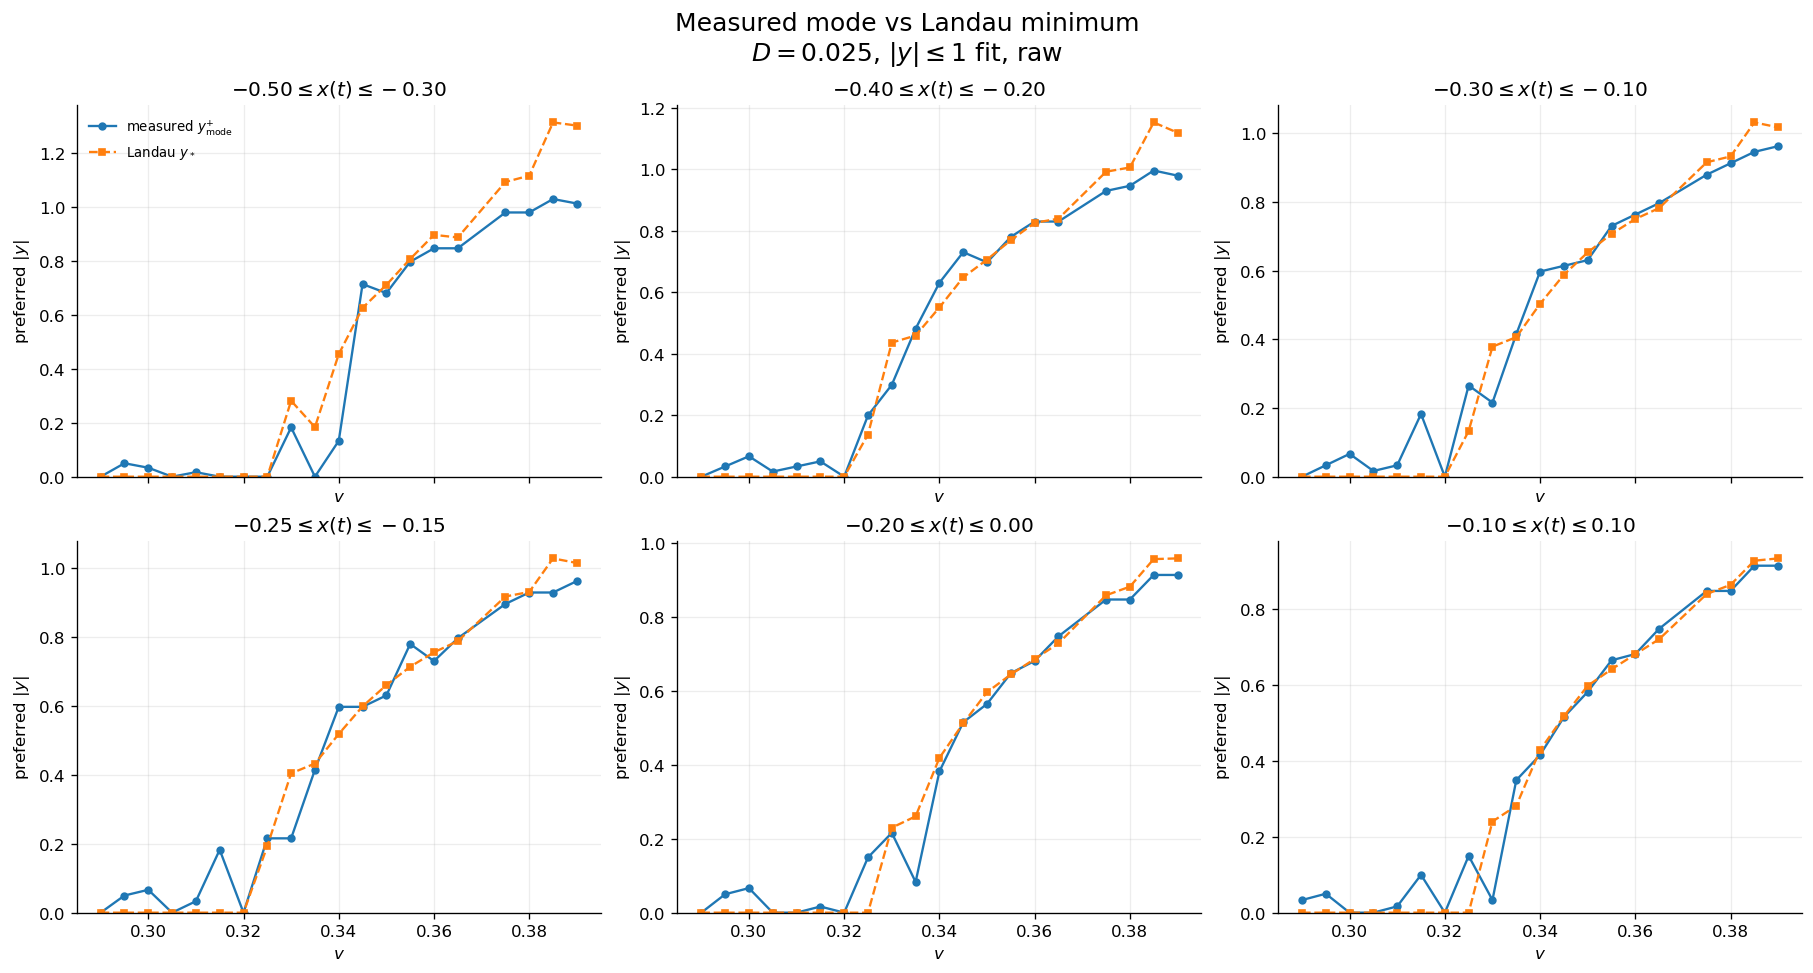

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/y_mode_vs_landau_scatter.png


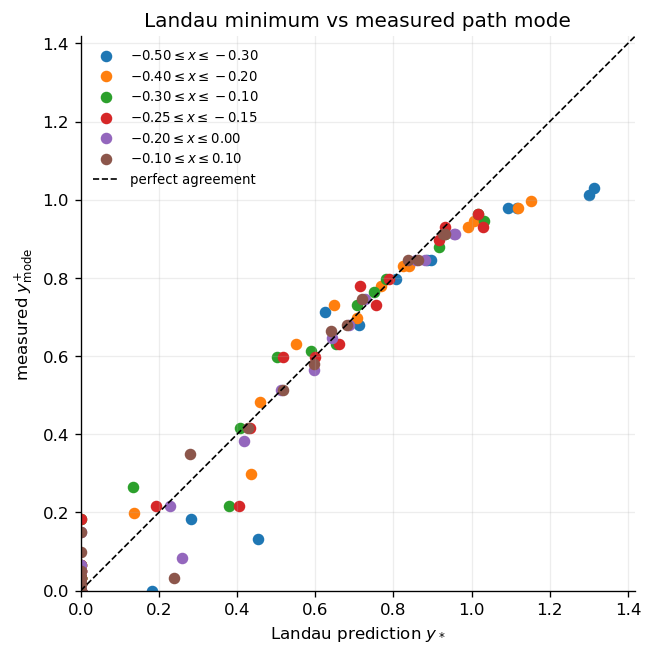

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/y_mode_landau_difference.png


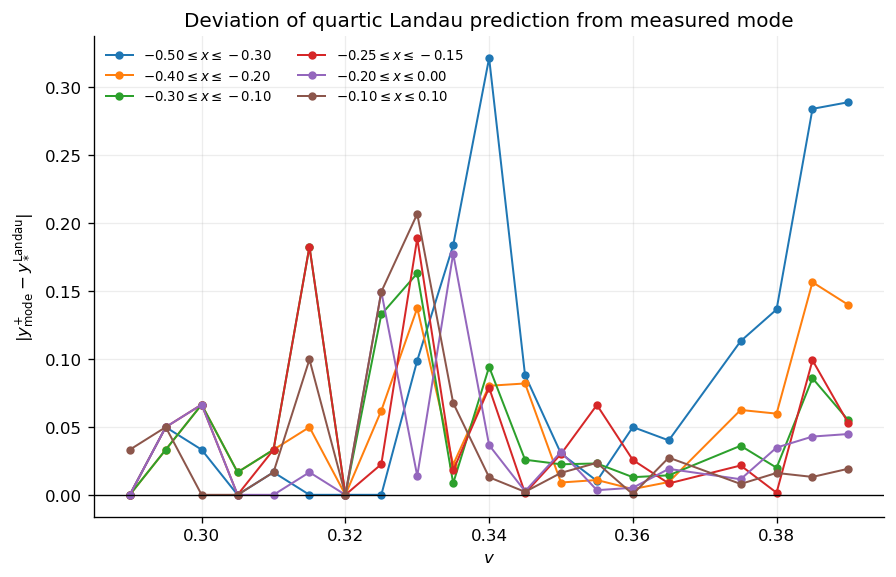

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/landau_c2_c4_comparison_all_slices.png


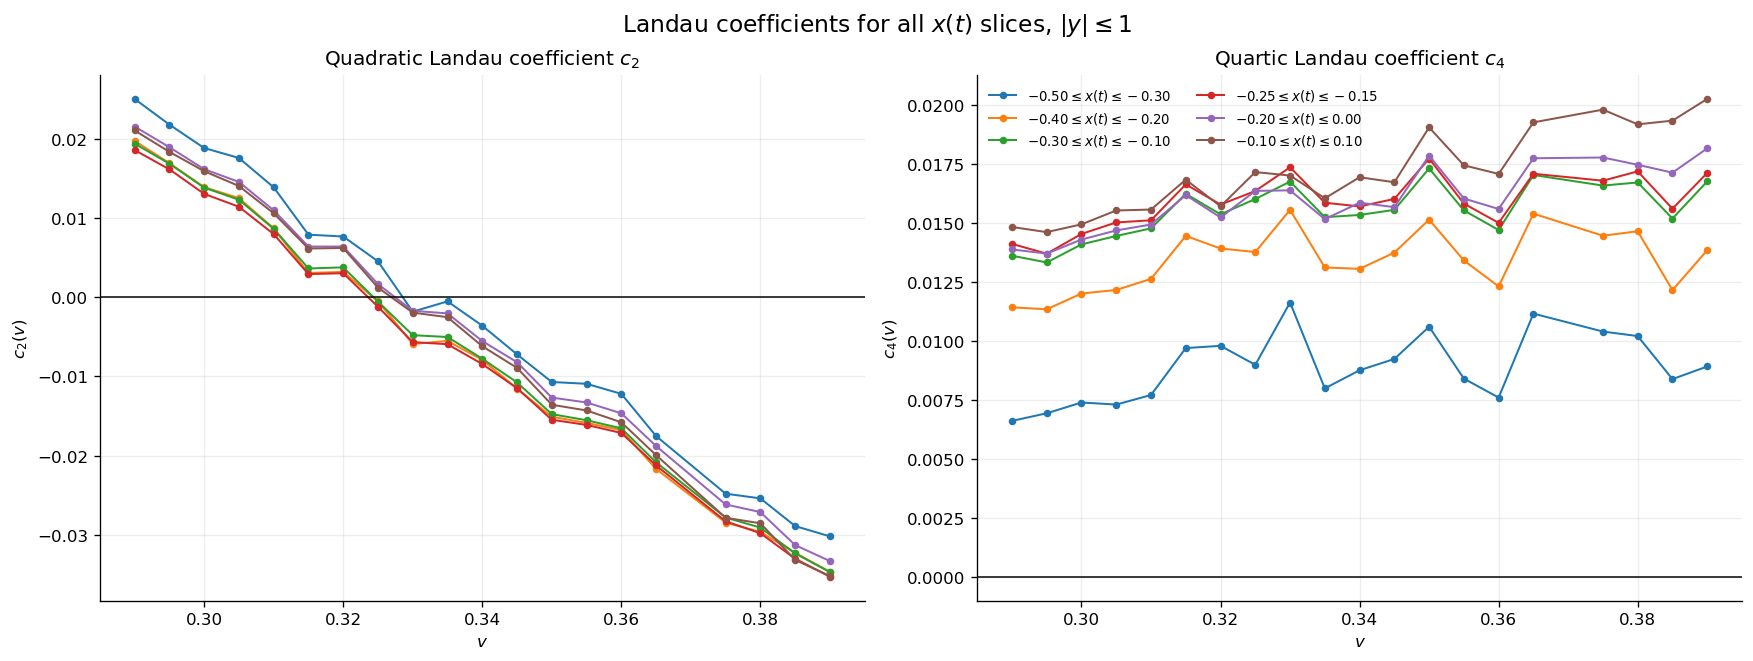

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/landau_c2_local_fits_by_slice.png


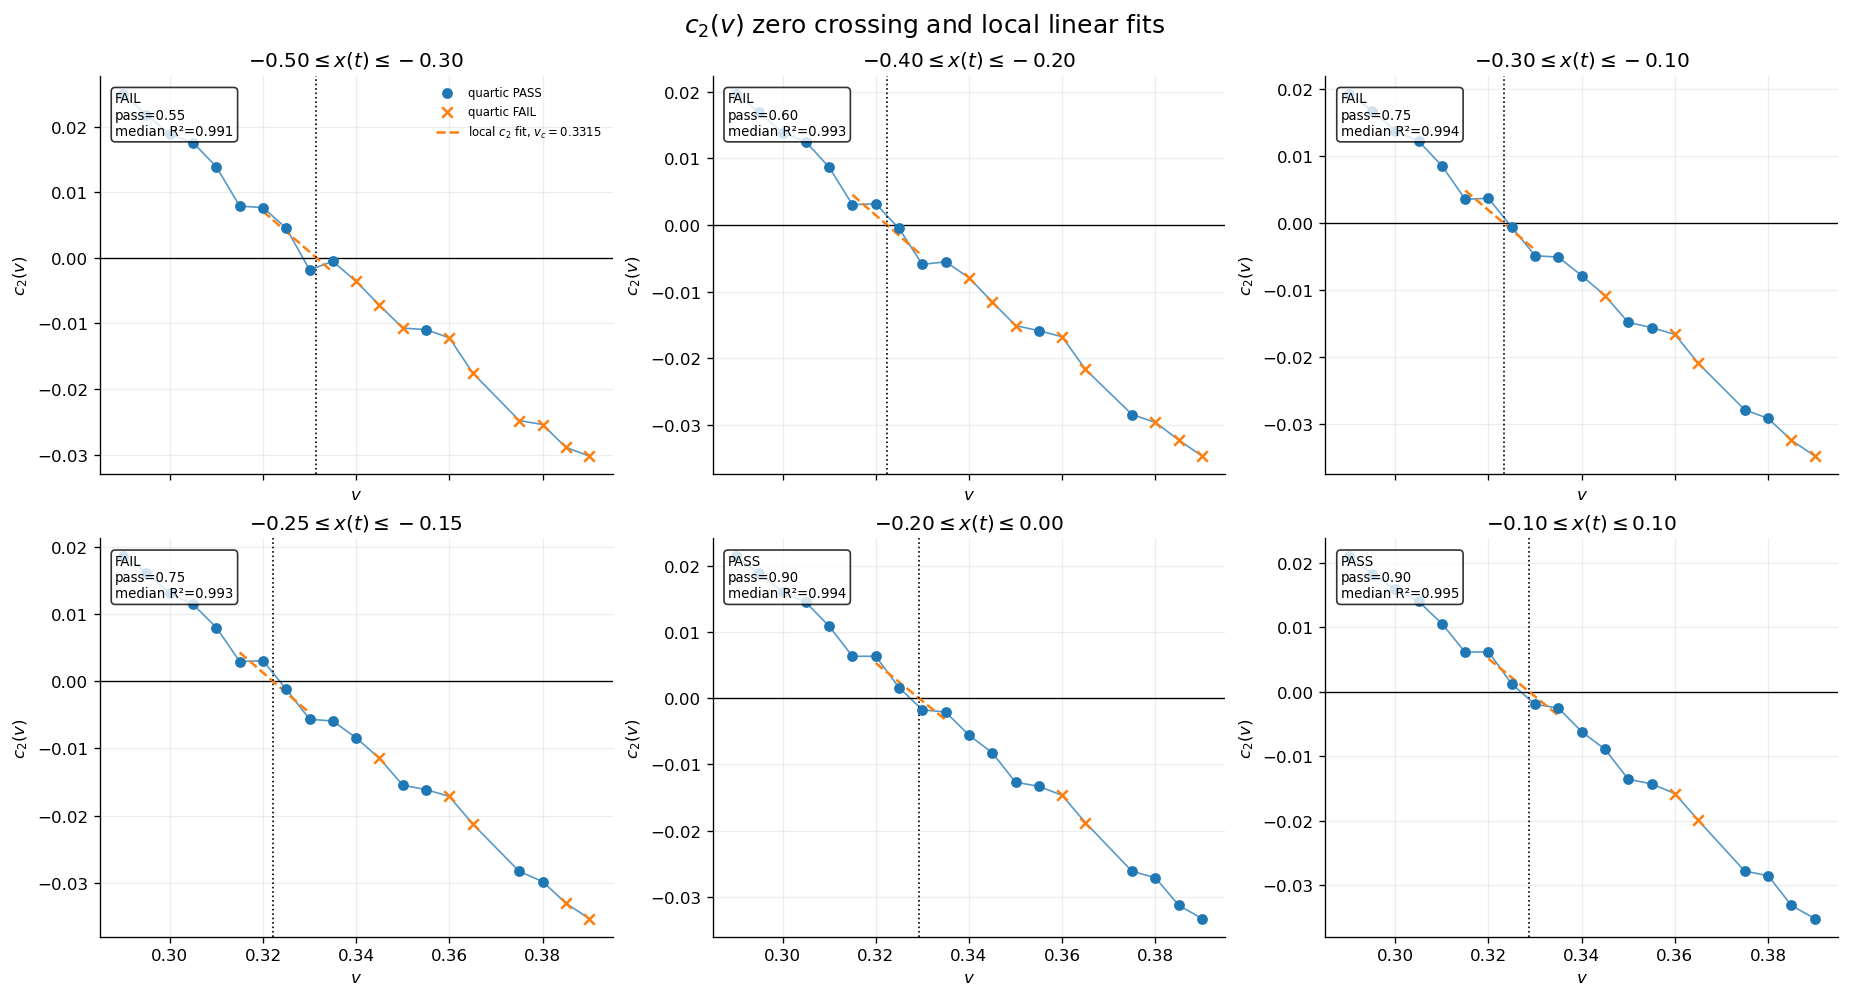

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/landau_c4_by_slice.png


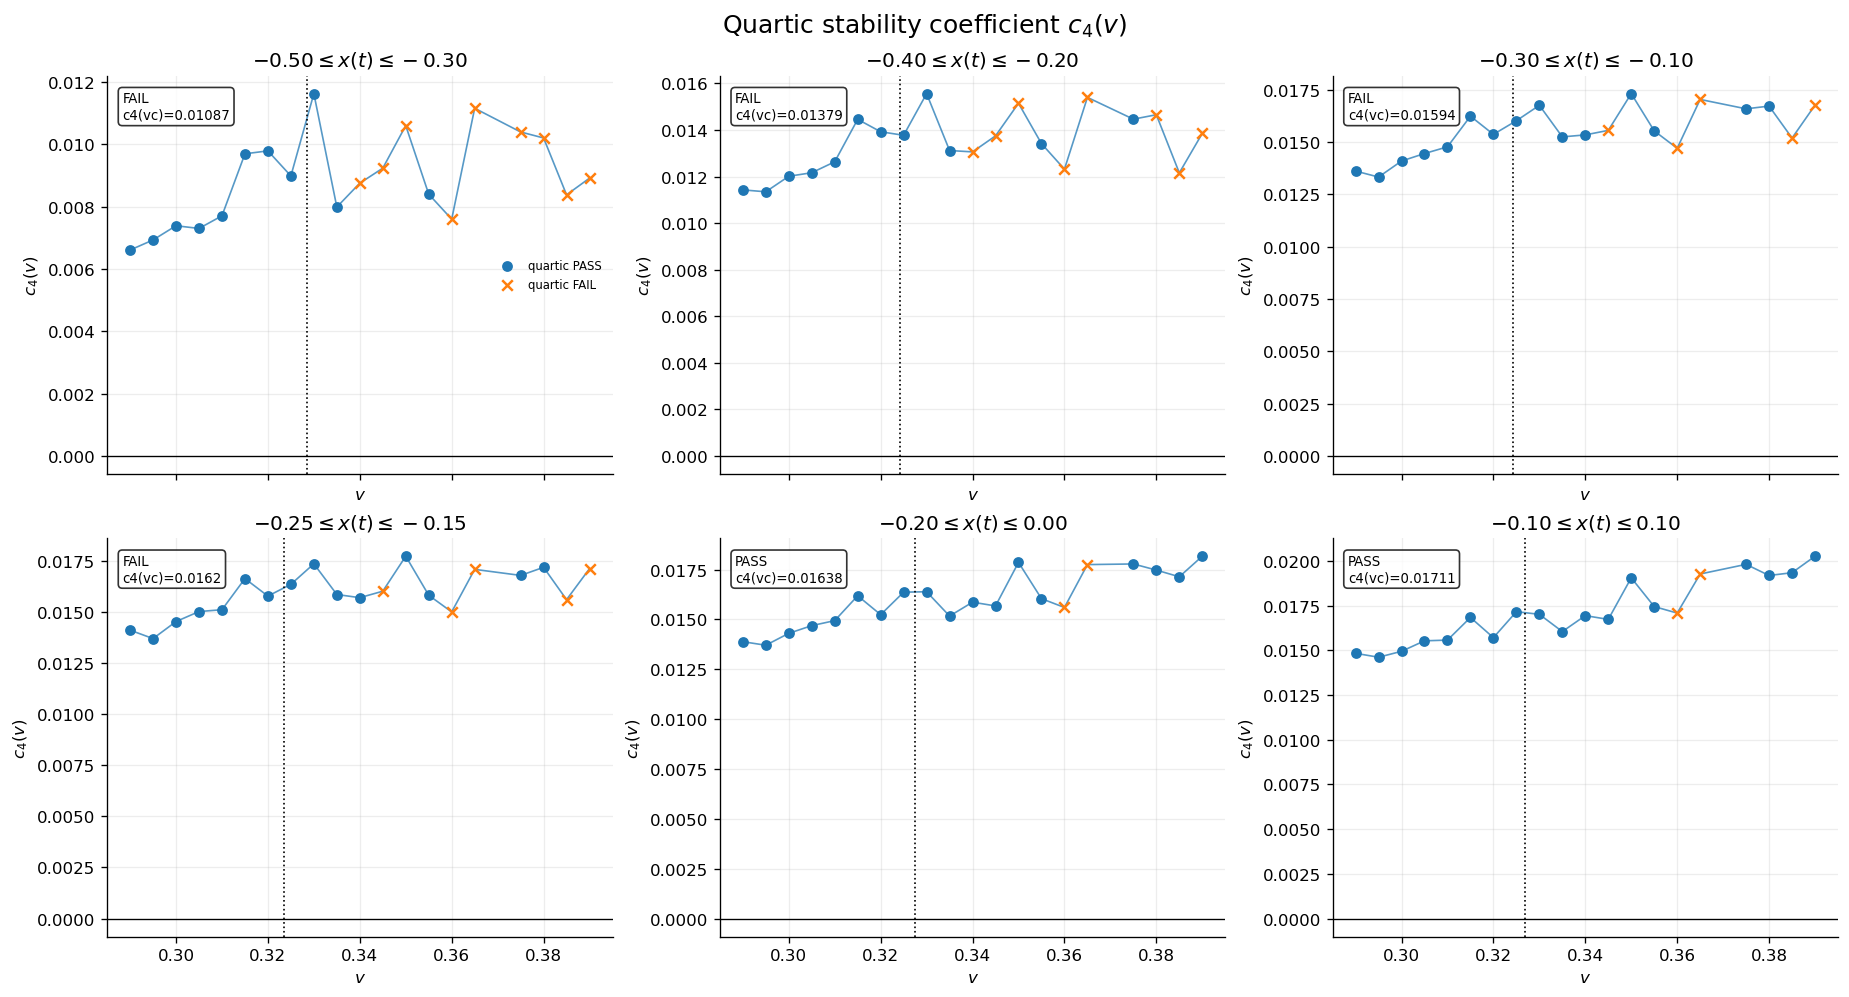

Saved: /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/plots_speed_jobs_1669022_1700987/landau_fit_quality_comparison.png


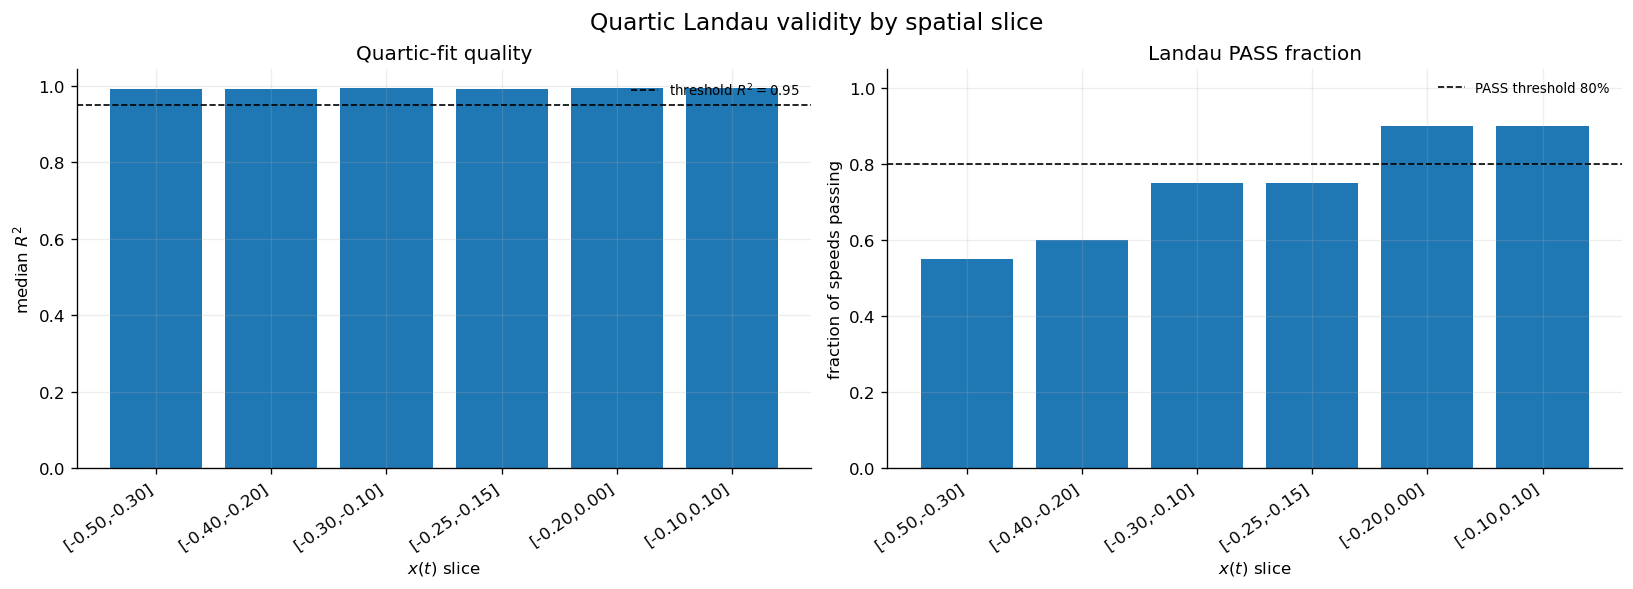


MODE vs LANDAU AGREEMENT
points       = 120
RMSE         = 0.082755
correlation  = 0.980598


In [26]:
# ============================================================
# COMPARE MEASURED y-MODE WITH LANDAU-FIT y*
#
# For each x(t) slice and each propulsion speed:
#
#   y_mode^+    = argmax_{y >= 0} p(y)
#
#   y_Landau    = sqrt[-c2/(2 c4)]
#
# where
#
#   Phi(y) = c0 + c2 y^2 + c4 y^4
#
# Uses exactly the same p(y) for both quantities.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

# x-windows to compare
X_FILTERS_COMPARE = [
    (-0.50, -0.30),
    (-0.40, -0.20),
    (-0.30, -0.10),
    (-0.25, -0.15),
    (-0.20,  0.00),
    (-0.10,  0.10),
]

# Landau fitting range:
#
#      |y| <= LANDAU_COMPARE_YMAX
#
LANDAU_COMPARE_YMAX = 1.0

D_COMPARE = FIXED_D

# IMPORTANT:
# For a clean comparison, use the same symmetrized distribution
# for BOTH the histogram mode and the Landau fit.
COMPARE_SYMMETRIZE = False

RELATIVE_DENSITY_CUTOFF = 1e-12

MIN_FIT_POINTS = 7


# ============================================================
# LANDAU FIT VALIDATION
# ============================================================

LANDAU_MIN_R2 = 0.95
SLICE_MIN_PASS_FRACTION = 0.80
C2_LOCAL_FIT_POINTS_EACH_SIDE = 2

SAVE_FIGURE = True


# ============================================================
# HELPERS
# ============================================================

def compare_bin_widths(y):

    y = np.asarray(y, float)

    if len(y) < 2:
        return np.ones_like(y)

    mids = 0.5 * (
        y[:-1] + y[1:]
    )

    edges = np.r_[
        y[0] - (mids[0] - y[0]),
        mids,
        y[-1] + (y[-1] - mids[-1]),
    ]

    return np.diff(edges)


def compare_symmetrize_density(y, density):

    reflected = np.interp(
        -y,
        y,
        density,
        left=np.nan,
        right=np.nan,
    )

    result = density.copy()

    good = (
        np.isfinite(density)
        &
        np.isfinite(reflected)
    )

    result[good] = 0.5 * (
        density[good]
        +
        reflected[good]
    )

    return result


# ============================================================
# CONSTRUCT p(y) AND Phi(y)
# ============================================================

def make_mode_landau_profile(
    df,
    x_min,
    x_max,
):

    # --------------------------------------------------------
    # Select x(t) slice
    # --------------------------------------------------------

    cut = df[
        (df["path_x_center"] >= x_min)
        &
        (df["path_x_center"] <= x_max)
    ].copy()

    if cut.empty:
        return None


    # --------------------------------------------------------
    # Integrate x inside the selected interval
    # --------------------------------------------------------

    prof = (
        cut.groupby(
            "path_y_center",
            as_index=False,
        )
        .agg(
            unbiased_count=(
                "unbiased_count",
                "sum",
            )
        )
        .sort_values(
            "path_y_center"
        )
    )


    y = prof[
        "path_y_center"
    ].to_numpy(float)

    counts = prof[
        "unbiased_count"
    ].to_numpy(float)


    good = (
        np.isfinite(y)
        &
        np.isfinite(counts)
    )

    y = y[good]
    counts = counts[good]

    counts = np.clip(
        counts,
        0,
        None,
    )


    if counts.sum() <= 0:
        return None


    # --------------------------------------------------------
    # Convert counts -> density
    # --------------------------------------------------------

    dy = compare_bin_widths(y)

    density = (
        counts
        /
        (
            counts.sum()
            * dy
        )
    )


    # --------------------------------------------------------
    # Symmetrize
    # --------------------------------------------------------

    if COMPARE_SYMMETRIZE:

        density = compare_symmetrize_density(
            y,
            density,
        )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    norm = np.sum(
        density * dy
    )

    if norm > 0:
        density = density / norm


    # --------------------------------------------------------
    # LDF
    #
    # Phi(y) = -D log[p(y)/pmax]
    # --------------------------------------------------------

    pmax = np.nanmax(
        density
    )

    valid = (
        np.isfinite(density)
        &
        (
            density
            >
            pmax
            * RELATIVE_DENSITY_CUTOFF
        )
    )


    phi = np.full_like(
        density,
        np.nan,
    )


    phi[valid] = (
        -D_COMPARE
        *
        np.log(
            density[valid]
            /
            pmax
        )
    )


    return (
        y,
        density,
        phi,
    )


# ============================================================
# MEASURED POSITIVE MODE
# ============================================================

def measured_positive_mode(
    y,
    density,
):

    positive = (
        y >= 0
    )

    good = (
        positive
        &
        np.isfinite(density)
    )


    if not np.any(good):
        return np.nan


    yy = y[good]
    pp = density[good]


    return float(
        yy[
            np.argmax(pp)
        ]
    )


# ============================================================
# LANDAU FIT
#
# Phi = c0 + c2 y² + c4 y⁴
# ============================================================

def fit_landau_for_comparison(
    y,
    phi,
    y_max,
):

    good = (
        np.isfinite(y)
        &
        np.isfinite(phi)
        &
        (
            np.abs(y)
            <= y_max
        )
    )


    yy = y[good]
    pp = phi[good]


    if len(yy) < MIN_FIT_POINTS:
        return None


    X = np.column_stack([
        np.ones_like(yy),
        yy**2,
        yy**4,
    ])


    coeff, *_ = np.linalg.lstsq(
        X,
        pp,
        rcond=None,
    )


    c0, c2, c4 = coeff


    fitted = (
        c0
        +
        c2 * yy**2
        +
        c4 * yy**4
    )


    ss_res = np.sum(
        (pp - fitted)**2
    )

    ss_tot = np.sum(
        (pp - np.mean(pp))**2
    )


    R2 = (
        1.0 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Landau minimum
    #
    # dPhi/dy =
    #
    #   2 c2 y + 4 c4 y³ = 0
    #
    # =>
    #
    #   y_*² = -c2/(2 c4)
    #
    # --------------------------------------------------------

    if (
        c2 < 0
        and c4 > 0
    ):

        y_landau = np.sqrt(
            -c2
            /
            (2.0 * c4)
        )

    else:

        # Single central minimum
        y_landau = 0.0


    rmse_phi = np.sqrt(
        np.mean(
            (pp - fitted)**2
        )
    )

    return {
        "c0": c0,
        "c2": c2,
        "c4": c4,
        "R2": R2,
        "RMSE_phi": rmse_phi,
        "y_landau": y_landau,
        "n_fit": len(yy),
    }


# ============================================================
# COMPUTE EVERYTHING
# ============================================================

comparison_rows = []


for x_min, x_max in X_FILTERS_COMPARE:

    for v in sorted(PATH_XY):

        result = make_mode_landau_profile(
            PATH_XY[v],
            x_min,
            x_max,
        )

        if result is None:
            continue


        y, density, phi = result


        # Directly measured mode
        y_mode = measured_positive_mode(
            y,
            density,
        )


        # Landau prediction
        fit = fit_landau_for_comparison(
            y,
            phi,
            LANDAU_COMPARE_YMAX,
        )

        if fit is None:
            continue


        y_landau = fit[
            "y_landau"
        ]


        comparison_rows.append({

            "v": v,

            "x_min": x_min,
            "x_max": x_max,

            "x_center": 0.5 * (
                x_min + x_max
            ),

            "y_max_fit": LANDAU_COMPARE_YMAX,

            "y_mode": y_mode,
            "y_landau": y_landau,

            "difference": (
                y_mode
                -
                y_landau
            ),

            "abs_difference": abs(
                y_mode
                -
                y_landau
            ),

            "c2": fit["c2"],
            "c4": fit["c4"],
            "R2": fit["R2"],
            "RMSE_phi": fit["RMSE_phi"],

            "n_fit": fit["n_fit"],
        })


mode_landau_compare = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values([
        "x_min",
        "x_max",
        "v",
    ])
    .reset_index(
        drop=True
    )
)



# ============================================================
# VALIDATE EVERY QUARTIC LANDAU FIT
# ============================================================

mode_landau_compare["stable_c4"] = (
    np.isfinite(mode_landau_compare["c4"])
    & (mode_landau_compare["c4"] > 0)
)

mode_landau_compare["good_R2"] = (
    np.isfinite(mode_landau_compare["R2"])
    & (mode_landau_compare["R2"] >= LANDAU_MIN_R2)
)

mode_landau_compare["minimum_inside_fit"] = (
    (mode_landau_compare["c2"] >= 0)
    |
    (
        (mode_landau_compare["c2"] < 0)
        & np.isfinite(mode_landau_compare["y_landau"])
        & (mode_landau_compare["y_landau"] <= LANDAU_COMPARE_YMAX)
    )
)

mode_landau_compare["enough_points"] = (
    mode_landau_compare["n_fit"] >= MIN_FIT_POINTS
)

mode_landau_compare["landau_pass"] = (
    mode_landau_compare["enough_points"]
    & mode_landau_compare["good_R2"]
    & mode_landau_compare["stable_c4"]
    & mode_landau_compare["minimum_inside_fit"]
)

mode_landau_compare["landau_status"] = np.where(
    mode_landau_compare["landau_pass"],
    "PASS",
    "FAIL",
)


def adjacent_zero_crossings(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    hits = []

    for i in range(len(x) - 1):
        if y[i] == 0:
            hits.append(float(x[i]))
        elif y[i] * y[i + 1] < 0:
            xc = (
                x[i]
                - y[i] * (x[i + 1] - x[i])
                / (y[i + 1] - y[i])
            )
            hits.append(float(xc))

    return hits


def local_linear_c2_fit(v, c2, n_each_side=2):
    """
    Local linear coefficient fit around the first c2 sign change:

        c2(v) = a v + b

    so the fitted critical speed is v_c = -b/a.
    """
    v = np.asarray(v, float)
    c2 = np.asarray(c2, float)

    good = np.isfinite(v) & np.isfinite(c2)
    v = v[good]
    c2 = c2[good]

    order = np.argsort(v)
    v = v[order]
    c2 = c2[order]

    crossing_pair = None

    for i in range(len(v) - 1):
        if c2[i] == 0 or c2[i] * c2[i + 1] < 0:
            crossing_pair = i
            break

    if crossing_pair is None:
        return None

    i = crossing_pair
    lo = max(0, i - n_each_side + 1)
    hi = min(len(v), i + 1 + n_each_side)

    vv = v[lo:hi]
    cc = c2[lo:hi]

    if len(vv) < 2:
        return None

    a, b = np.polyfit(vv, cc, 1)

    if not np.isfinite(a) or abs(a) < 1e-15:
        return None

    pred = a * vv + b
    ss_res = np.sum((cc - pred)**2)
    ss_tot = np.sum((cc - np.mean(cc))**2)

    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "slope": a,
        "intercept": b,
        "vc_linear": -b / a,
        "R2_c2_linear": r2,
        "v_fit_min": float(vv.min()),
        "v_fit_max": float(vv.max()),
        "n_c2_fit": len(vv),
    }


# ============================================================
# SLICE-LEVEL PASS / FAIL SUMMARY
# ============================================================

slice_rows = []

for (x_min, x_max), g in mode_landau_compare.groupby(
    ["x_min", "x_max"]
):
    g = g.sort_values("v")

    n_total = len(g)
    n_pass = int(g["landau_pass"].sum())
    pass_fraction = n_pass / n_total if n_total else np.nan

    crossings = adjacent_zero_crossings(
        g["v"],
        g["c2"],
    )

    vc_adjacent = crossings[0] if crossings else np.nan

    lin = local_linear_c2_fit(
        g["v"],
        g["c2"],
        n_each_side=C2_LOCAL_FIT_POINTS_EACH_SIDE,
    )

    if lin is None:
        vc_linear = np.nan
        r2_c2_linear = np.nan
        c2_slope = np.nan
        c2_intercept = np.nan
        c2_vmin = np.nan
        c2_vmax = np.nan
        n_c2_fit = 0
    else:
        vc_linear = lin["vc_linear"]
        r2_c2_linear = lin["R2_c2_linear"]
        c2_slope = lin["slope"]
        c2_intercept = lin["intercept"]
        c2_vmin = lin["v_fit_min"]
        c2_vmax = lin["v_fit_max"]
        n_c2_fit = lin["n_c2_fit"]

    gg = g[
        np.isfinite(g["v"])
        & np.isfinite(g["c4"])
    ].sort_values("v")

    if np.isfinite(vc_adjacent) and len(gg) >= 2:
        c4_at_vc = np.interp(
            vc_adjacent,
            gg["v"],
            gg["c4"],
        )
    else:
        c4_at_vc = np.nan

    slice_pass = (
        np.isfinite(pass_fraction)
        and pass_fraction >= SLICE_MIN_PASS_FRACTION
    )

    slice_rows.append({
        "x_min": x_min,
        "x_max": x_max,
        "x_center": 0.5 * (x_min + x_max),

        "n_speeds": n_total,
        "n_pass": n_pass,
        "pass_fraction": pass_fraction,

        "median_R2": g["R2"].median(),
        "min_R2": g["R2"].min(),

        "median_c4": g["c4"].median(),
        "positive_c4_fraction": np.mean(g["c4"] > 0),

        "vc_adjacent": vc_adjacent,
        "vc_c2_linear": vc_linear,
        "R2_c2_linear": r2_c2_linear,
        "c2_linear_slope": c2_slope,
        "c2_linear_intercept": c2_intercept,
        "c2_fit_vmin": c2_vmin,
        "c2_fit_vmax": c2_vmax,
        "n_c2_fit": n_c2_fit,

        "c4_at_vc": c4_at_vc,

        "slice_pass": slice_pass,
        "slice_status": "PASS" if slice_pass else "FAIL",
    })


landau_slice_summary = (
    pd.DataFrame(slice_rows)
    .sort_values(["x_min", "x_max"])
    .reset_index(drop=True)
)


print()
print("============================================================")
print("INDIVIDUAL LANDAU FITS")
print("PASS criteria:")
print(f"  R^2 >= {LANDAU_MIN_R2}")
print("  c4 > 0")
print(f"  n_fit >= {MIN_FIT_POINTS}")
print("  if c2 < 0: fitted y* lies inside the fitted y-window")
print("============================================================")

display(
    mode_landau_compare[
        [
            "v",
            "x_min",
            "x_max",
            "y_mode",
            "y_landau",
            "c2",
            "c4",
            "R2",
            "RMSE_phi",
            "landau_status",
        ]
    ]
)

print()
print("============================================================")
print("LANDAU FIT STATUS BY x-SLICE")
print(
    f"Slice PASS = at least "
    f"{100 * SLICE_MIN_PASS_FRACTION:.0f}% "
    "of its speed-by-speed quartic fits pass."
)
print("============================================================")

display(
    landau_slice_summary[
        [
            "x_min",
            "x_max",
            "slice_status",
            "n_pass",
            "n_speeds",
            "pass_fraction",
            "median_R2",
            "min_R2",
            "positive_c4_fraction",
            "vc_adjacent",
            "vc_c2_linear",
            "R2_c2_linear",
            "c4_at_vc",
        ]
    ]
)


display(
    mode_landau_compare
)


# ============================================================
# FIGURE 1
#
# y_mode(v) versus y_Landau(v)
# for each x(t) slice
# ============================================================

n_slices = len(
    X_FILTERS_COMPARE
)

ncols = 3

nrows = int(
    np.ceil(
        n_slices / ncols
    )
)


fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
        5.0 * ncols,
        4.0 * nrows,
    ),
    constrained_layout=True,
    sharex=True,
)


axes = np.atleast_1d(
    axes
).ravel()


for iax, (
    x_min,
    x_max
) in enumerate(
    X_FILTERS_COMPARE
):

    ax = axes[iax]


    g = mode_landau_compare[
        np.isclose(
            mode_landau_compare[
                "x_min"
            ],
            x_min,
        )
        &
        np.isclose(
            mode_landau_compare[
                "x_max"
            ],
            x_max,
        )
    ].sort_values(
        "v"
    )


    # --------------------------------------------------------
    # Direct histogram mode
    # --------------------------------------------------------

    ax.plot(
        g["v"],
        g["y_mode"],
        "o-",
        lw=1.4,
        ms=4,
        label=r"measured $y_{\rm mode}^{+}$",
    )


    # --------------------------------------------------------
    # Landau minimum
    # --------------------------------------------------------

    ax.plot(
        g["v"],
        g["y_landau"],
        "s--",
        lw=1.4,
        ms=4,
        label=r"Landau $y_*$",
    )


    ax.set_title(
        rf"${x_min:.2f}"
        rf"\leq x(t)\leq"
        rf"{x_max:.2f}$"
    )


    ax.set_xlabel(
        r"$v$"
    )

    ax.set_ylabel(
        r"preferred $|y|$"
    )

    ax.set_ylim(
        bottom=0
    )


    if iax == 0:

        ax.legend(
            fontsize=8
        )


for j in range(
    n_slices,
    len(axes),
):

    axes[j].axis(
        "off"
    )


sym_text = (
    "symmetrized"
    if COMPARE_SYMMETRIZE
    else "raw"
)


fig.suptitle(
    rf"Measured mode vs Landau minimum"
    "\n"
    rf"$D={D_COMPARE:g}$, "
    rf"$|y|\leq {LANDAU_COMPARE_YMAX:g}$ fit, "
    rf"{sym_text}",
    fontsize=15,
)


if SAVE_FIGURE:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    outfile = (
        OUTPUT_DIR
        /
        "y_mode_vs_landau_all_x_slices.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        outfile
    )


plt.show()


# ============================================================
# FIGURE 2
#
# DIRECT y_mode versus y_Landau scatter
#
# Perfect agreement = diagonal
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.5, 6.0)
)


for (
    x_min,
    x_max
), g in mode_landau_compare.groupby(
    [
        "x_min",
        "x_max",
    ]
):

    ax.scatter(
        g["y_landau"],
        g["y_mode"],
        s=35,
        label=(
            rf"${x_min:.2f}"
            rf"\leq x\leq"
            rf"{x_max:.2f}$"
        ),
    )


all_values = np.r_[
    mode_landau_compare[
        "y_landau"
    ].to_numpy(float),

    mode_landau_compare[
        "y_mode"
    ].to_numpy(float),
]


good = np.isfinite(
    all_values
)


if np.any(good):

    ymax_plot = (
        np.nanmax(
            all_values[good]
        )
        * 1.08
    )

else:

    ymax_plot = 1.0


ax.plot(
    [0, ymax_plot],
    [0, ymax_plot],
    "k--",
    lw=1.0,
    label="perfect agreement",
)


ax.set(
    xlabel=r"Landau prediction $y_*$",
    ylabel=r"measured $y_{\rm mode}^{+}$",
    title="Landau minimum vs measured path mode",
)

ax.set_xlim(
    0,
    ymax_plot,
)

ax.set_ylim(
    0,
    ymax_plot,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.legend(
    fontsize=8
)


if SAVE_FIGURE:

    outfile = (
        OUTPUT_DIR
        /
        "y_mode_vs_landau_scatter.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        outfile
    )


plt.show()


# ============================================================
# FIGURE 3
#
# DISCREPANCY VERSUS SPEED
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.2)
)


for (
    x_min,
    x_max
), g in mode_landau_compare.groupby(
    [
        "x_min",
        "x_max",
    ]
):

    g = g.sort_values(
        "v"
    )

    ax.plot(
        g["v"],
        g["abs_difference"],
        "o-",
        lw=1.2,
        ms=4,
        label=(
            rf"${x_min:.2f}"
            rf"\leq x\leq"
            rf"{x_max:.2f}$"
        ),
    )


ax.axhline(
    0,
    color="black",
    lw=0.8,
)


ax.set(
    xlabel=r"$v$",
    ylabel=r"$|y_{\rm mode}^{+}-y_*^{\rm Landau}|$",
    title="Deviation of quartic Landau prediction from measured mode",
)


ax.legend(
    fontsize=8,
    ncol=2,
)


if SAVE_FIGURE:

    outfile = (
        OUTPUT_DIR
        /
        "y_mode_landau_difference.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        outfile
    )


plt.show()



# ============================================================
# FIGURE 4 — COMPARATIVE c2(v) AND c4(v)
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.4),
    constrained_layout=True,
)

for (x_min, x_max), g in mode_landau_compare.groupby(
    ["x_min", "x_max"]
):
    g = g.sort_values("v")

    label = (
        rf"${x_min:.2f}"
        rf"\leq x(t)\leq"
        rf"{x_max:.2f}$"
    )

    axes[0].plot(
        g["v"],
        g["c2"],
        "o-",
        ms=3.5,
        lw=1.2,
        label=label,
    )

    axes[1].plot(
        g["v"],
        g["c4"],
        "o-",
        ms=3.5,
        lw=1.2,
        label=label,
    )

axes[0].axhline(0.0, color="black", lw=0.9)
axes[1].axhline(0.0, color="black", lw=0.9)

axes[0].set(
    xlabel=r"$v$",
    ylabel=r"$c_2(v)$",
    title=r"Quadratic Landau coefficient $c_2$",
)

axes[1].set(
    xlabel=r"$v$",
    ylabel=r"$c_4(v)$",
    title=r"Quartic Landau coefficient $c_4$",
)

axes[1].legend(
    fontsize=8,
    ncol=2,
)

fig.suptitle(
    rf"Landau coefficients for all $x(t)$ slices, "
    rf"$|y|\leq {LANDAU_COMPARE_YMAX:g}$",
    fontsize=14,
)

if SAVE_FIGURE:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    outfile = (
        OUTPUT_DIR
        / "landau_c2_c4_comparison_all_slices.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print("Saved:", outfile)

plt.show()


# ============================================================
# FIGURE 5 — c2(v), LOCAL LINEAR FIT, vc, PASS/FAIL
# ============================================================

n_slices = len(X_FILTERS_COMPARE)
ncols = 3
nrows = int(np.ceil(n_slices / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.1 * ncols, 4.1 * nrows),
    constrained_layout=True,
    sharex=True,
)

axes = np.atleast_1d(axes).ravel()

for iax, (x_min, x_max) in enumerate(
    X_FILTERS_COMPARE
):
    ax = axes[iax]

    g = mode_landau_compare[
        np.isclose(
            mode_landau_compare["x_min"],
            x_min,
        )
        &
        np.isclose(
            mode_landau_compare["x_max"],
            x_max,
        )
    ].sort_values("v")

    gp = g[g["landau_pass"]]
    gf = g[~g["landau_pass"]]

    ax.plot(
        g["v"],
        g["c2"],
        "-",
        lw=1.0,
        alpha=0.75,
    )

    ax.scatter(
        gp["v"],
        gp["c2"],
        s=30,
        marker="o",
        label="quartic PASS",
        zorder=3,
    )

    ax.scatter(
        gf["v"],
        gf["c2"],
        s=40,
        marker="x",
        label="quartic FAIL",
        zorder=4,
    )

    ax.axhline(
        0.0,
        color="black",
        lw=0.8,
    )

    srow = landau_slice_summary[
        np.isclose(
            landau_slice_summary["x_min"],
            x_min,
        )
        &
        np.isclose(
            landau_slice_summary["x_max"],
            x_max,
        )
    ]

    if not srow.empty:
        s = srow.iloc[0]

        if (
            np.isfinite(s["c2_linear_slope"])
            and np.isfinite(s["c2_linear_intercept"])
        ):
            vv = np.linspace(
                s["c2_fit_vmin"],
                s["c2_fit_vmax"],
                200,
            )

            cc = (
                s["c2_linear_slope"] * vv
                + s["c2_linear_intercept"]
            )

            ax.plot(
                vv,
                cc,
                "--",
                lw=1.5,
                label=(
                    rf"local $c_2$ fit, "
                    rf"$v_c={s['vc_c2_linear']:.4f}$"
                ),
            )

            if np.isfinite(s["vc_c2_linear"]):
                ax.axvline(
                    s["vc_c2_linear"],
                    color="black",
                    ls=":",
                    lw=1.0,
                )

        ax.text(
            0.03,
            0.96,
            (
                f"{s['slice_status']}\n"
                f"pass={s['pass_fraction']:.2f}\n"
                f"median R²={s['median_R2']:.3f}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.80,
            ),
        )

    ax.set_title(
        rf"${x_min:.2f}"
        rf"\leq x(t)\leq"
        rf"{x_max:.2f}$"
    )

    ax.set_xlabel(r"$v$")
    ax.set_ylabel(r"$c_2(v)$")

    if iax == 0:
        ax.legend(fontsize=7)

for j in range(n_slices, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    r"$c_2(v)$ zero crossing and local linear fits",
    fontsize=15,
)

if SAVE_FIGURE:
    outfile = (
        OUTPUT_DIR
        / "landau_c2_local_fits_by_slice.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print("Saved:", outfile)

plt.show()


# ============================================================
# FIGURE 6 — c4(v) AND PASS/FAIL FOR EVERY SLICE
# ============================================================

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.1 * ncols, 4.1 * nrows),
    constrained_layout=True,
    sharex=True,
)

axes = np.atleast_1d(axes).ravel()

for iax, (x_min, x_max) in enumerate(
    X_FILTERS_COMPARE
):
    ax = axes[iax]

    g = mode_landau_compare[
        np.isclose(
            mode_landau_compare["x_min"],
            x_min,
        )
        &
        np.isclose(
            mode_landau_compare["x_max"],
            x_max,
        )
    ].sort_values("v")

    gp = g[g["landau_pass"]]
    gf = g[~g["landau_pass"]]

    ax.plot(
        g["v"],
        g["c4"],
        "-",
        lw=1.0,
        alpha=0.75,
    )

    ax.scatter(
        gp["v"],
        gp["c4"],
        s=30,
        marker="o",
        label="quartic PASS",
        zorder=3,
    )

    ax.scatter(
        gf["v"],
        gf["c4"],
        s=40,
        marker="x",
        label="quartic FAIL",
        zorder=4,
    )

    ax.axhline(
        0.0,
        color="black",
        lw=0.8,
    )

    srow = landau_slice_summary[
        np.isclose(
            landau_slice_summary["x_min"],
            x_min,
        )
        &
        np.isclose(
            landau_slice_summary["x_max"],
            x_max,
        )
    ]

    if not srow.empty:
        s = srow.iloc[0]

        if np.isfinite(s["vc_adjacent"]):
            ax.axvline(
                s["vc_adjacent"],
                color="black",
                ls=":",
                lw=1.0,
            )

        ax.text(
            0.03,
            0.96,
            (
                f"{s['slice_status']}\n"
                f"c4(vc)={s['c4_at_vc']:.4g}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.80,
            ),
        )

    ax.set_title(
        rf"${x_min:.2f}"
        rf"\leq x(t)\leq"
        rf"{x_max:.2f}$"
    )

    ax.set_xlabel(r"$v$")
    ax.set_ylabel(r"$c_4(v)$")

    if iax == 0:
        ax.legend(fontsize=7)

for j in range(n_slices, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    r"Quartic stability coefficient $c_4(v)$",
    fontsize=15,
)

if SAVE_FIGURE:
    outfile = (
        OUTPUT_DIR
        / "landau_c4_by_slice.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print("Saved:", outfile)

plt.show()


# ============================================================
# FIGURE 7 — COMPARATIVE LANDAU QUALITY BY SLICE
# ============================================================

labels = [
    f"[{r.x_min:.2f},{r.x_max:.2f}]"
    for r in landau_slice_summary.itertuples()
]

xpos = np.arange(
    len(landau_slice_summary)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 4.8),
    constrained_layout=True,
)

axes[0].bar(
    xpos,
    landau_slice_summary["median_R2"],
)

axes[0].axhline(
    LANDAU_MIN_R2,
    color="black",
    ls="--",
    lw=1.0,
    label=rf"threshold $R^2={LANDAU_MIN_R2:g}$",
)

axes[0].set(
    xlabel=r"$x(t)$ slice",
    ylabel=r"median $R^2$",
    title="Quartic-fit quality",
)

axes[0].set_xticks(
    xpos,
    labels,
    rotation=35,
    ha="right",
)

axes[0].legend(fontsize=8)


axes[1].bar(
    xpos,
    landau_slice_summary["pass_fraction"],
)

axes[1].axhline(
    SLICE_MIN_PASS_FRACTION,
    color="black",
    ls="--",
    lw=1.0,
    label=(
        rf"PASS threshold "
        rf"{SLICE_MIN_PASS_FRACTION:.0%}"
    ),
)

axes[1].set(
    xlabel=r"$x(t)$ slice",
    ylabel="fraction of speeds passing",
    title="Landau PASS fraction",
)

axes[1].set_ylim(
    0,
    1.05,
)

axes[1].set_xticks(
    xpos,
    labels,
    rotation=35,
    ha="right",
)

axes[1].legend(fontsize=8)

fig.suptitle(
    "Quartic Landau validity by spatial slice",
    fontsize=14,
)

if SAVE_FIGURE:
    outfile = (
        OUTPUT_DIR
        / "landau_fit_quality_comparison.png"
    )

    fig.savefig(
        outfile,
        dpi=250,
        bbox_inches="tight",
    )

    print("Saved:", outfile)

plt.show()


# ============================================================
# NUMERICAL AGREEMENT SUMMARY
# ============================================================

good = (
    np.isfinite(
        mode_landau_compare[
            "y_mode"
        ]
    )
    &
    np.isfinite(
        mode_landau_compare[
            "y_landau"
        ]
    )
)


tmp = mode_landau_compare[
    good
].copy()


if len(tmp) > 1:

    rmse = np.sqrt(
        np.mean(
            (
                tmp["y_mode"]
                -
                tmp["y_landau"]
            )**2
        )
    )


    corr = np.corrcoef(
        tmp["y_mode"],
        tmp["y_landau"],
    )[0, 1]


    print()
    print(
        "========================================"
    )
    print(
        "MODE vs LANDAU AGREEMENT"
    )
    print(
        "========================================"
    )

    print(
        f"points       = {len(tmp)}"
    )

    print(
        f"RMSE         = {rmse:.6f}"
    )

    print(
        f"correlation  = {corr:.6f}"
    )


# Save table
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

mode_landau_compare.to_csv(
    OUTPUT_DIR
    /
    "y_mode_vs_landau_comparison.csv",
    index=False,
)